In [274]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import os
import time


In [275]:
mocap_folder_path = '../mocap/'
input_folder_path = '../src/csvs/'

In [276]:
# All files name in the mocap folder
mocap_files = os.listdir(mocap_folder_path)
# All files name in the input folder
input_files = os.listdir(input_folder_path)

print('Mocap files:', mocap_files)
print('Input files:', input_files)

Mocap files: ['13_22_00_medium_P=1_I=05_D=05.csv', '14_22_02_slow_P=1_I=05_D=05.csv', '17_22_08_fast_P=1_I=05_D=05.csv', '12_21_54_medium_P=1_I=05_D=05.csv', '1_20_55_slow_P=1_I=05.csv', '5_21_04_fast_P=1_I=05.csv', '16_22_06_fast_P=1_I=05_D=05.csv', '2_20_57_slow_P=1_I=05.csv', '4_21_01_medium_P=1_I=05.csv', '7_21_14_medium_P=1_I=05_D=02.csv', '10_21_47_medium_P=1_I=05_D=03.csv', '11_21_52_medium_P=1_I=05_D=03.csv', '8_21_24_medium_P=1_I=05_D=03.csv', '20_22_17_max_speed_002.csv', '19_22_15_max_speed_001.csv', '3_20_59_medium_P=1_I=05.csv', '15_22_04_slow_P=1_I=05_D=05.csv', '6_21_07_fast_P=1_I=05.csv', '18_22_10_max_speed_000.csv', '9_21_28_medium_P=1_I=05_D=03.csv']
Input files: ['2024-06-05 20:05:20.csv', '2024-06-05 18:55:51.csv', '2024-06-05 19:37:47.csv', '2024-06-05 18:26:23.csv', '2024-06-05 19:59:35.csv', '2024-06-05 21:03:02.csv', '2024-06-05 20:55:04.csv', '2024-06-05 19:25:57.csv', '2024-06-05 19:55:08.csv', '2024-06-05 20:25:31.csv', '2024-06-05 18:44:21.csv', '2024-06-05

In [277]:
def process_csv_mocap(file_path):
    # Read the file with pandas
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    frame_rate = float(lines[0].split(',')[9])
    start_time = lines[0].split(',')[11]


    df = pd.read_csv(file_path, skiprows=6)
    columns = ['Frame','Time (Seconds)','qx_marker','qy_marker','qz_marker','qw_marker','x_marker','y_marker','z_marker','qx_cgmss','qy_cgmss','qz_cgmss','qw_cgmss','x_cgmss','y_cgmss','z_cgmss']
    df.columns = columns

    return df, frame_rate, start_time
    


In [278]:
def start_timestamp(start_time):
    date = start_time.split(' ')[0]
    time_list = start_time.split(' ')[1]
    am = start_time.split(' ')[2]
    time_list = time_list.split('.')
    time_str = date + ' ' + time_list[0] +':'+ time_list[1] + ':' + time_list[2] + '.' + time_list[3]  + ' ' + am
    start_time = time.mktime(time.strptime(time_str, '%Y-%m-%d %I:%M:%S.%f %p'))
    return start_time

In [279]:
def sort_mocap(mocap_files):
    sorted_files = []
    for file in mocap_files:
        with open(mocap_folder_path + file, 'r') as f:
            lines = f.readlines()
        start_time = lines[0].split(',')[11]
        start_time = start_timestamp(start_time)
        sorted_files.append((file, start_time))
    sorted_files.sort(key=lambda x: x[1])
    return sorted_files



In [280]:
mocap_files = sort_mocap(mocap_files)
print('Sorted mocap files:', mocap_files)

Sorted mocap files: [('1_20_55_slow_P=1_I=05.csv', 1717613675.0), ('2_20_57_slow_P=1_I=05.csv', 1717613826.0), ('3_20_59_medium_P=1_I=05.csv', 1717613934.0), ('4_21_01_medium_P=1_I=05.csv', 1717614116.0), ('5_21_04_fast_P=1_I=05.csv', 1717614271.0), ('6_21_07_fast_P=1_I=05.csv', 1717614383.0), ('7_21_14_medium_P=1_I=05_D=02.csv', 1717614848.0), ('8_21_24_medium_P=1_I=05_D=03.csv', 1717615501.0), ('9_21_28_medium_P=1_I=05_D=03.csv', 1717615737.0), ('10_21_47_medium_P=1_I=05_D=03.csv', 1717616841.0), ('11_21_52_medium_P=1_I=05_D=03.csv', 1717617104.0), ('12_21_54_medium_P=1_I=05_D=05.csv', 1717617259.0), ('13_22_00_medium_P=1_I=05_D=05.csv', 1717617632.0), ('14_22_02_slow_P=1_I=05_D=05.csv', 1717617742.0), ('15_22_04_slow_P=1_I=05_D=05.csv', 1717617852.0), ('16_22_06_fast_P=1_I=05_D=05.csv', 1717617958.0), ('17_22_08_fast_P=1_I=05_D=05.csv', 1717618072.0), ('18_22_10_max_speed_000.csv', 1717618274.0), ('19_22_15_max_speed_001.csv', 1717618517.0), ('20_22_17_max_speed_002.csv', 1717618639

In [281]:
def sort_input(input_files):
    sorted_files = []
    for file in input_files:
        with open(input_folder_path + file, 'r') as f:
            lines = f.readlines()
        if len(lines) == 0:
            continue
        if len(lines[1].split(',')) < 4:
            continue
        start_time = lines[1].split(',')[3]
        start_time = float(start_time.split('\n')[0])
        sorted_files.append((file, start_time))
    sorted_files.sort(key=lambda x: x[1])
    return sorted_files

In [282]:
input_files = sort_input(input_files)
print('Sorted input files:', input_files)

Sorted input files: [('2024-06-05 18:44:21.csv', 1717609440.688811), ('2024-06-05 18:46:54.csv', 1717609598.4289563), ('2024-06-05 18:49:29.csv', 1717609753.7288833), ('2024-06-05 18:55:51.csv', 1717610134.0401862), ('2024-06-05 18:59:01.csv', 1717610333.1050968), ('2024-06-05 18:59:37.csv', 1717610375.3679783), ('2024-06-05 19:00:08.csv', 1717610405.0050309), ('2024-06-05 19:00:20.csv', 1717610419.0849853), ('2024-06-05 19:00:48.csv', 1717610443.1367617), ('2024-06-05 19:02:08.csv', 1717610512.116517), ('2024-06-05 19:05:19.csv', 1717610703.8009548), ('2024-06-05 19:09:40.csv', 1717610970.153036), ('2024-06-05 19:12:46.csv', 1717611149.2358487), ('2024-06-05 19:14:35.csv', 1717611260.352154), ('2024-06-05 19:21:06.csv', 1717611655.6684546), ('2024-06-05 19:22:15.csv', 1717611719.505643), ('2024-06-05 19:25:57.csv', 1717611937.4680455), ('2024-06-05 19:30:01.csv', 1717612187.4770794), ('2024-06-05 19:33:27.csv', 1717612399.1327484), ('2024-06-05 19:36:03.csv', 1717612551.1965475), ('20

In [283]:
file_path = mocap_folder_path + mocap_files[1]
df, frame_rate,start_time = process_csv_mocap(file_path)


TypeError: can only concatenate str (not "tuple") to str

In [284]:
timestamp = start_timestamp(start_time)
print('Timestamp:', timestamp)
df['Time (Seconds)'] = df['Time (Seconds)'] + timestamp
df.head()

Timestamp: 1717618072.0


,Frame,Time (Seconds),qx_marker,qy_marker,qz_marker,qw_marker,x_marker,y_marker,z_marker,qx_cgmss,...,z_speed_cgmss,x_speed_marker,y_speed_marker,z_speed_marker,x_acceleration_cgmss,y_acceleration_cgmss,z_acceleration_cgmss,x_acceleration_marker,y_acceleration_marker,z_acceleration_marker
0,5998,3.435234e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.017301,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5999,3.435234e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.017280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6000,3.435234e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.017247,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6001,3.435234e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.017298,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,6002,3.435234e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.017186,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [285]:
def process_csv_input(file_path):
    # Read the file with pandas
    df = pd.read_csv(file_path)
    return df

In [286]:
file_path = input_folder_path + input_files[1]
df_input = process_csv_input(file_path)
df_input.head()

TypeError: can only concatenate str (not "tuple") to str

In [287]:
def interpolate_data(df):
    # interpolate position data
    df['x_marker'] = df['x_marker'].interpolate()
    df['y_marker'] = df['y_marker'].interpolate()
    df['z_marker'] = df['z_marker'].interpolate()
    df['x_cgmss'] = df['x_cgmss'].interpolate()
    df['y_cgmss'] = df['y_cgmss'].interpolate()
    df['z_cgmss'] = df['z_cgmss'].interpolate()

    # interpolate quaternion data
    df['qx_marker'] = df['qx_marker'].interpolate()
    df['qy_marker'] = df['qy_marker'].interpolate()
    df['qz_marker'] = df['qz_marker'].interpolate()
    df['qw_marker'] = df['qw_marker'].interpolate()
    df['qx_cgmss'] = df['qx_cgmss'].interpolate()
    df['qy_cgmss'] = df['qy_cgmss'].interpolate()
    df['qz_cgmss'] = df['qz_cgmss'].interpolate()
    df['qw_cgmss'] = df['qw_cgmss'].interpolate()
    
    return df

In [288]:
speed = df.copy()
speed = interpolate_data(speed)

In [289]:
def process_speed_accelration(df):
    df['x_speed_cgmss'] = df['x_cgmss'].diff()/df['Time (Seconds)'].diff()
    df['y_speed_cgmss'] = df['y_cgmss'].diff()/df['Time (Seconds)'].diff()
    df['z_speed_cgmss'] = df['z_cgmss'].diff()/df['Time (Seconds)'].diff()

    df['x_speed_marker'] = df['x_marker'].diff()/df['Time (Seconds)'].diff()
    df['y_speed_marker'] = df['y_marker'].diff()/df['Time (Seconds)'].diff()
    df['z_speed_marker'] = df['z_marker'].diff()/df['Time (Seconds)'].diff()

    df['x_speed_cgmss'] = df['x_speed_cgmss'].rolling(window=100).mean()
    df['y_speed_cgmss'] = df['y_speed_cgmss'].rolling(window=100).mean()
    df['z_speed_cgmss'] = df['z_speed_cgmss'].rolling(window=100).mean()

    df['x_acceleration_cgmss'] = df['x_speed_cgmss'].diff()/df['Time (Seconds)'].diff()
    df['y_acceleration_cgmss'] = df['y_speed_cgmss'].diff()/df['Time (Seconds)'].diff()
    df['z_acceleration_cgmss'] = df['z_speed_cgmss'].diff()/df['Time (Seconds)'].diff()

    df['x_acceleration_marker'] = df['x_speed_marker'].diff()/df['Time (Seconds)'].diff()
    df['y_acceleration_marker'] = df['y_speed_marker'].diff()/df['Time (Seconds)'].diff()
    df['z_acceleration_marker'] = df['z_speed_marker'].diff()/df['Time (Seconds)'].diff()

    df['x_acceleration_cgmss'] = df['x_acceleration_cgmss'].rolling(window=100).mean()
    df['y_acceleration_cgmss'] = df['y_acceleration_cgmss'].rolling(window=100).mean()
    df['z_acceleration_cgmss'] = df['z_acceleration_cgmss'].rolling(window=100).mean()

    return df



In [319]:
speed = process_speed_accelration(speed)


In [325]:
def calculate_mean_speed(df,first_time,last_time):
    df = df[(df['Time (Seconds)'] > first_time) & (df['Time (Seconds)'] < last_time)]
    df = df[df['x_speed_marker'] > 0.5]
    x_speed_cgmss = df['x_speed_cgmss'].mean()
    y_speed_cgmss = df['y_speed_cgmss'].mean()
    z_speed_cgmss = df['z_speed_cgmss'].mean()
    x_speed_marker = df['x_speed_marker'].mean()
    y_speed_marker = df['y_speed_marker'].mean()
    z_speed_marker = df['z_speed_marker'].mean()
    return x_speed_cgmss,y_speed_cgmss,z_speed_cgmss,x_speed_marker,y_speed_marker,z_speed_marker

In [326]:
def plot_position(df,file_name,df_input):

    start_time_input = df_input[df_input['speed'] > 0]['timestamp'].iloc[0]
    start_time_marker = df[df['x_marker'].notnull()]['Time (Seconds)'].iloc[0]
    start_time_cgmss = df[df['x_cgmss'].notnull()]['Time (Seconds)'].iloc[0]

    start_time = max(start_time_input, start_time_marker, start_time_cgmss)

    last_time_input = df_input['timestamp'].iloc[-1]
    last_time_marker = df[df['x_marker'].notnull()]['Time (Seconds)'].iloc[-1]
    last_time_cgmss = df[df['x_cgmss'].notnull()]['Time (Seconds)'].iloc[-1]

    last_time = min(last_time_input, last_time_marker, last_time_cgmss)

    plt.figure(figsize=(20,10))

    _, _, _, x_speed, _, _ = calculate_mean_speed(df,start_time,last_time)
    x_speed = str(round(x_speed, 2))
    plt.title('Position of the marker and the CGMSS at ' + x_speed + ' m/s', fontsize=30)
    plt.plot(df['Time (Seconds)'], df['x_marker'], label='Marker position', color='orange')
    plt.plot(df['Time (Seconds)'], df['x_cgmss'], label='CGMSS position',color='blue')

    #plot a detection zone with a light blue color. The detection zone is the x_cgmss - detection_zone and x_cgmss + detection_zone
    plt.fill_between(df['Time (Seconds)'], df['x_cgmss'] - df['y_cgmss']*np.tan(np.deg2rad(120/2)), df['x_cgmss'] + df['y_cgmss']*np.tan(np.deg2rad(110/2)), color='lightblue', alpha=0.7, label='Detection zone')

    #legend at the top left with fontsize 25
    plt.legend(loc='upper left', fontsize=25)

    plt.xlim(start_time, last_time)
    plt.xticks(fontsize=25)
    plt.ylabel('Position (m)', fontsize=30)
    plt.yticks(fontsize=25)
    plt.xlabel('Time (Seconds)', fontsize=30)
    plt.twinx()
    plt.plot(df_input['timestamp'], df_input['speed'], label='Speed',color='red')
    #red if 0,detected, green if 1 detected on the speed graph as points
    #custom color map for the detected
    cmap = mcolors.ListedColormap(['red', 'green'])
    # legend for the detected cmap with colors red and green
    plt.scatter(df_input['timestamp'], df_input['speed'], c=df_input['detected'], cmap=cmap, label='Detected')
    

    plt.ylim(0, 1)
    plt.ylabel('Speed (%)', color='red', fontsize=30)
    plt.yticks(fontsize=25, color='red')

    plt.legend(loc='upper right', fontsize=25)

    plt.savefig('visualisation/position_x_'+file_name+'.png')

In [327]:
def plot_speed(df,file_name,df_input):

    start_time_input = df_input[df_input['speed'] > 0]['timestamp'].iloc[0]
    start_time_marker = df[df['x_marker'].notnull()]['Time (Seconds)'].iloc[0]
    start_time_cgmss = df[df['x_cgmss'].notnull()]['Time (Seconds)'].iloc[0]

    start_time = max(start_time_input, start_time_marker, start_time_cgmss)

    last_time_input = df_input['timestamp'].iloc[-1]
    last_time_marker = df[df['x_marker'].notnull()]['Time (Seconds)'].iloc[-1]
    last_time_cgmss = df[df['x_cgmss'].notnull()]['Time (Seconds)'].iloc[-1]

    last_time = min(last_time_input, last_time_marker, last_time_cgmss)

    plt.figure(figsize=(20,10))

    x_speed, _, _, _, _, _ = calculate_mean_speed(df,start_time,last_time)
    x_speed = str(round(x_speed, 2))
    plt.title('Speed of the marker and the CGMSS', fontsize=30)
    plt.plot(df['Time (Seconds)'], df['x_speed_marker'], label='Marker speed', color='orange')
    plt.plot(df['Time (Seconds)'], df['x_speed_cgmss'], label='CGMSS speed',color='blue')


    #legend at the top left with fontsize 25
    plt.legend(loc='upper left', fontsize=25)

    plt.xlim(start_time, last_time)
    plt.xticks(fontsize=25)
    plt.ylabel('Speed (m/s)', fontsize=30)
    plt.yticks(fontsize=25)
    plt.xlabel('Time (Seconds)', fontsize=30)
    plt.twinx()
    plt.plot(df_input['timestamp'], df_input['speed'], label='Speed',color='red')
    #red if 0,detected, green if 1 detected on the speed graph as points
    #custom color map for the detected
    cmap = mcolors.ListedColormap(['red', 'green'])
    # legend for the detected cmap with colors red and green
    plt.scatter(df_input['timestamp'], df_input['speed'], c=df_input['detected'], cmap=cmap, label='Detected')
    

    plt.ylim(0, 1)
    plt.ylabel('Speed (%)', color='red', fontsize=30)
    plt.yticks(fontsize=25, color='red')

    plt.legend(loc='upper right', fontsize=25)

    plt.savefig('visualisation/speed_x_'+file_name+'.png')

In [328]:
def plot_acceleration(df,file_name,df_input):

    start_time_input = df_input[df_input['speed'] > 0]['timestamp'].iloc[0]
    start_time_marker = df[df['x_marker'].notnull()]['Time (Seconds)'].iloc[0]
    start_time_cgmss = df[df['x_cgmss'].notnull()]['Time (Seconds)'].iloc[0]

    start_time = max(start_time_input, start_time_marker, start_time_cgmss)

    last_time_input = df_input['timestamp'].iloc[-1]
    last_time_marker = df[df['x_marker'].notnull()]['Time (Seconds)'].iloc[-1]
    last_time_cgmss = df[df['x_cgmss'].notnull()]['Time (Seconds)'].iloc[-1]

    last_time = min(last_time_input, last_time_marker, last_time_cgmss)

    plt.figure(figsize=(20,10))

    x_speed, _, _, _, _, _ = calculate_mean_speed(df,start_time,last_time)
    x_speed = str(round(x_speed, 2))
    plt.title('Acceleration of the marker and the CGMSS', fontsize=30)
    plt.plot(df['Time (Seconds)'], df['x_acceleration_marker'], label='Marker speed', color='orange')
    plt.plot(df['Time (Seconds)'], df['x_acceleration_cgmss'], label='CGMSS speed',color='blue')


    #legend at the top left with fontsize 25
    plt.legend(loc='upper left', fontsize=25)

    plt.xlim(start_time, last_time)
    plt.xticks(fontsize=25)
    plt.ylabel('Speed (m/s)', fontsize=30)
    plt.yticks(fontsize=25)
    plt.xlabel('Time (Seconds)', fontsize=30)
    plt.twinx()
    plt.plot(df_input['timestamp'], df_input['speed'], label='Speed',color='red')
    #red if 0,detected, green if 1 detected on the speed graph as points
    #custom color map for the detected
    cmap = mcolors.ListedColormap(['red', 'green'])
    # legend for the detected cmap with colors red and green
    plt.scatter(df_input['timestamp'], df_input['speed'], c=df_input['detected'], cmap=cmap, label='Detected')
    

    plt.ylim(0, 1)
    plt.ylabel('Speed (%)', color='red', fontsize=30)
    plt.yticks(fontsize=25, color='red')

    plt.legend(loc='upper right', fontsize=25)

    plt.savefig('visualisation/acceleration_x_'+file_name+'.png')

/tmp/ipykernel_27004/3955907984.py:15: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(20,10))


Error in ploting position for file: 9_21_28_medium_P=1_I=05_D=03.csv


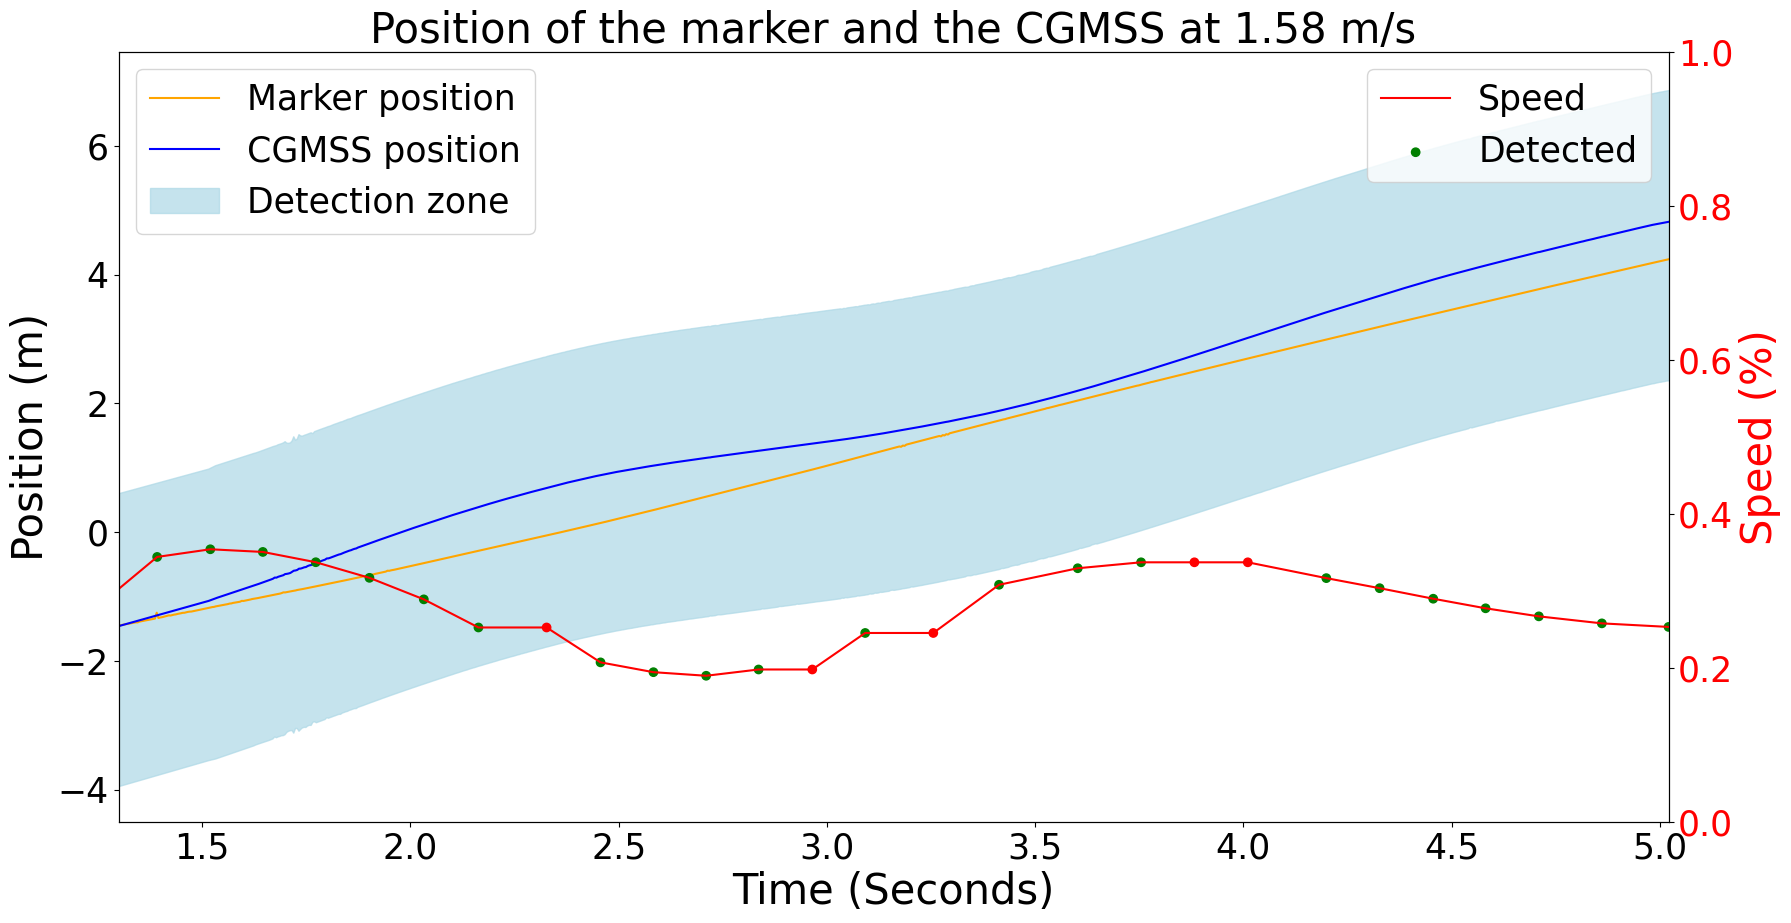

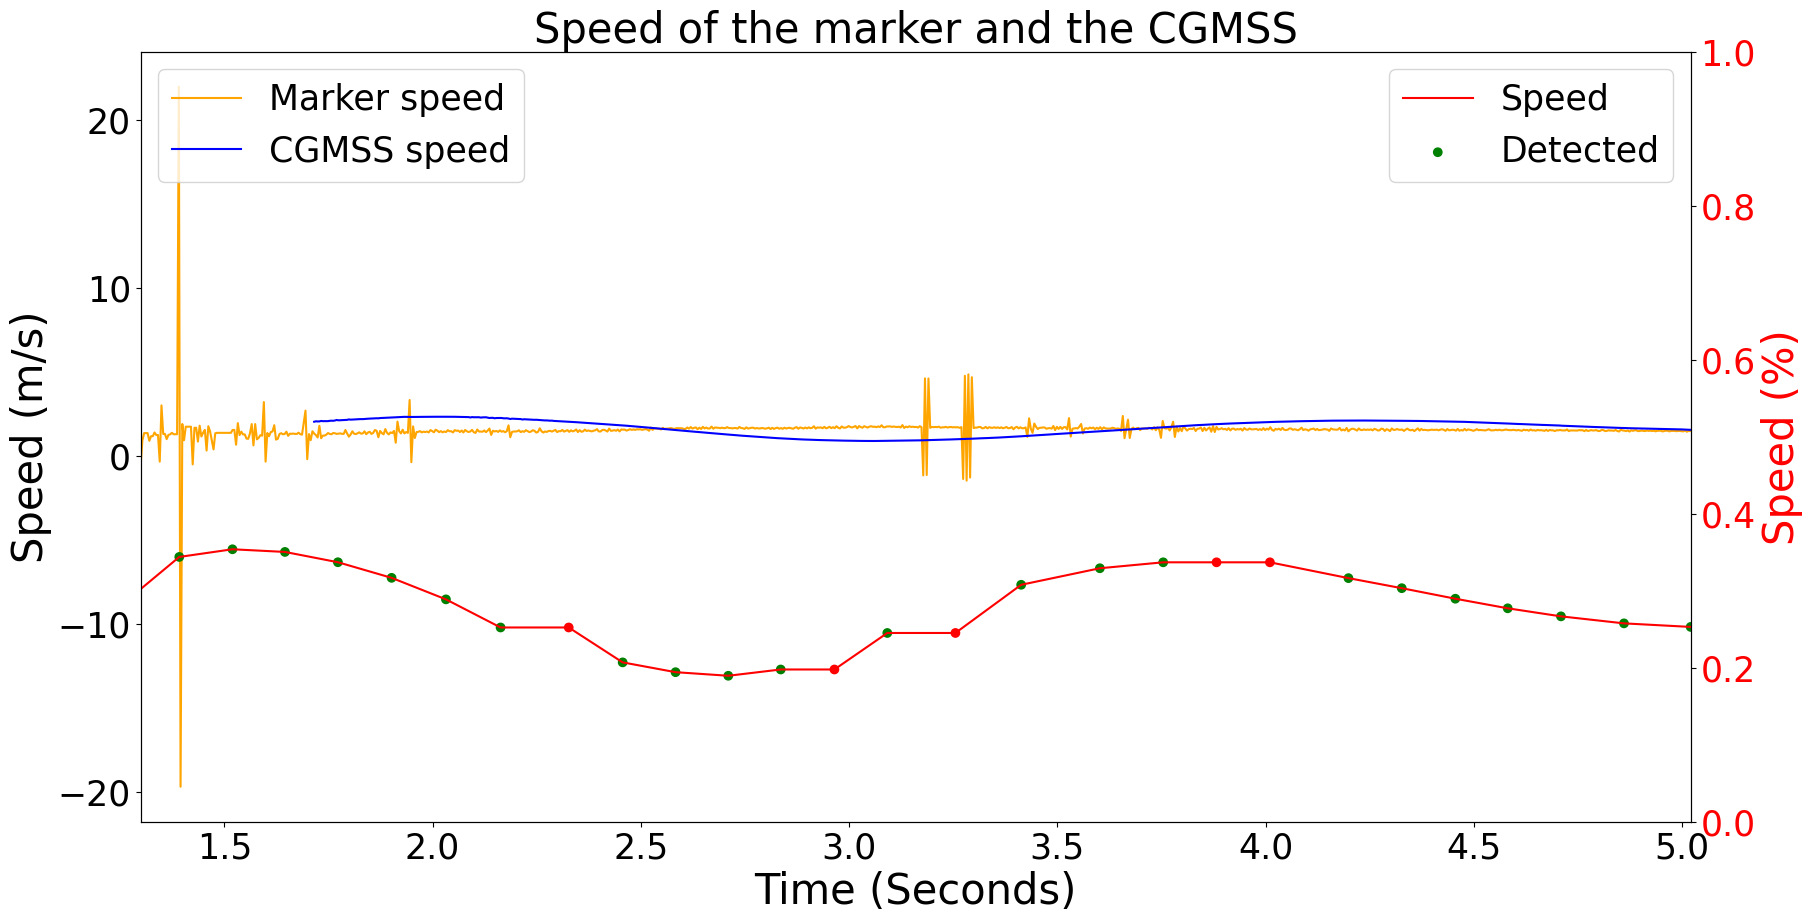

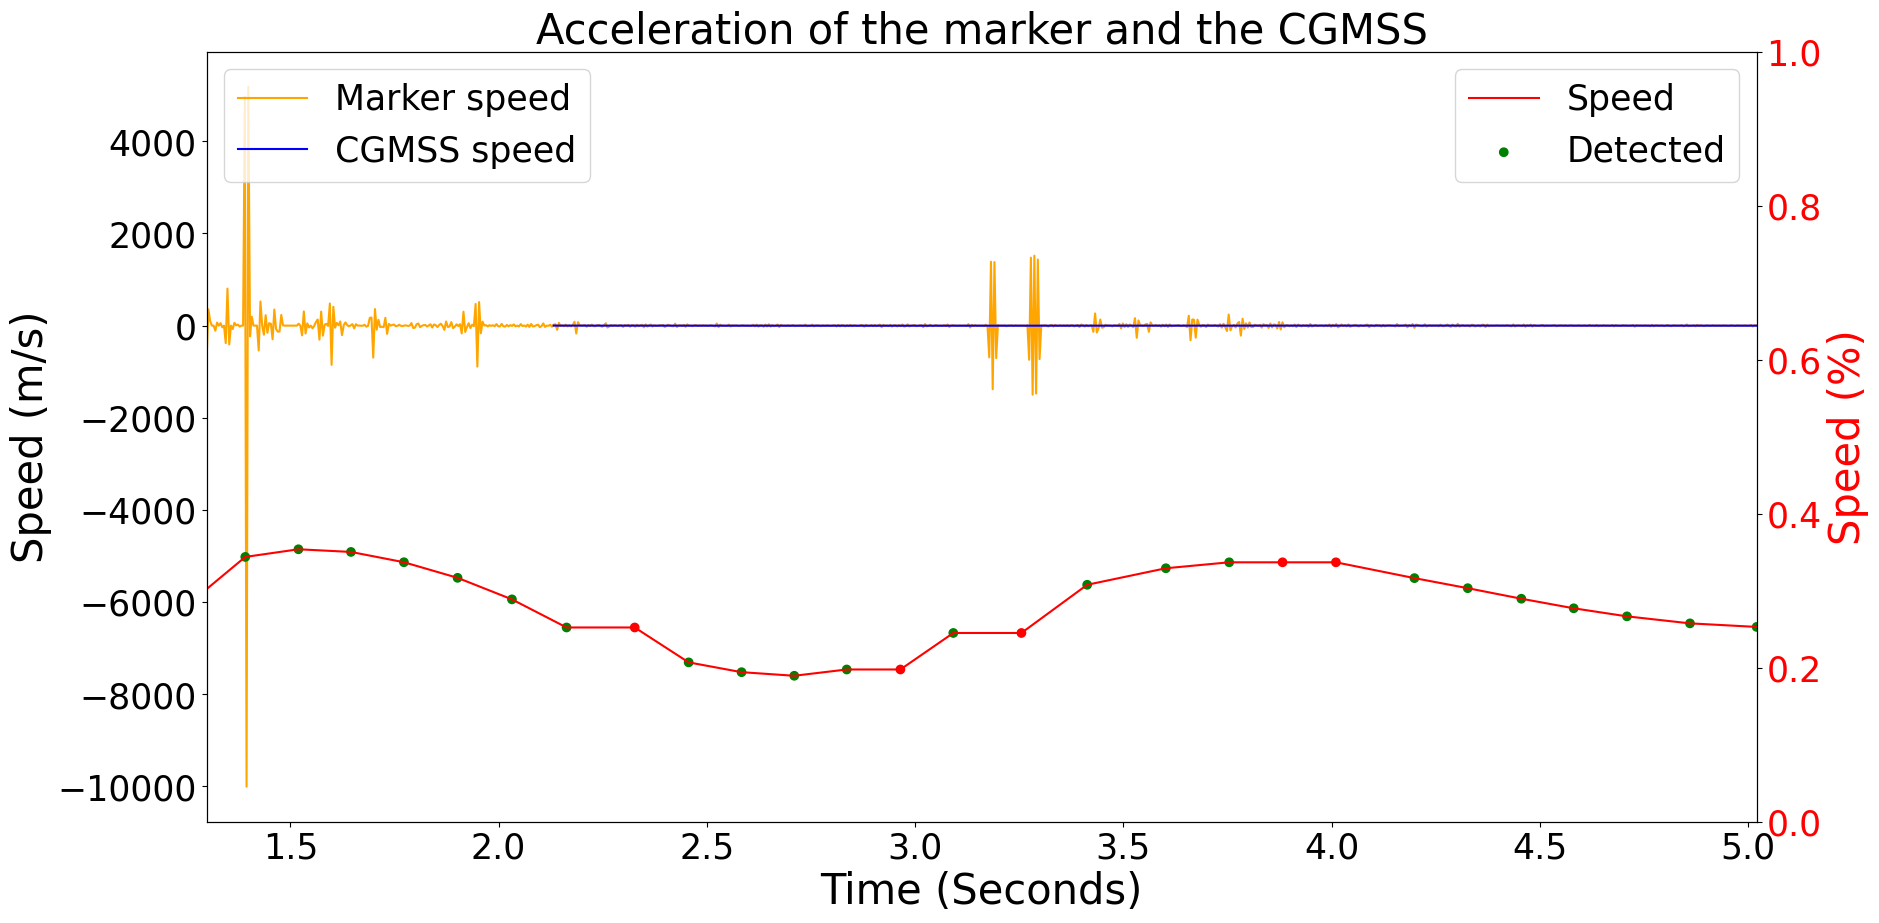

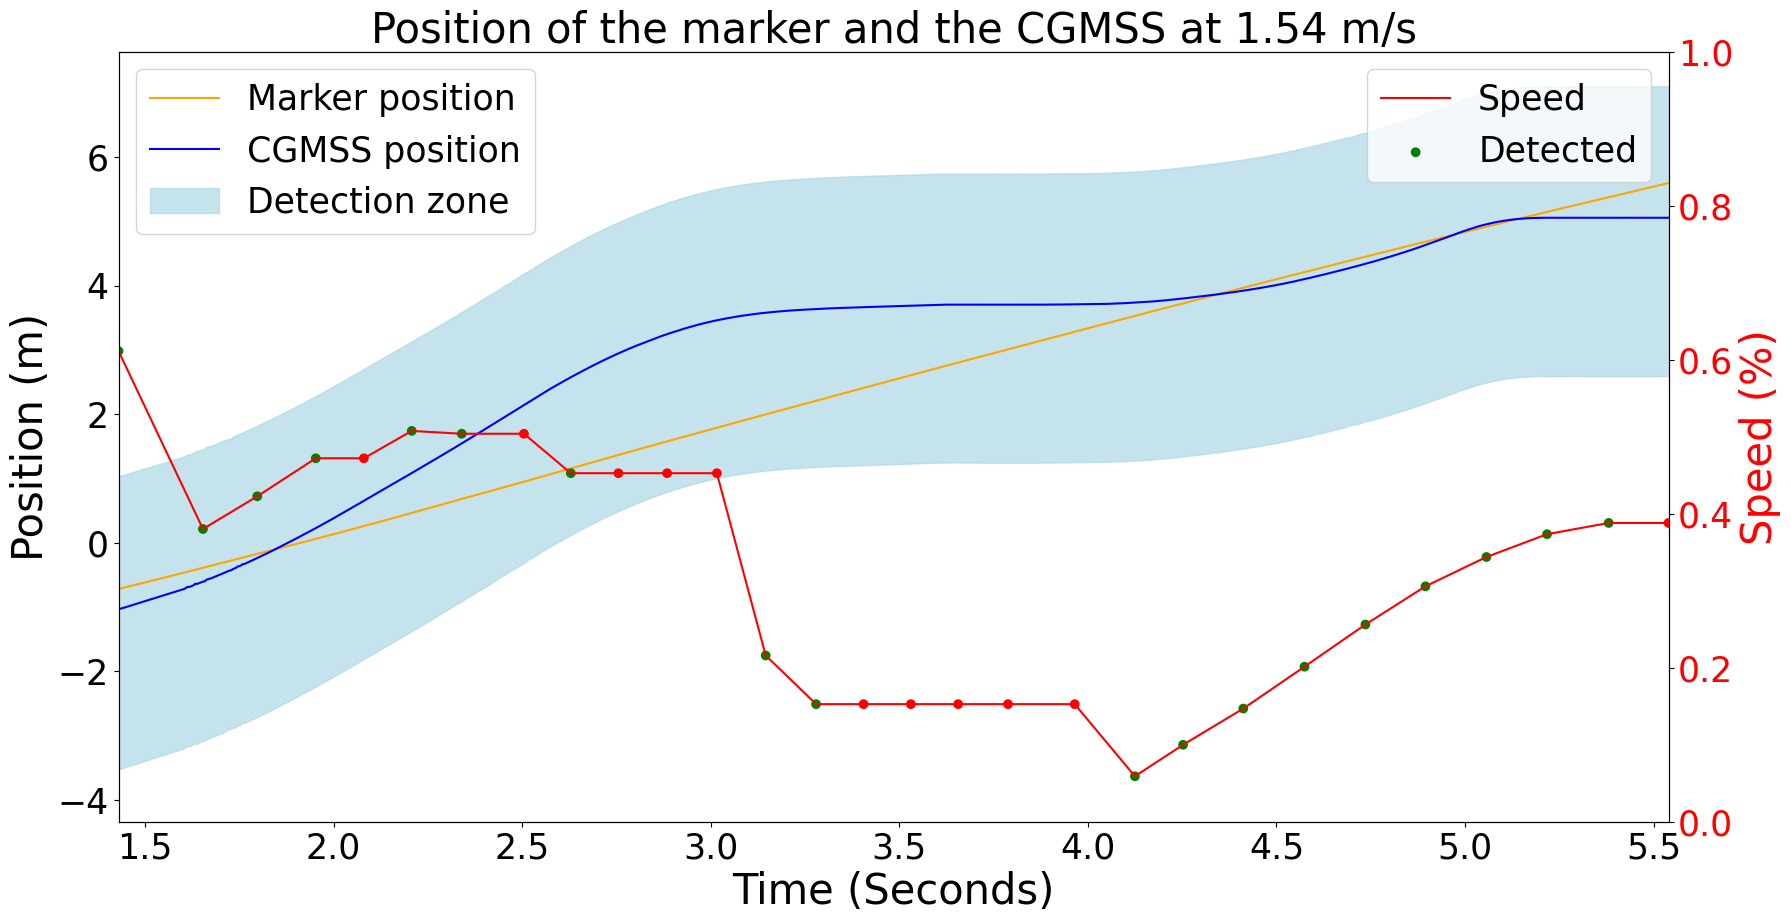

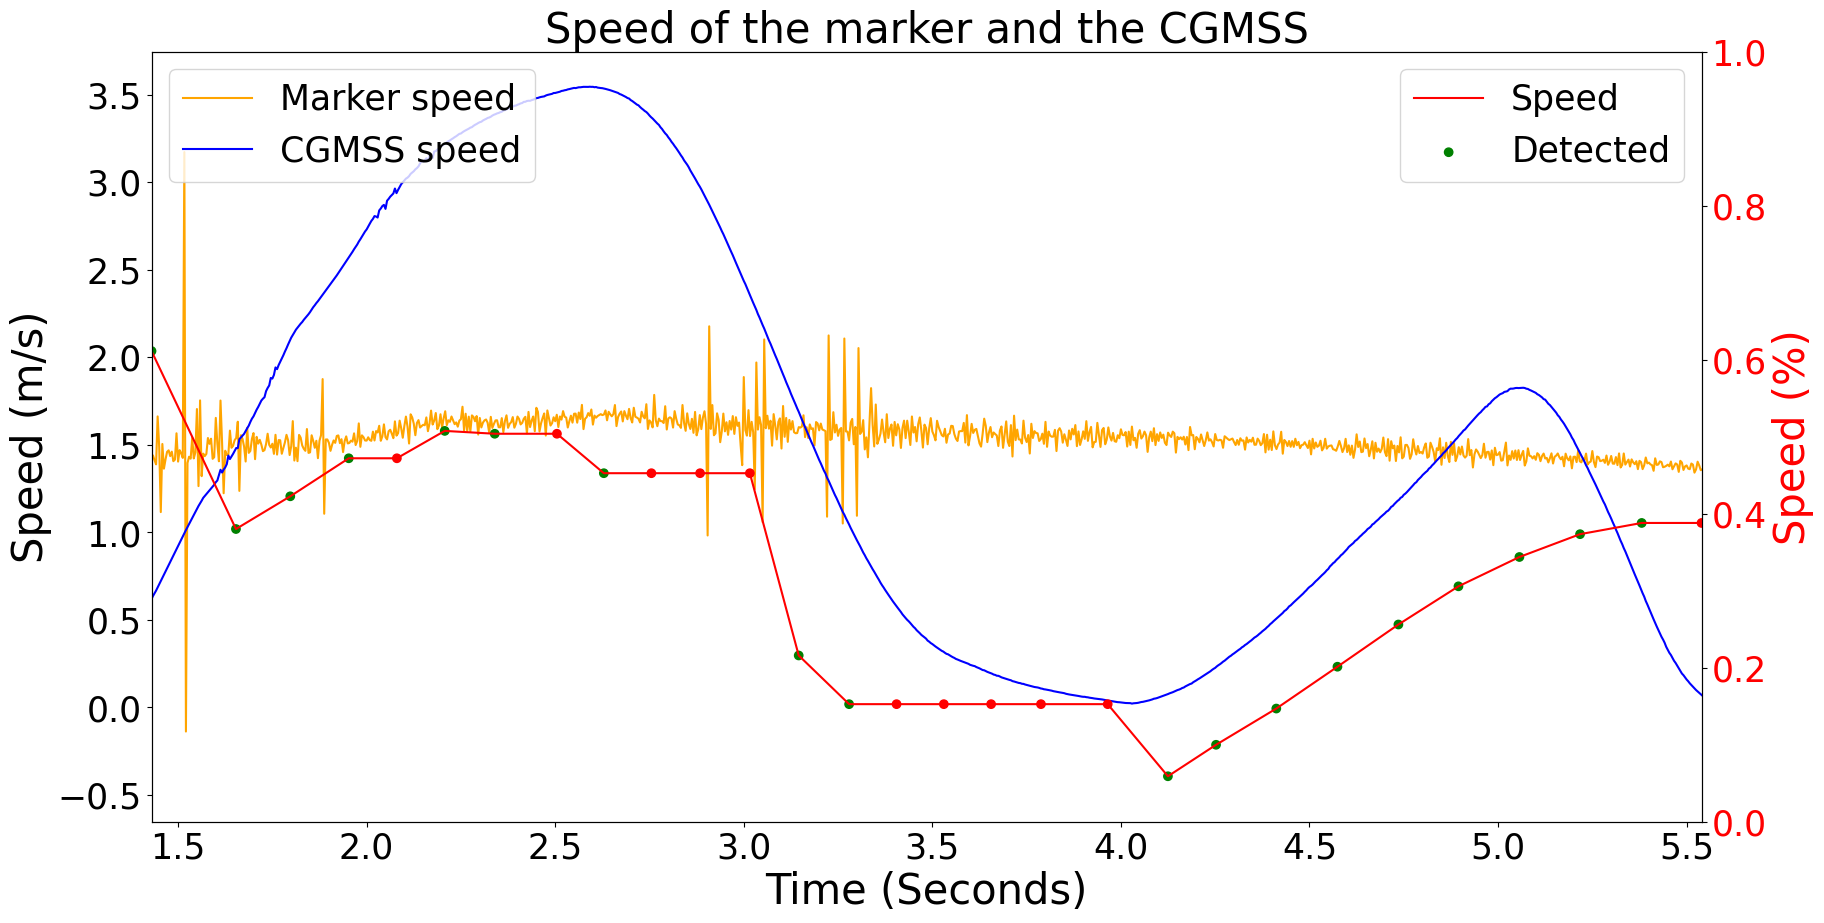

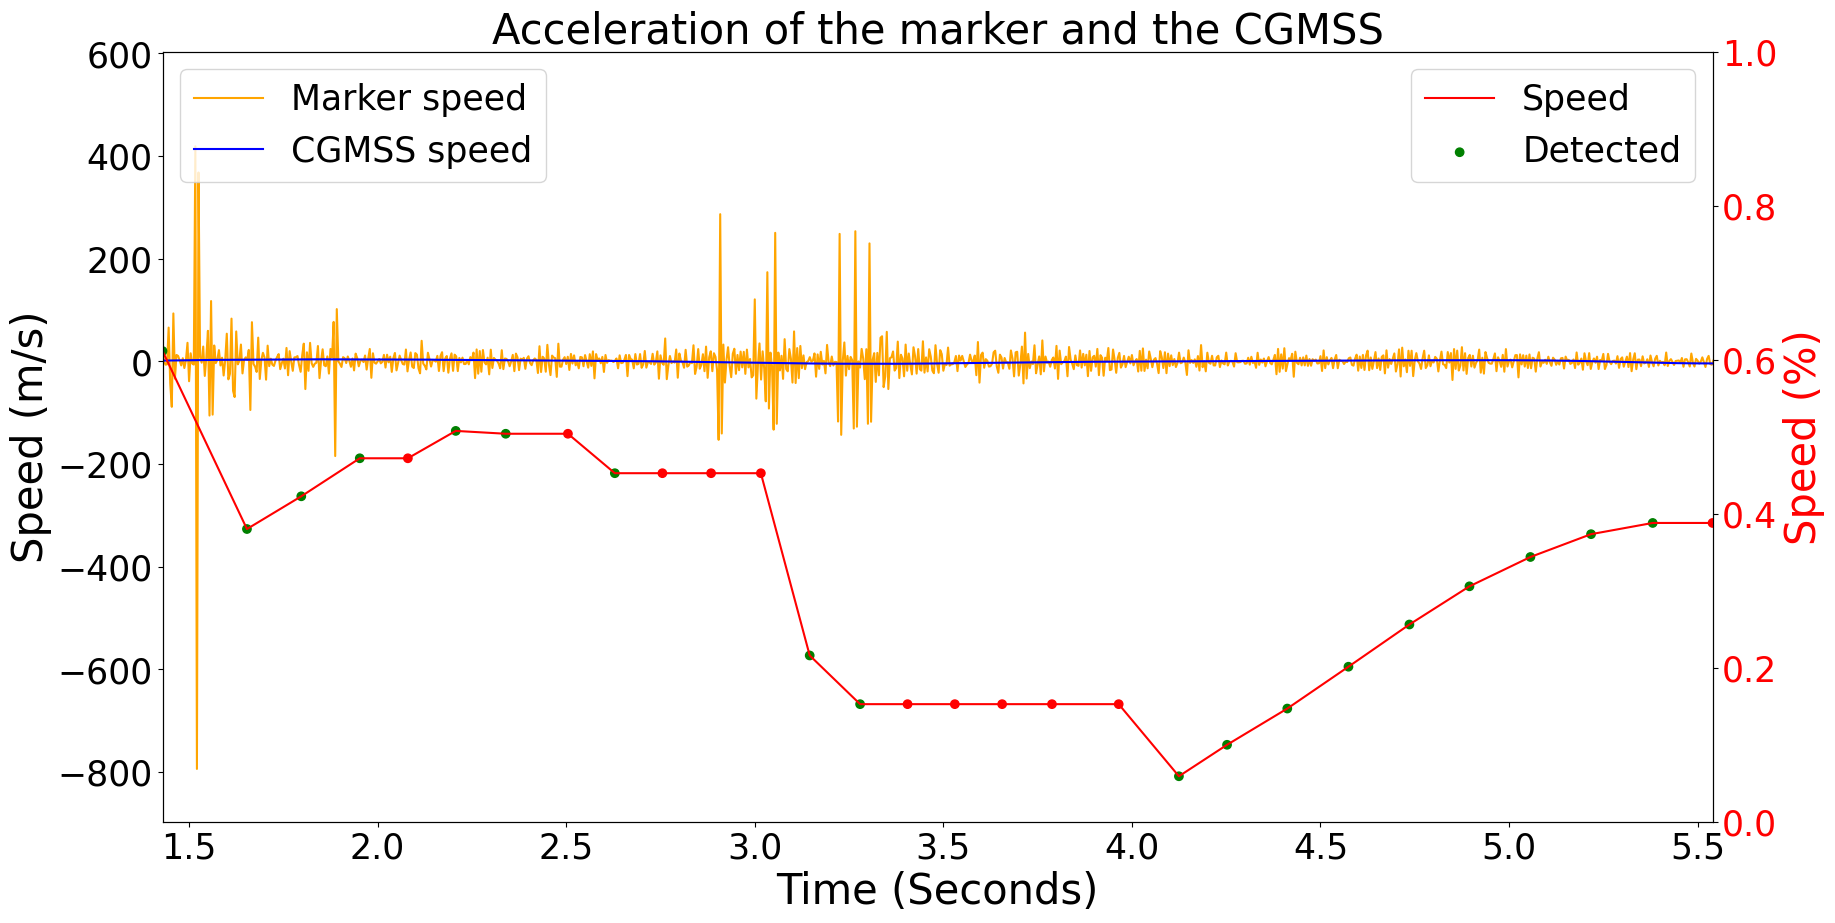

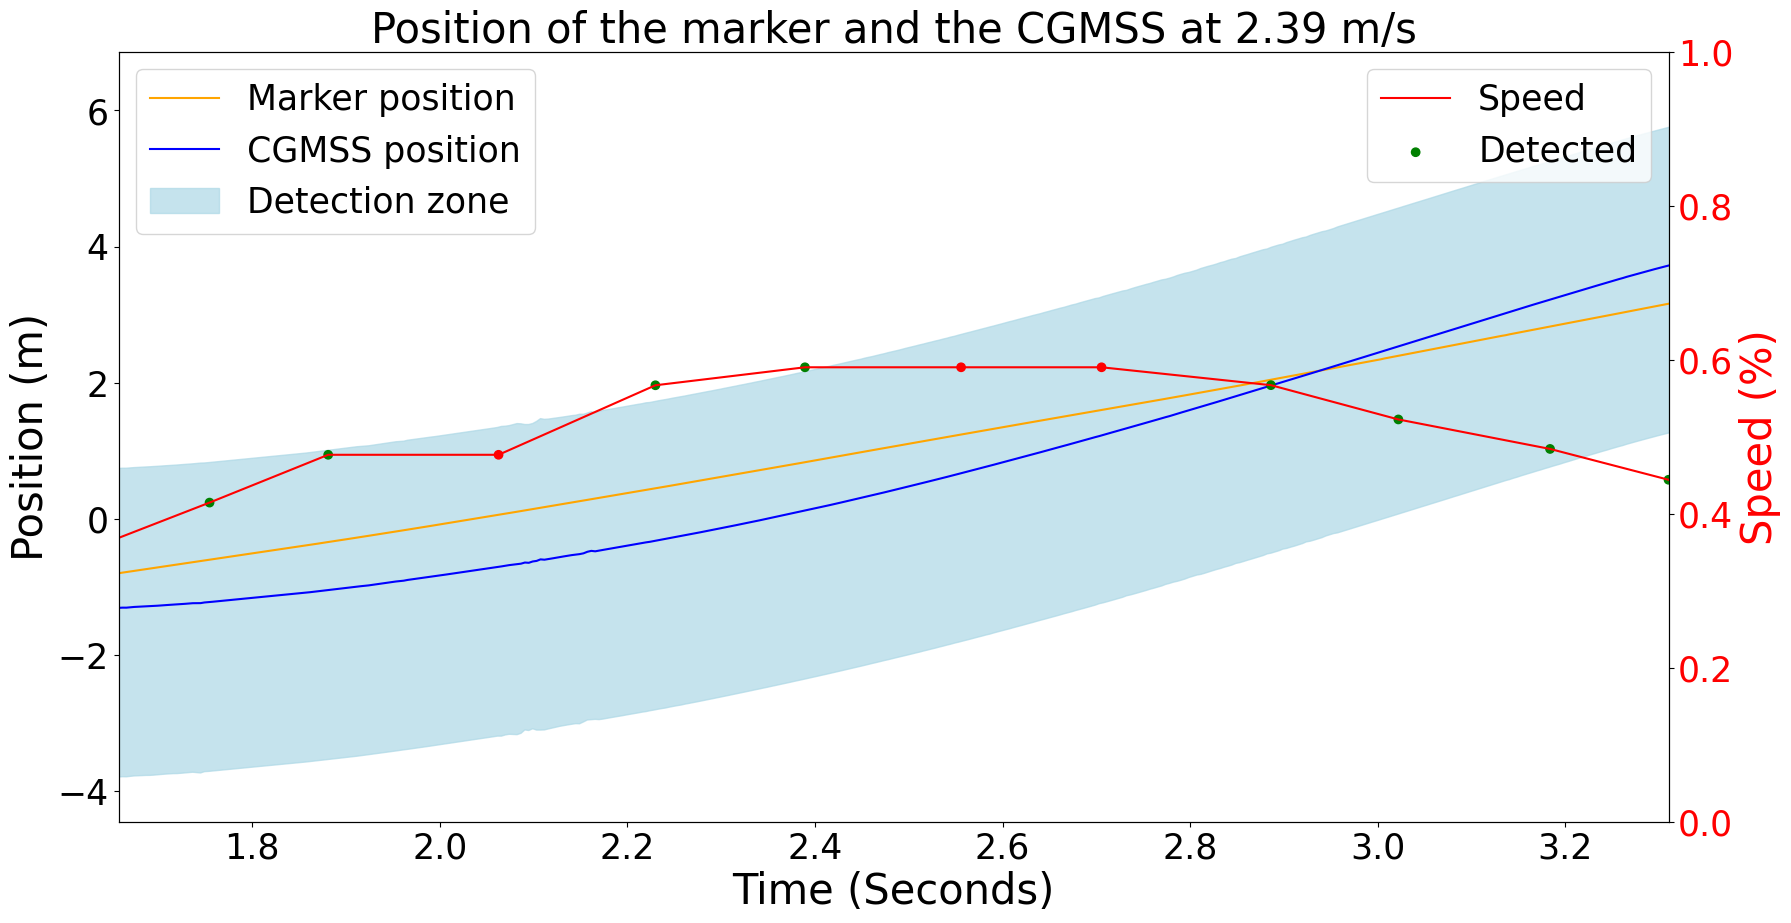

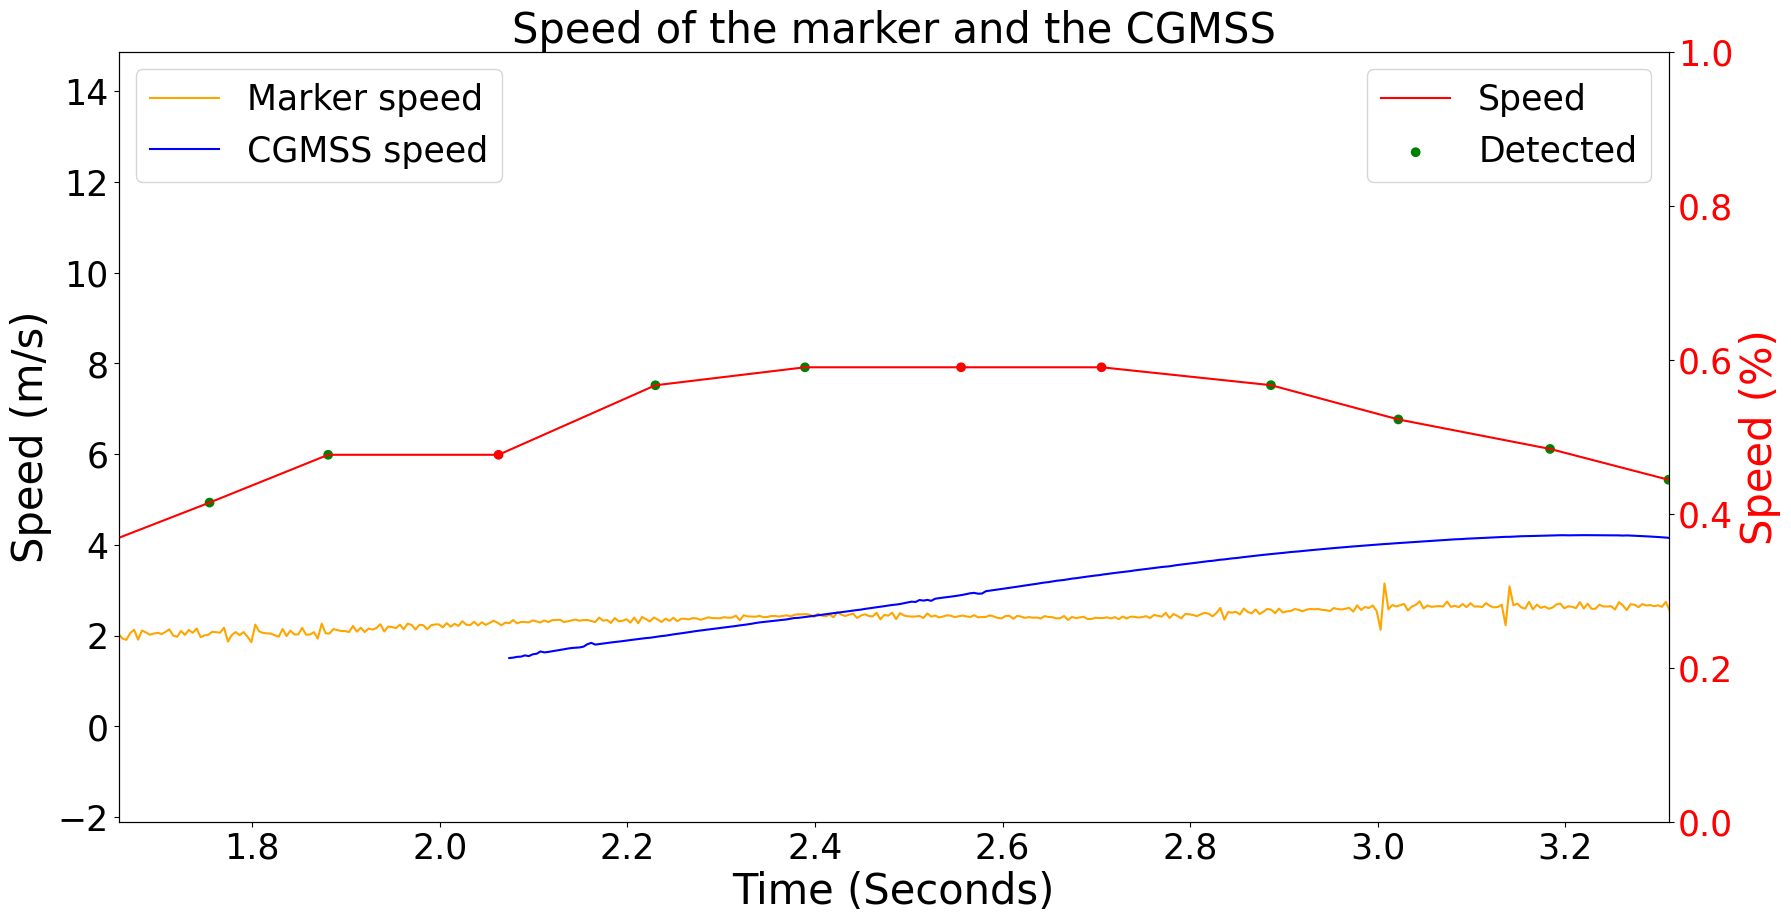

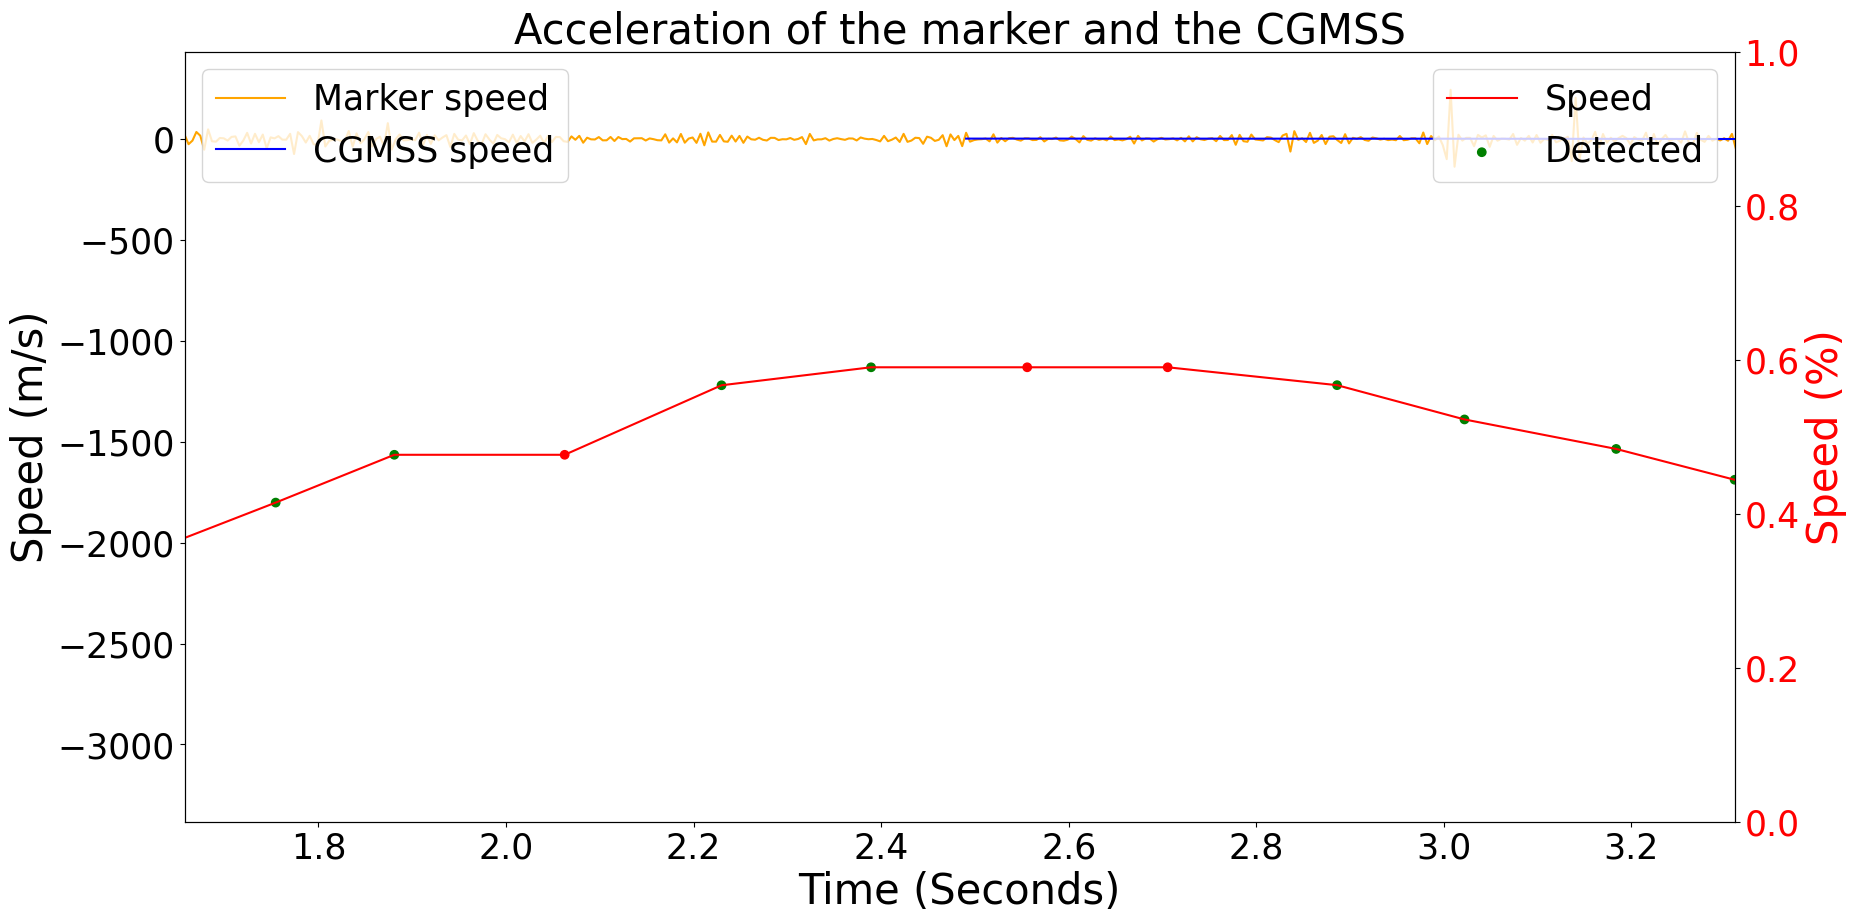

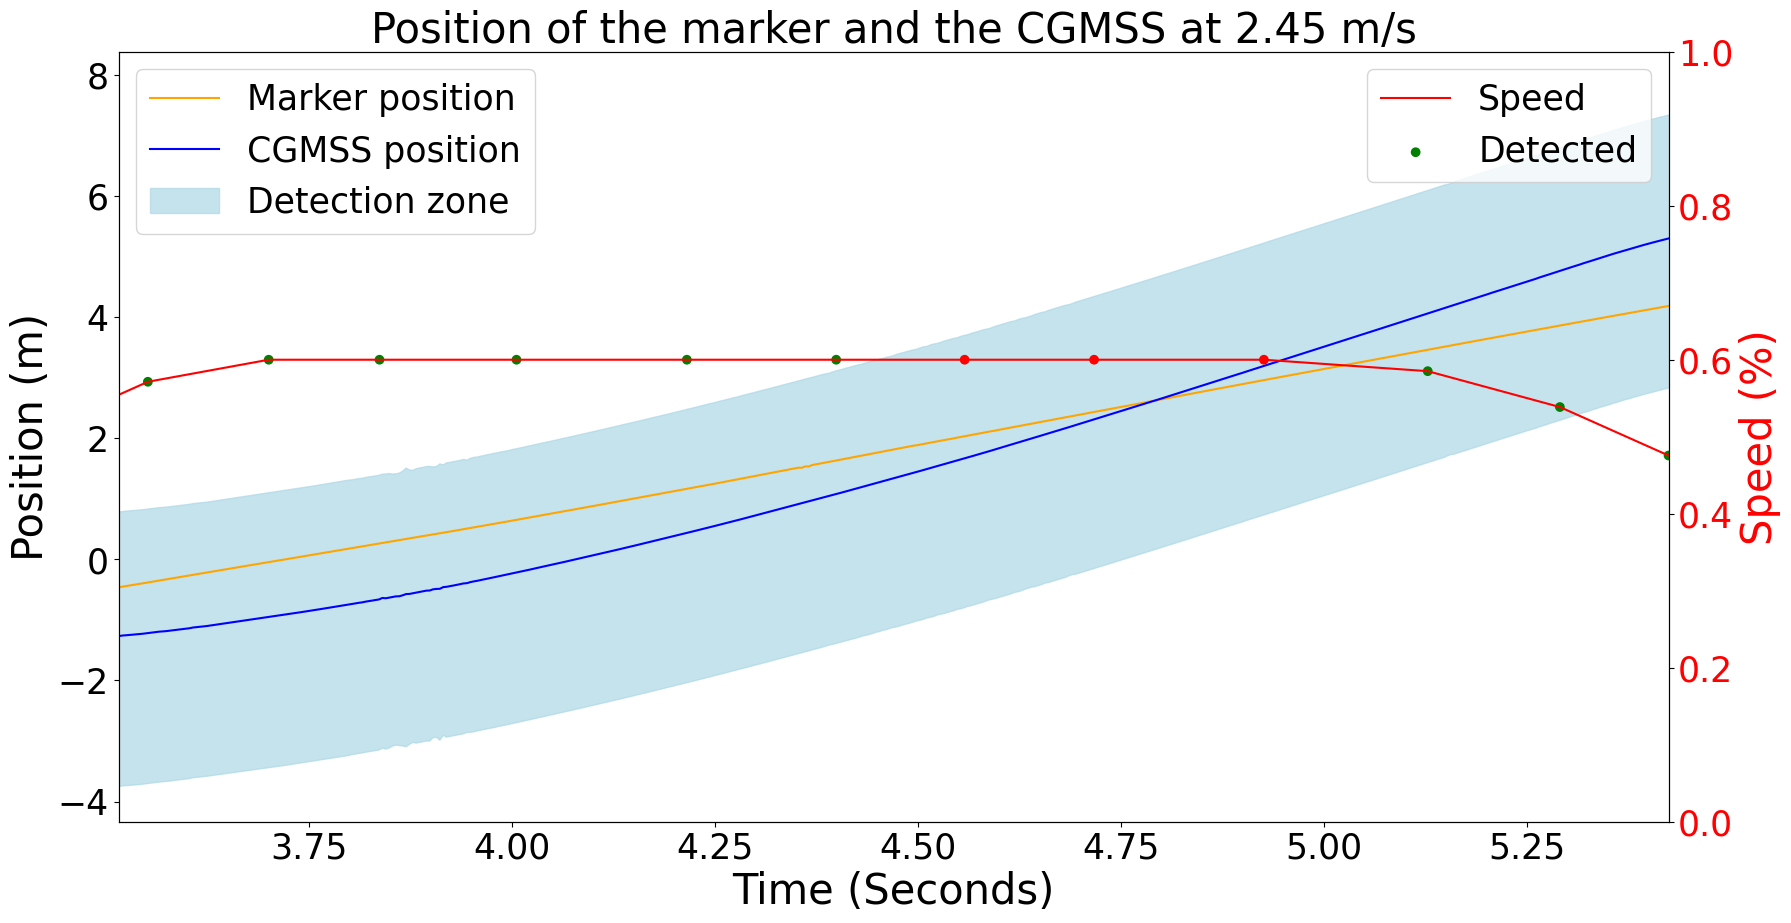

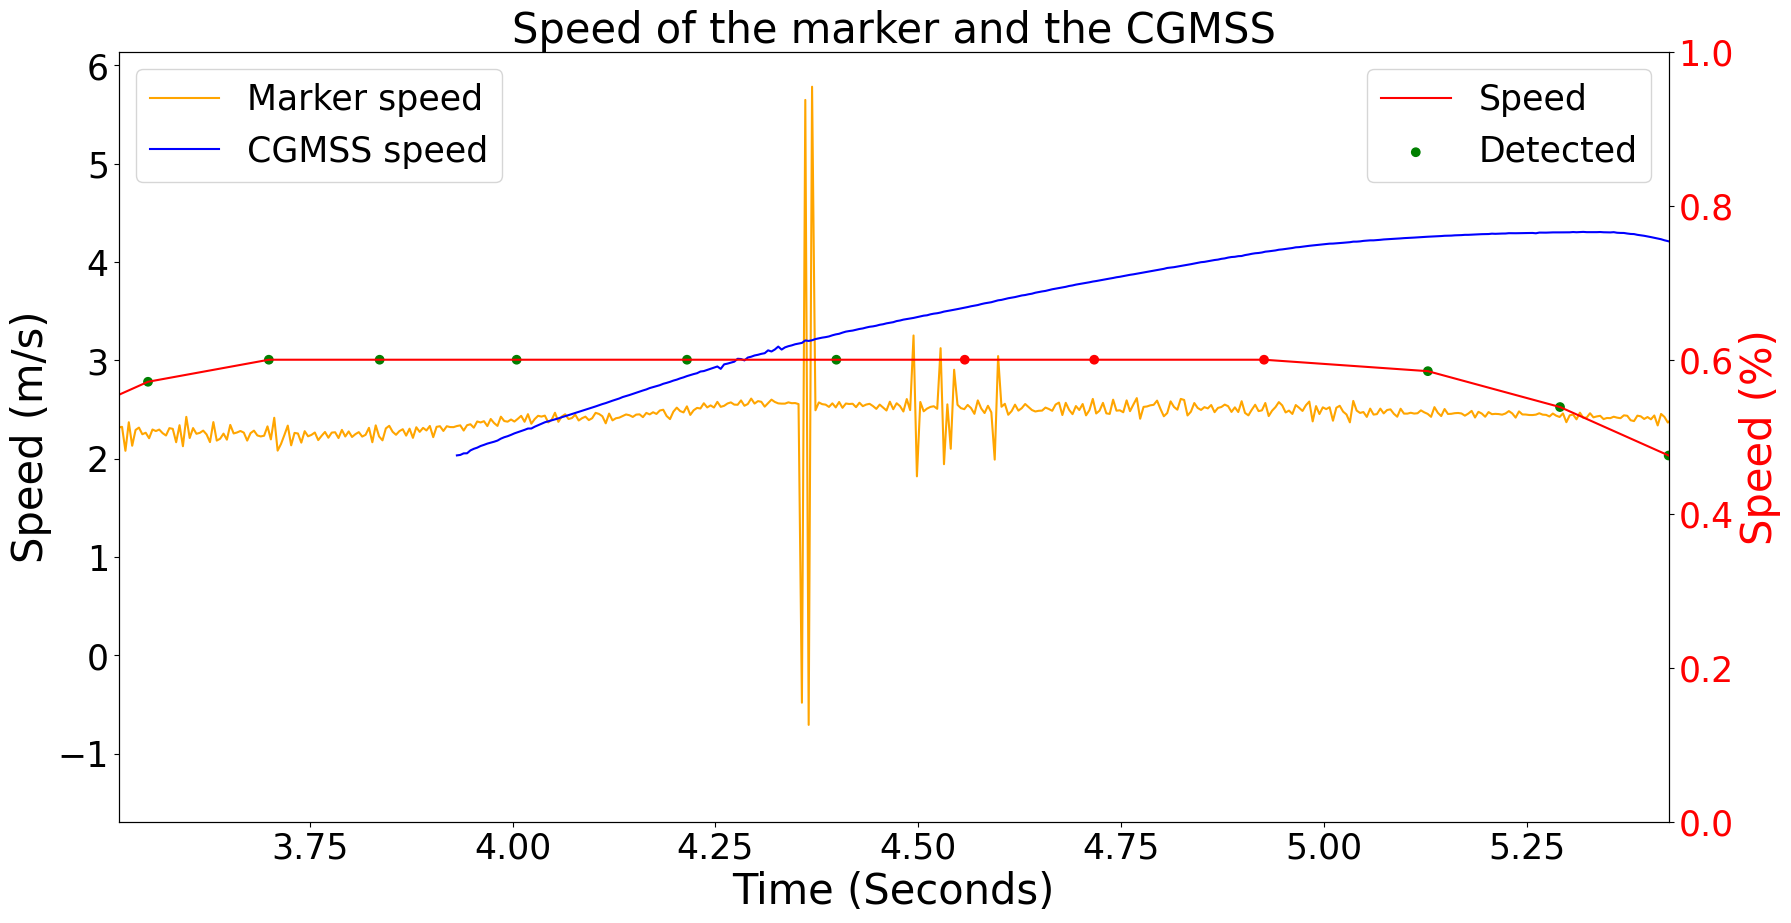

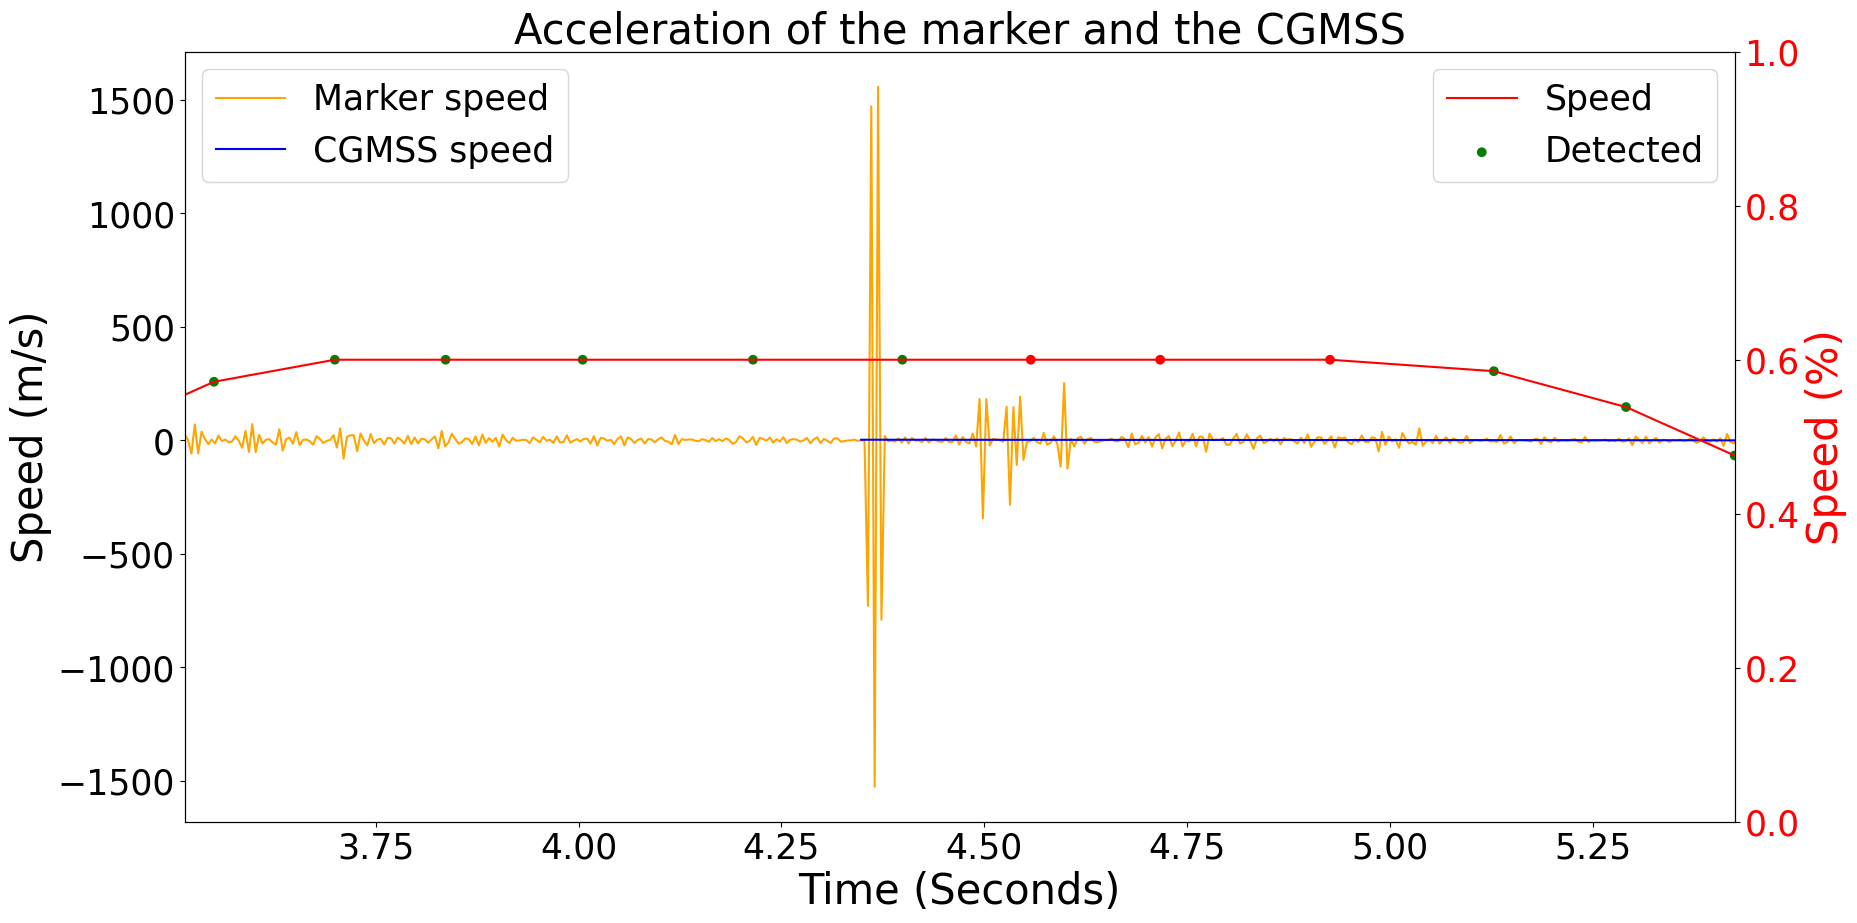

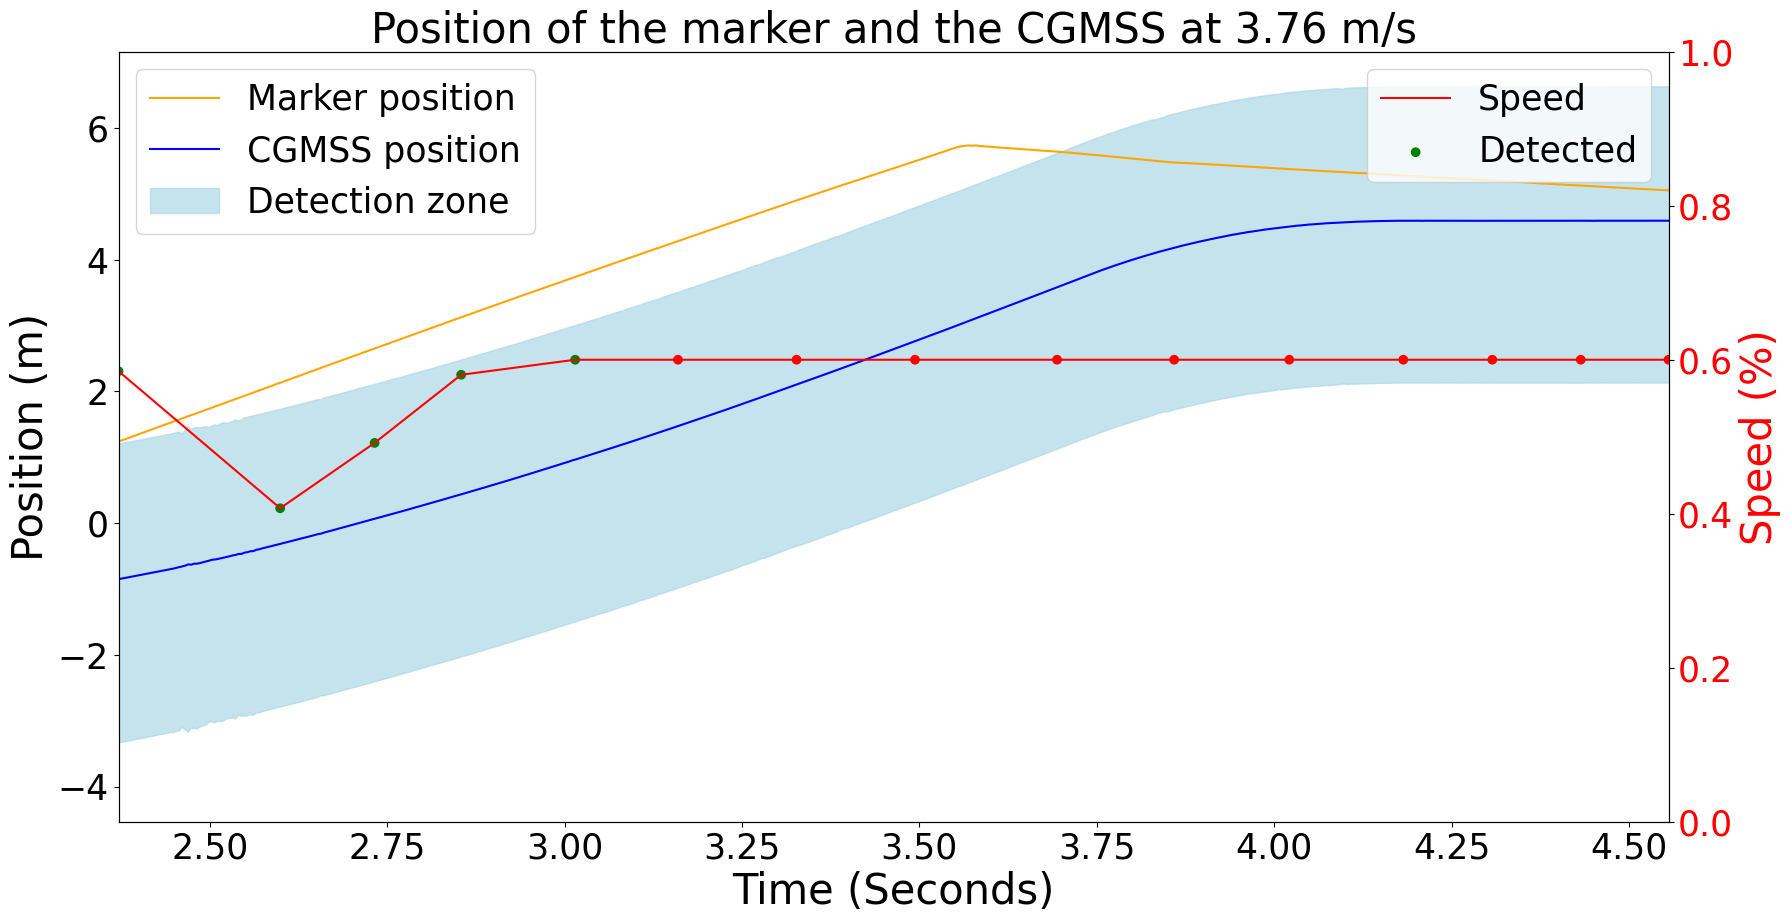

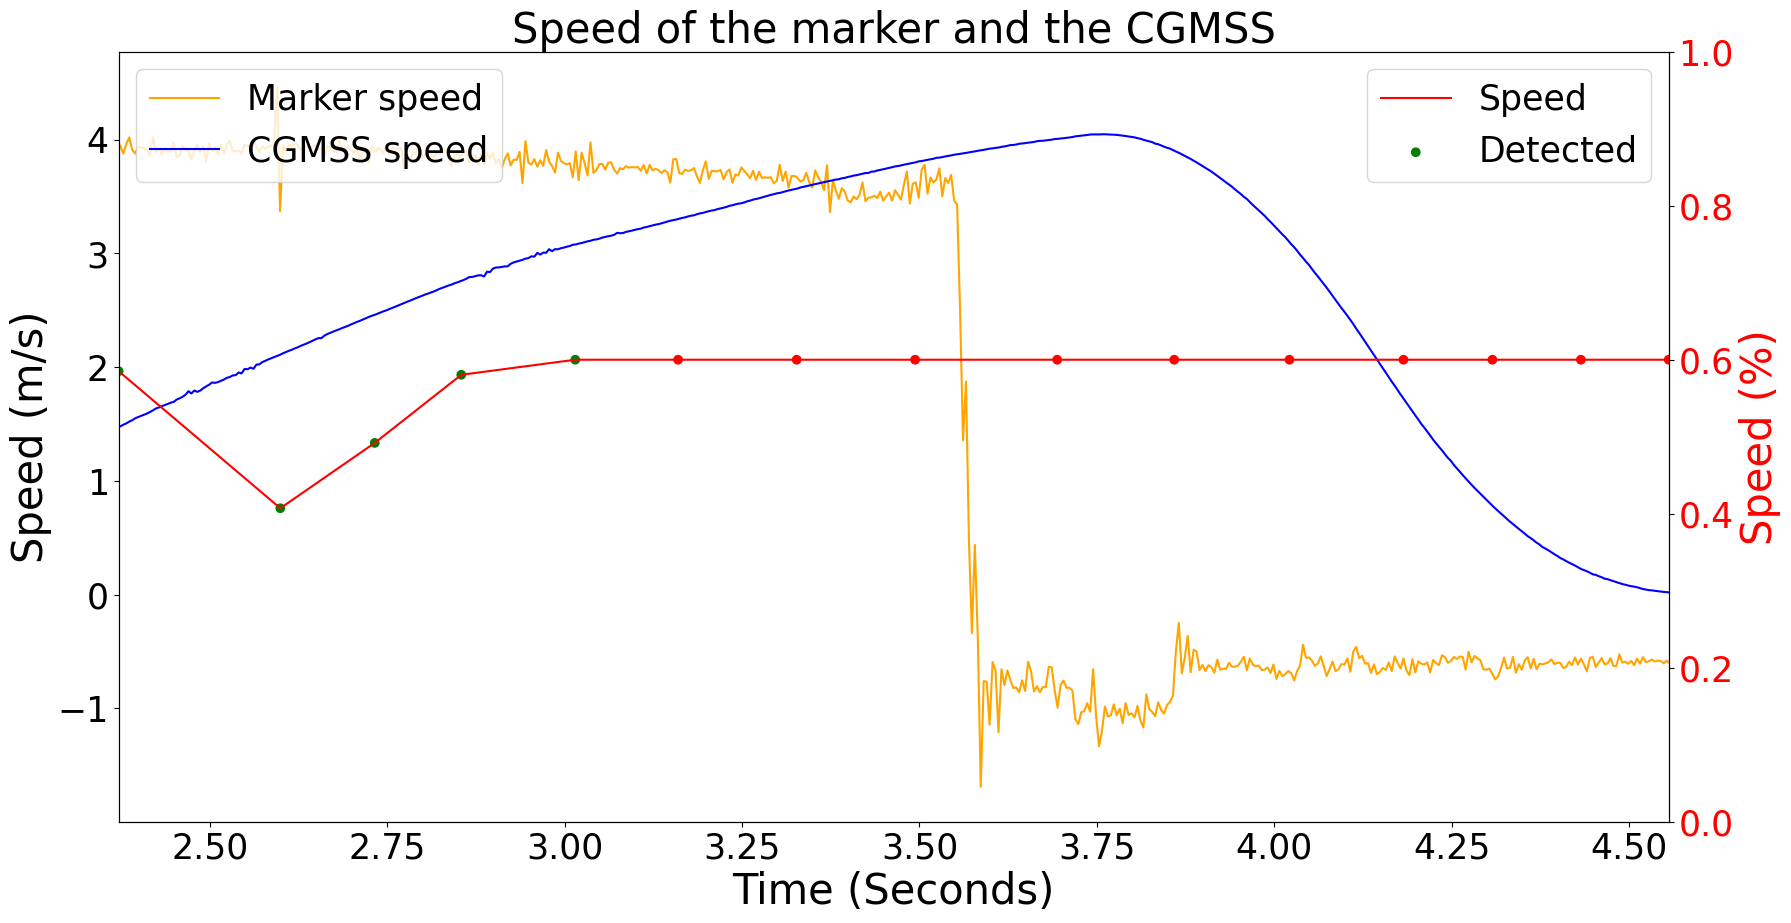

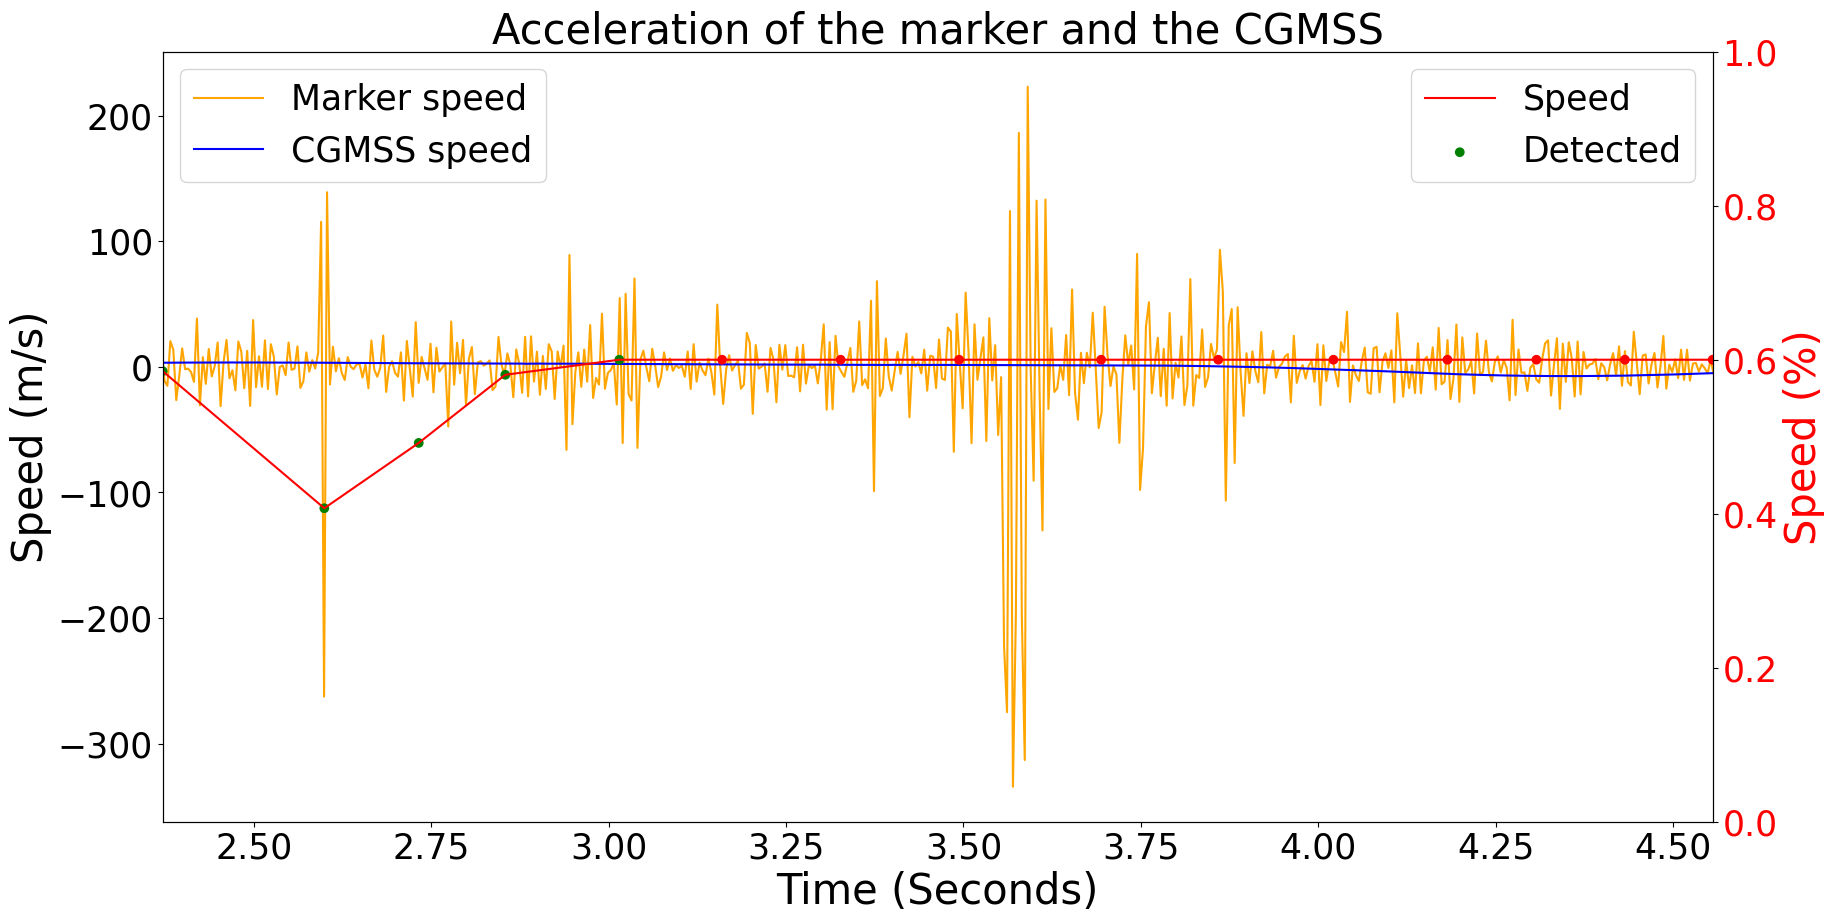

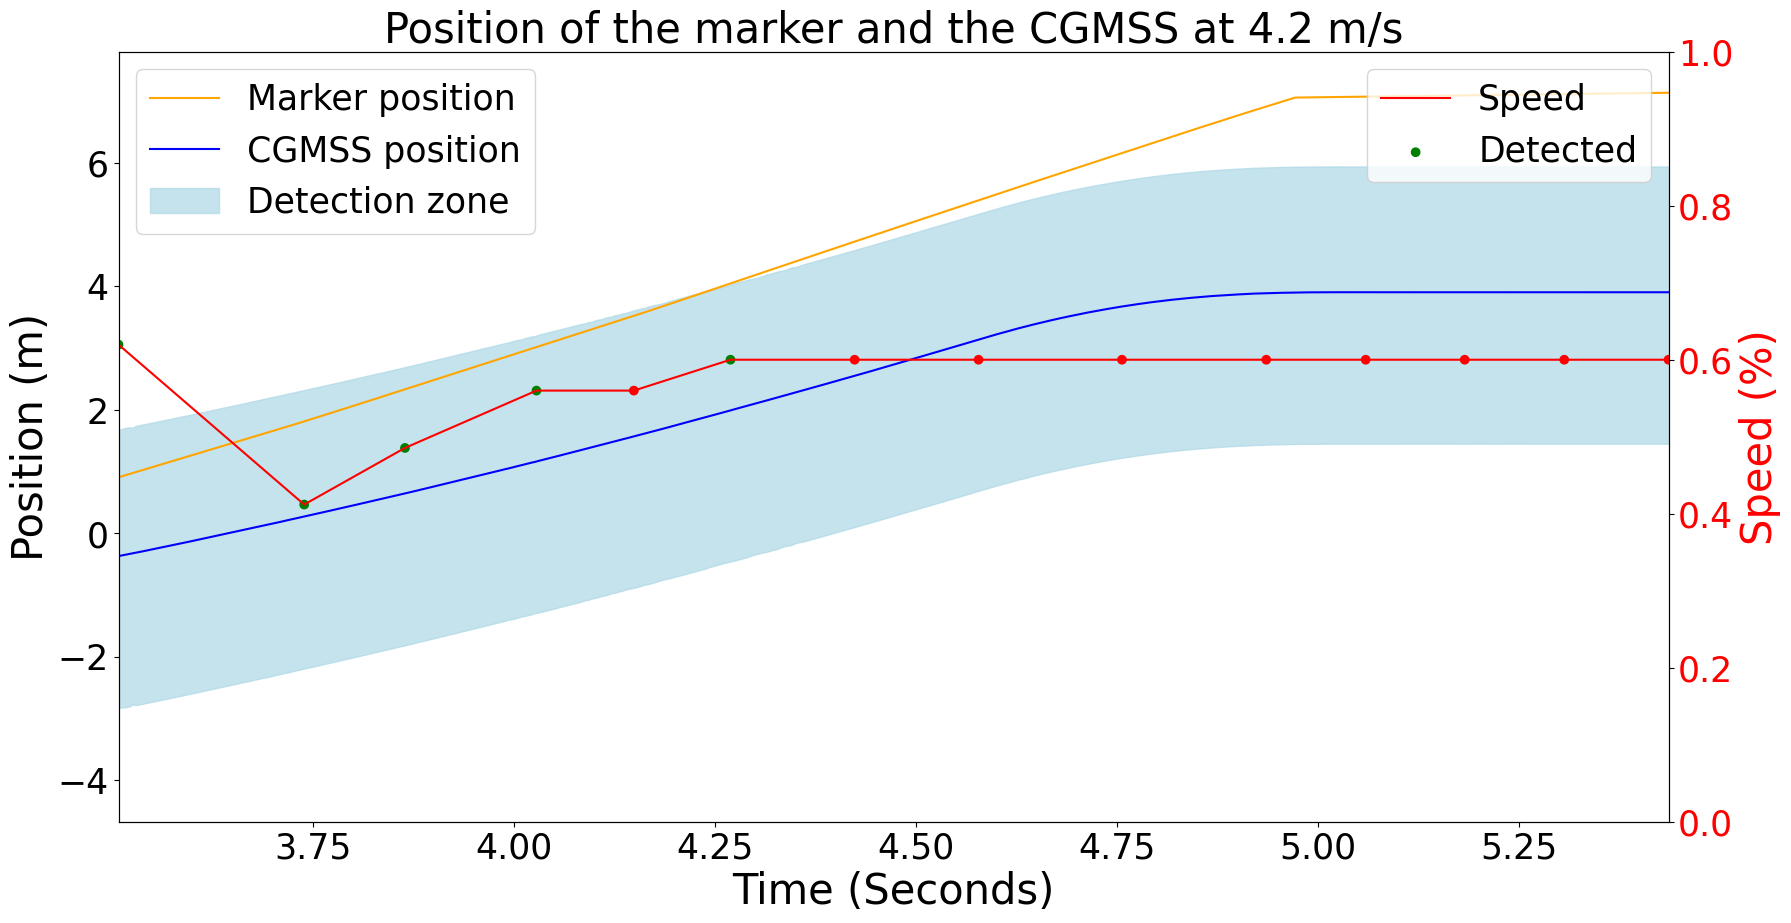

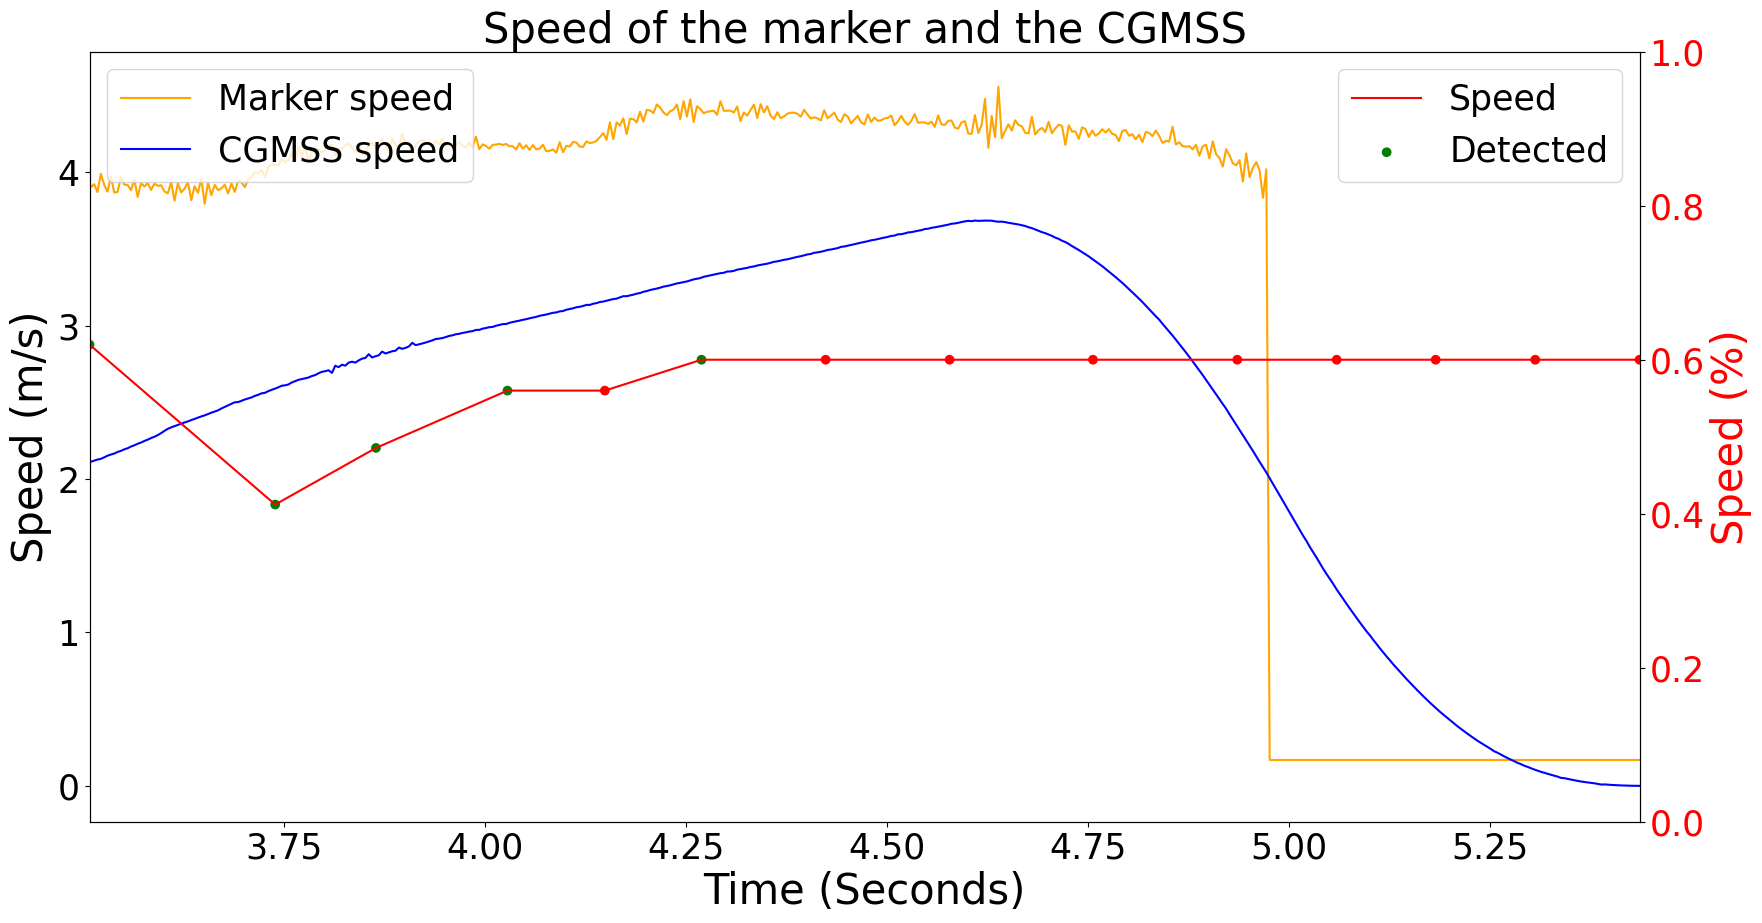

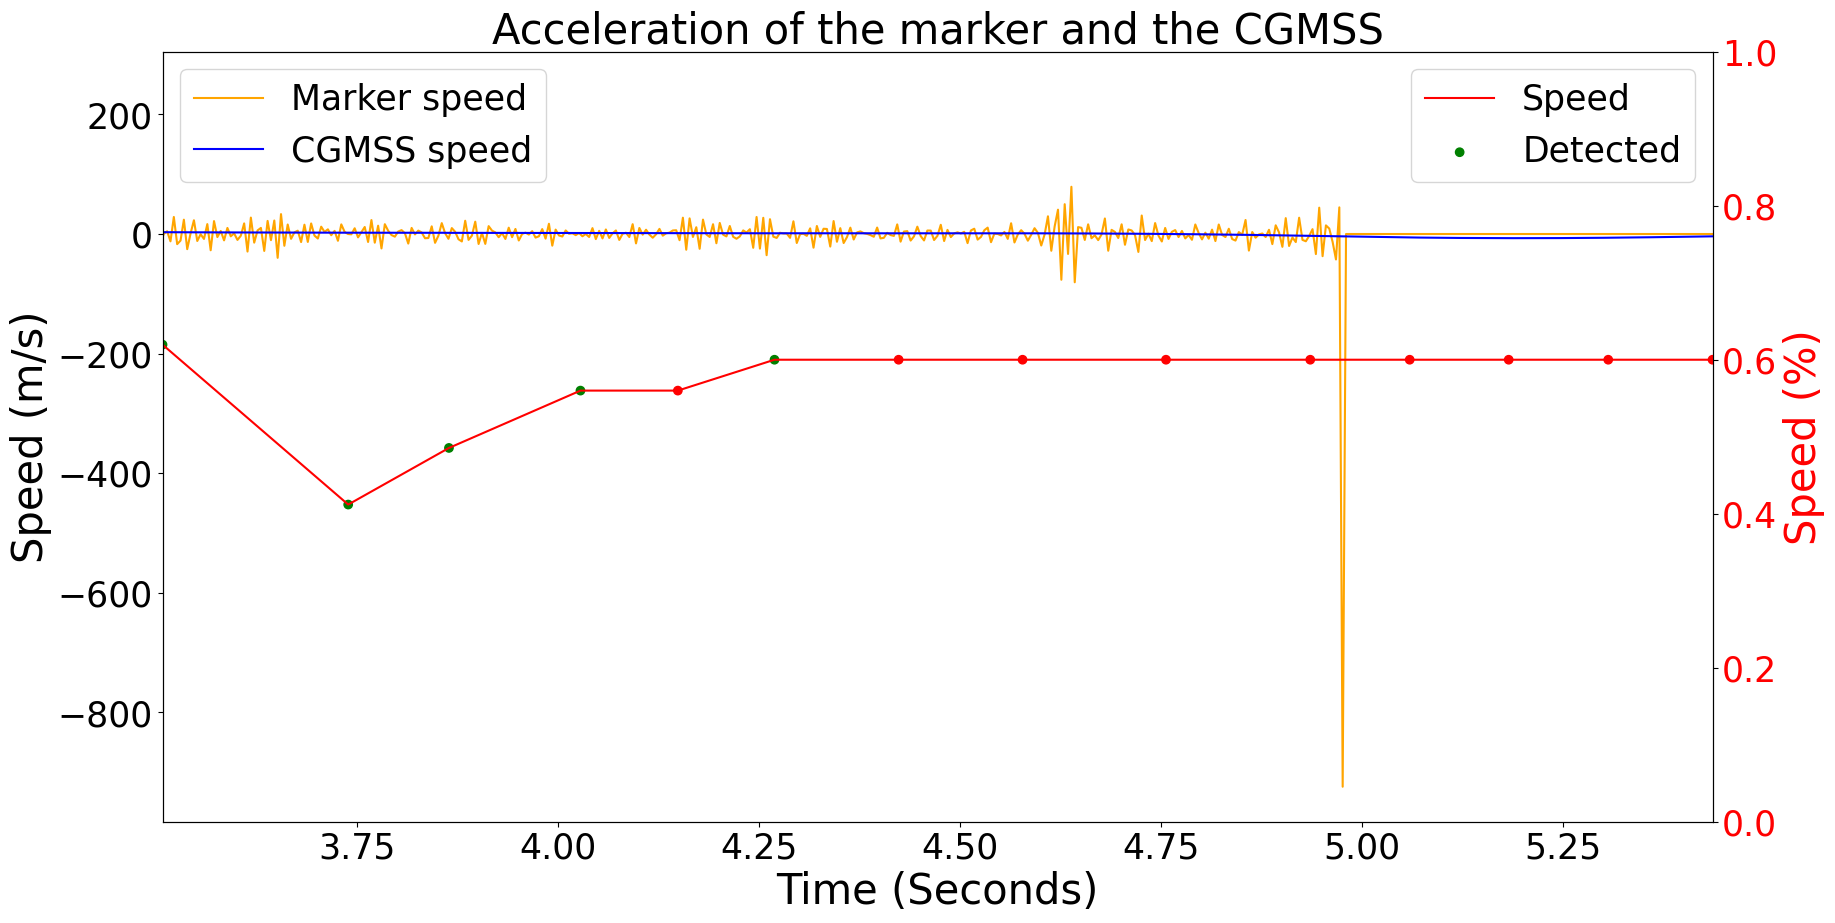

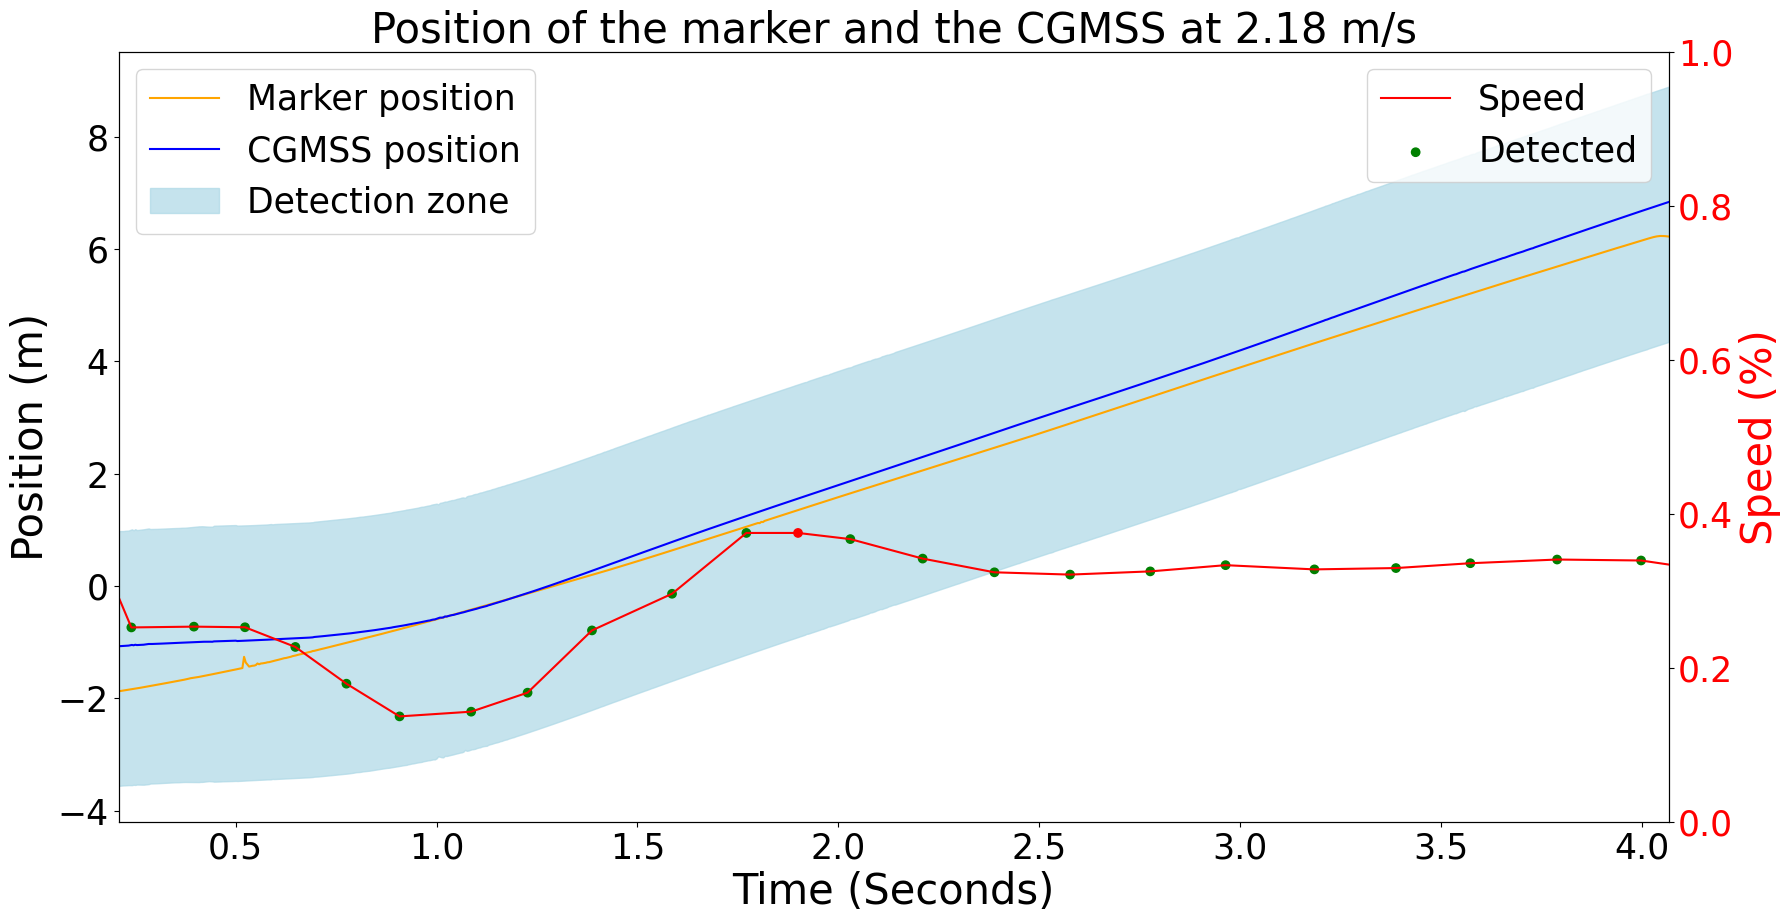

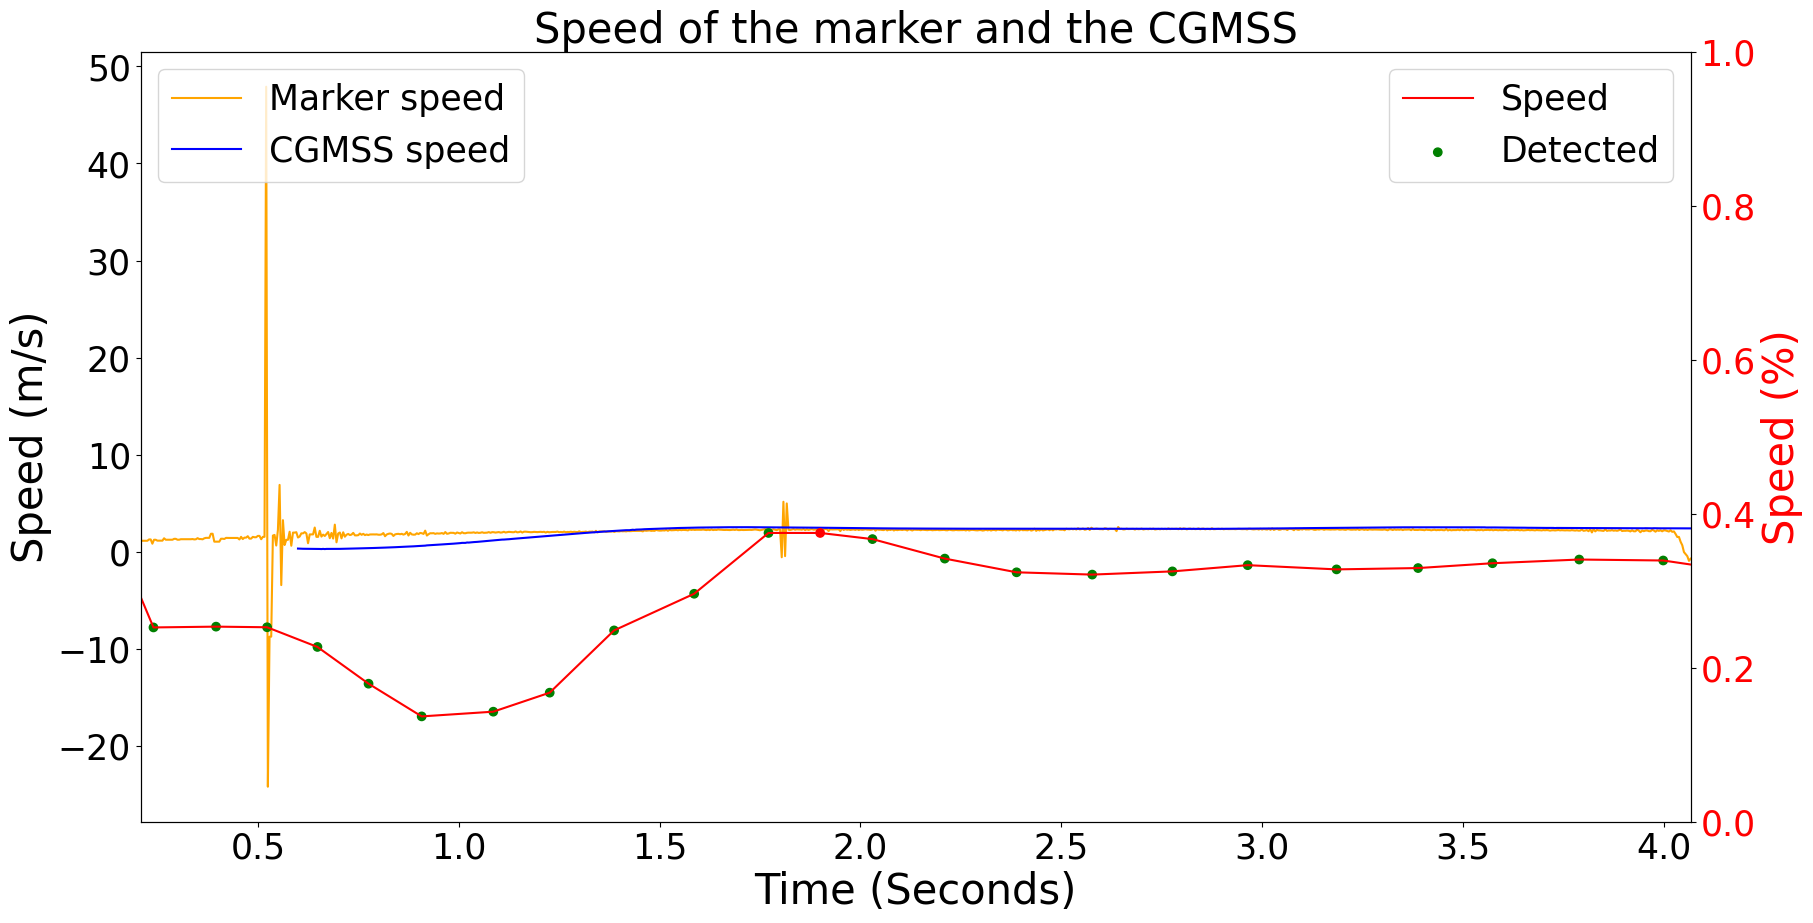

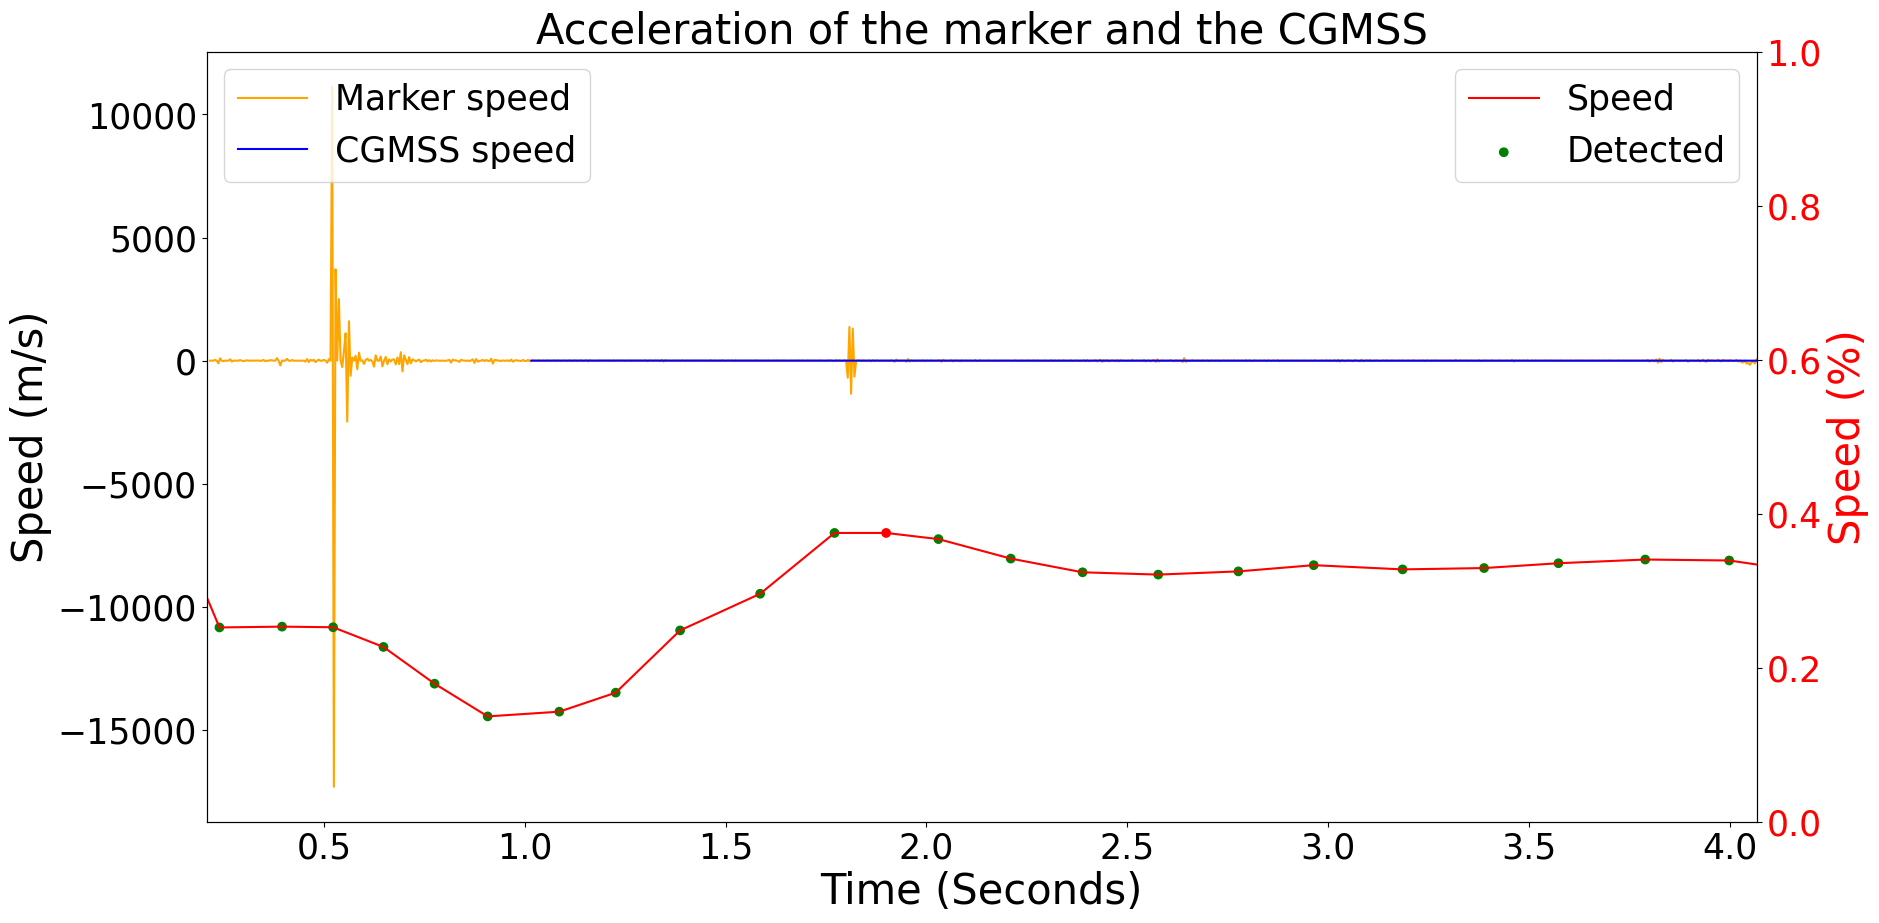

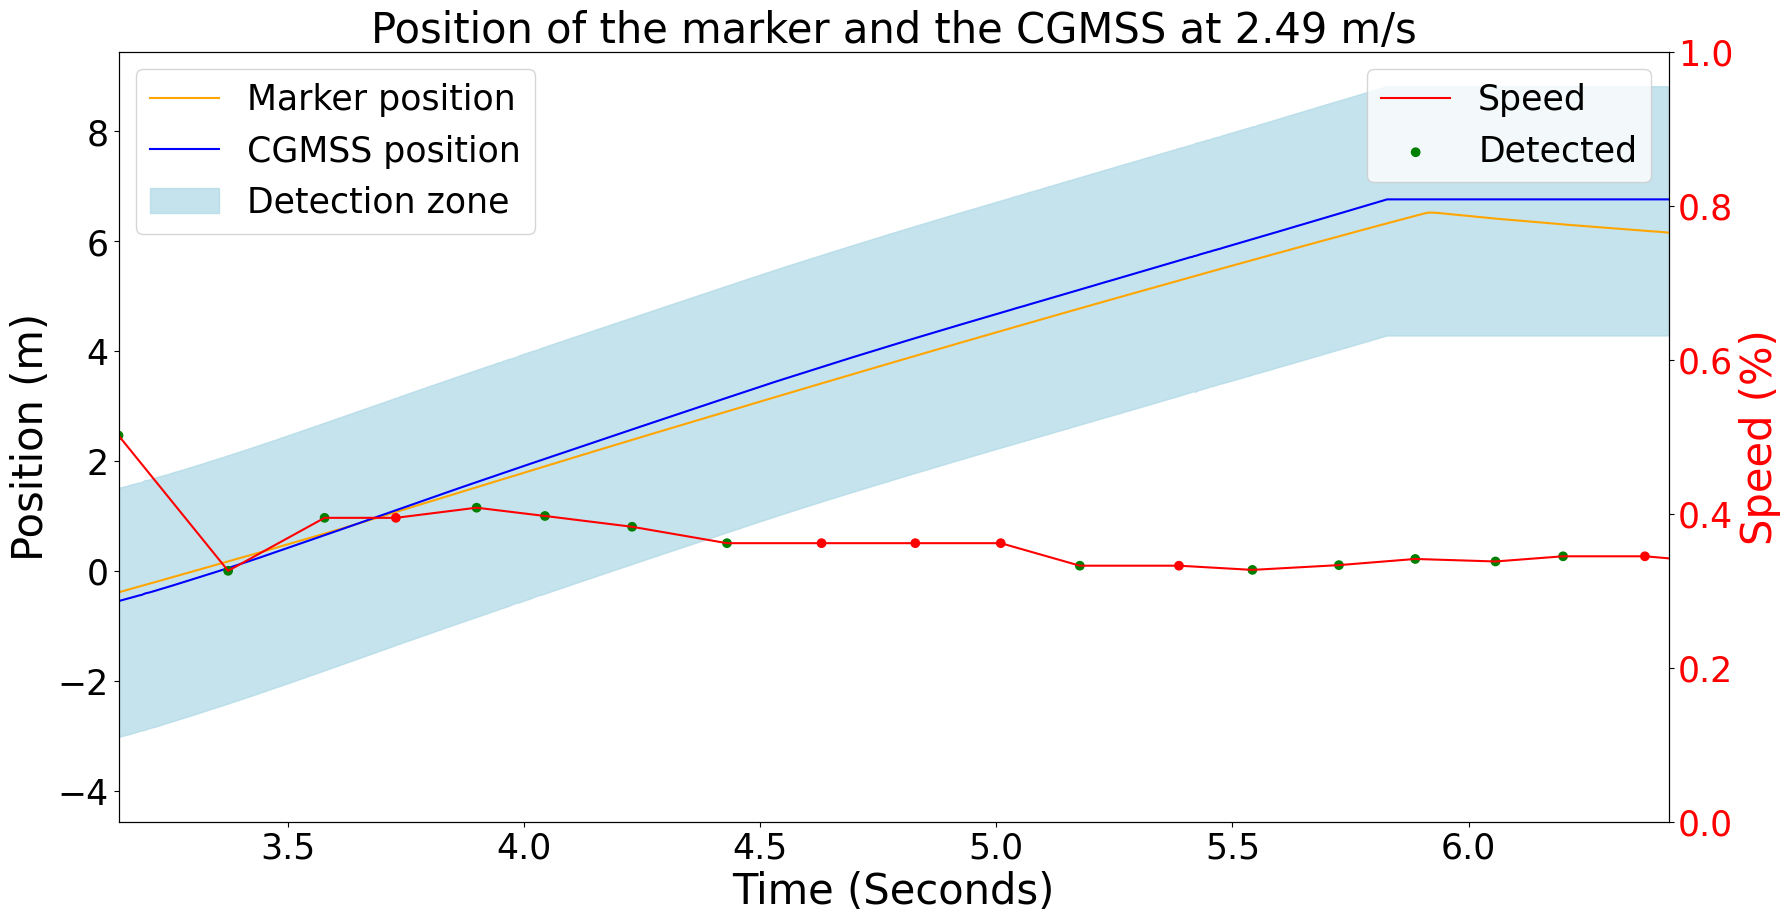

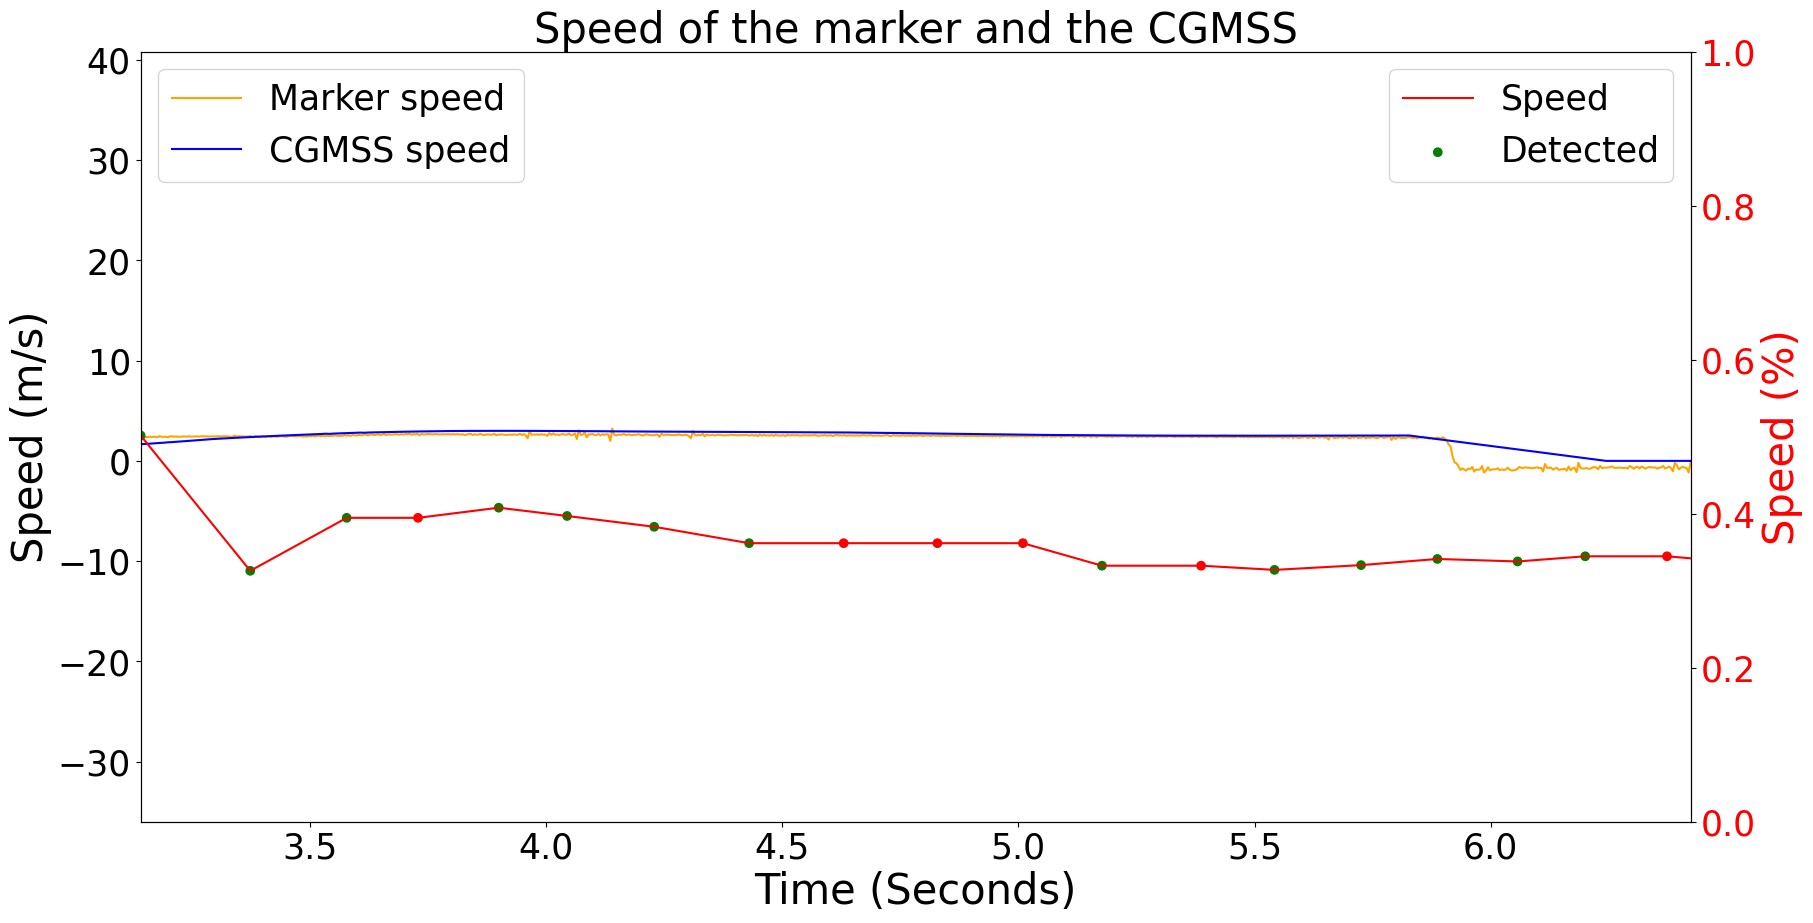

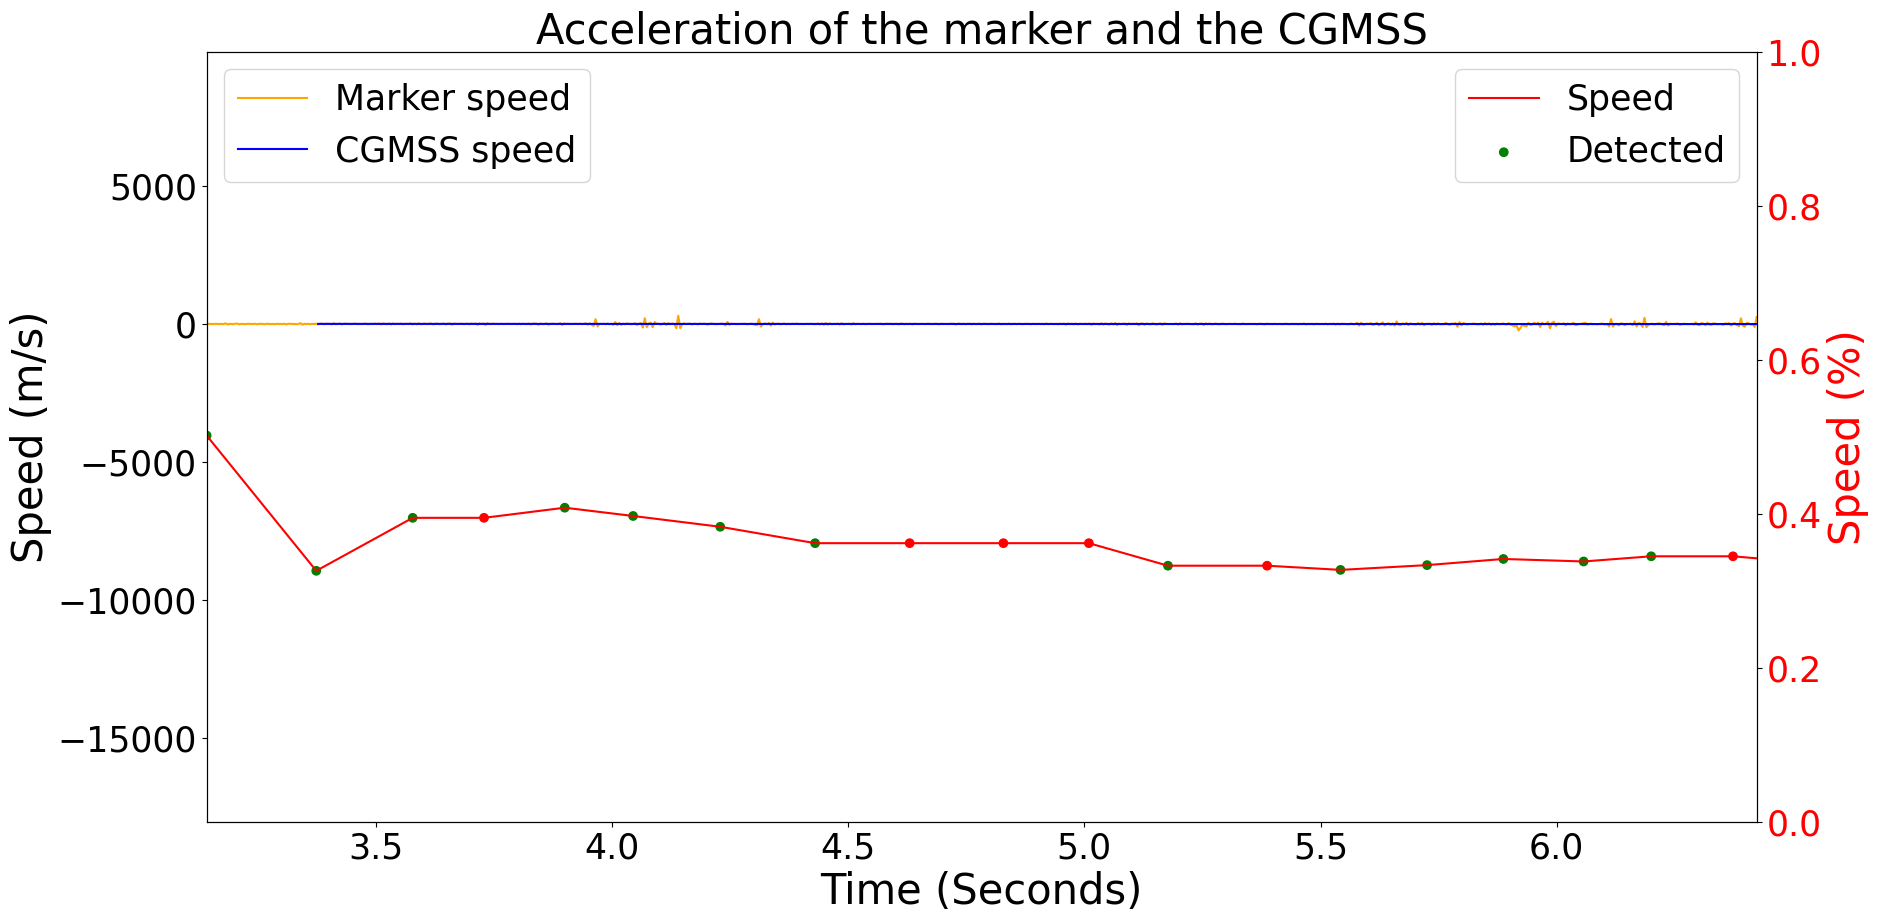

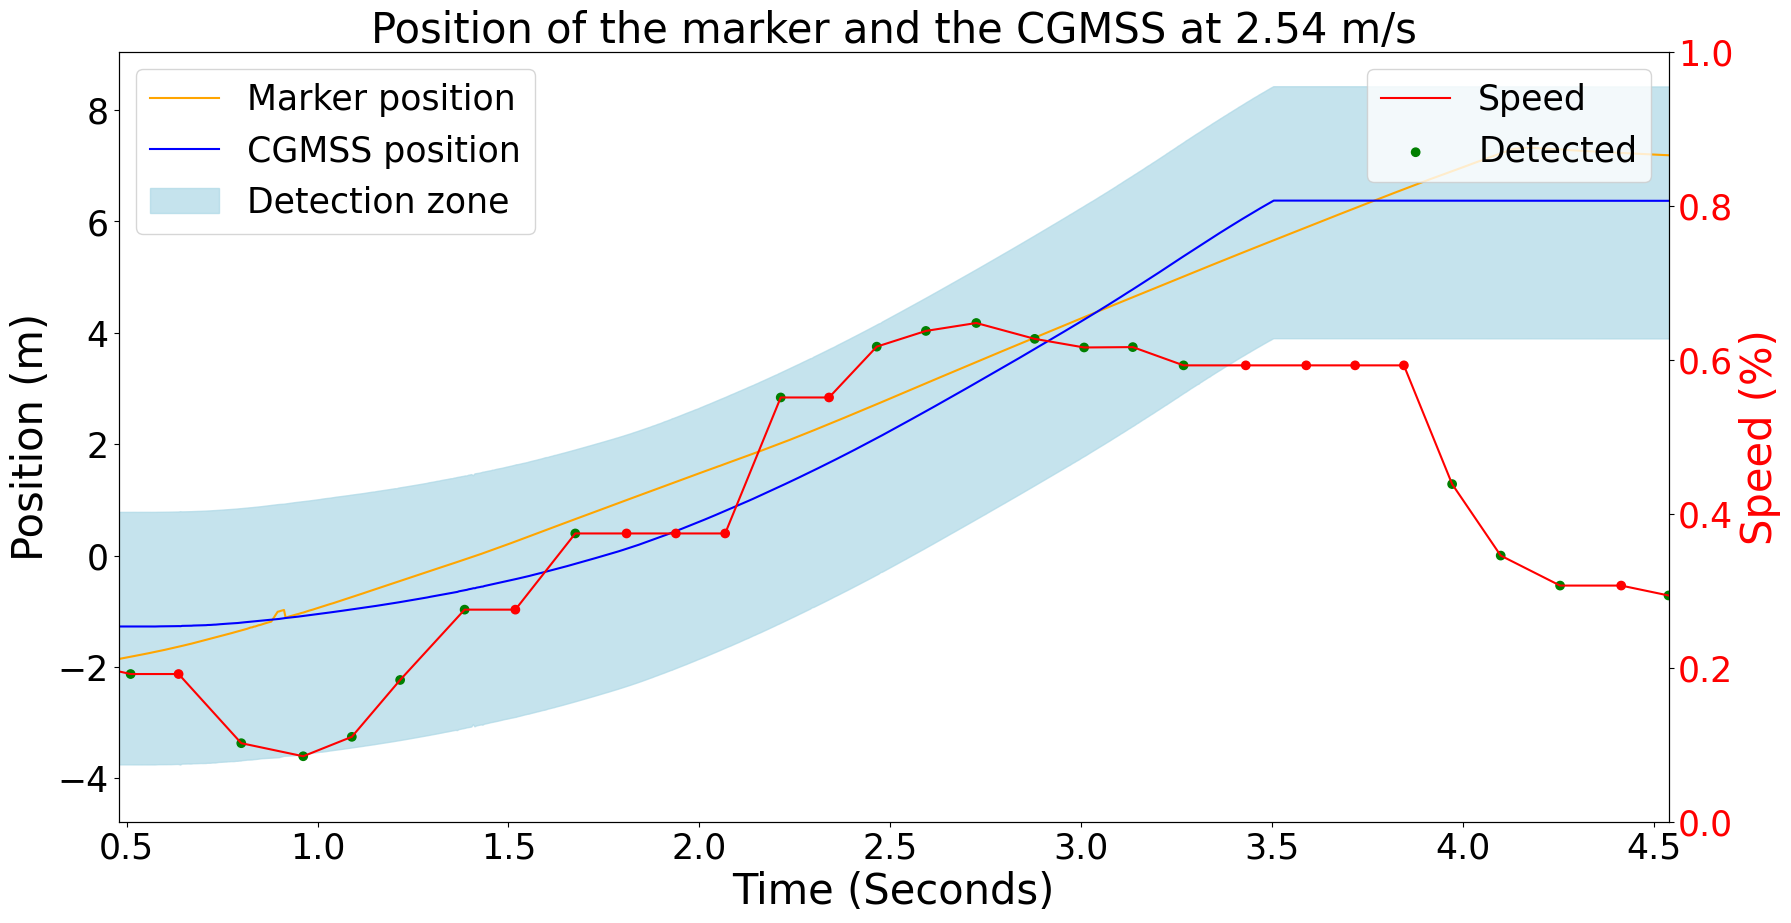

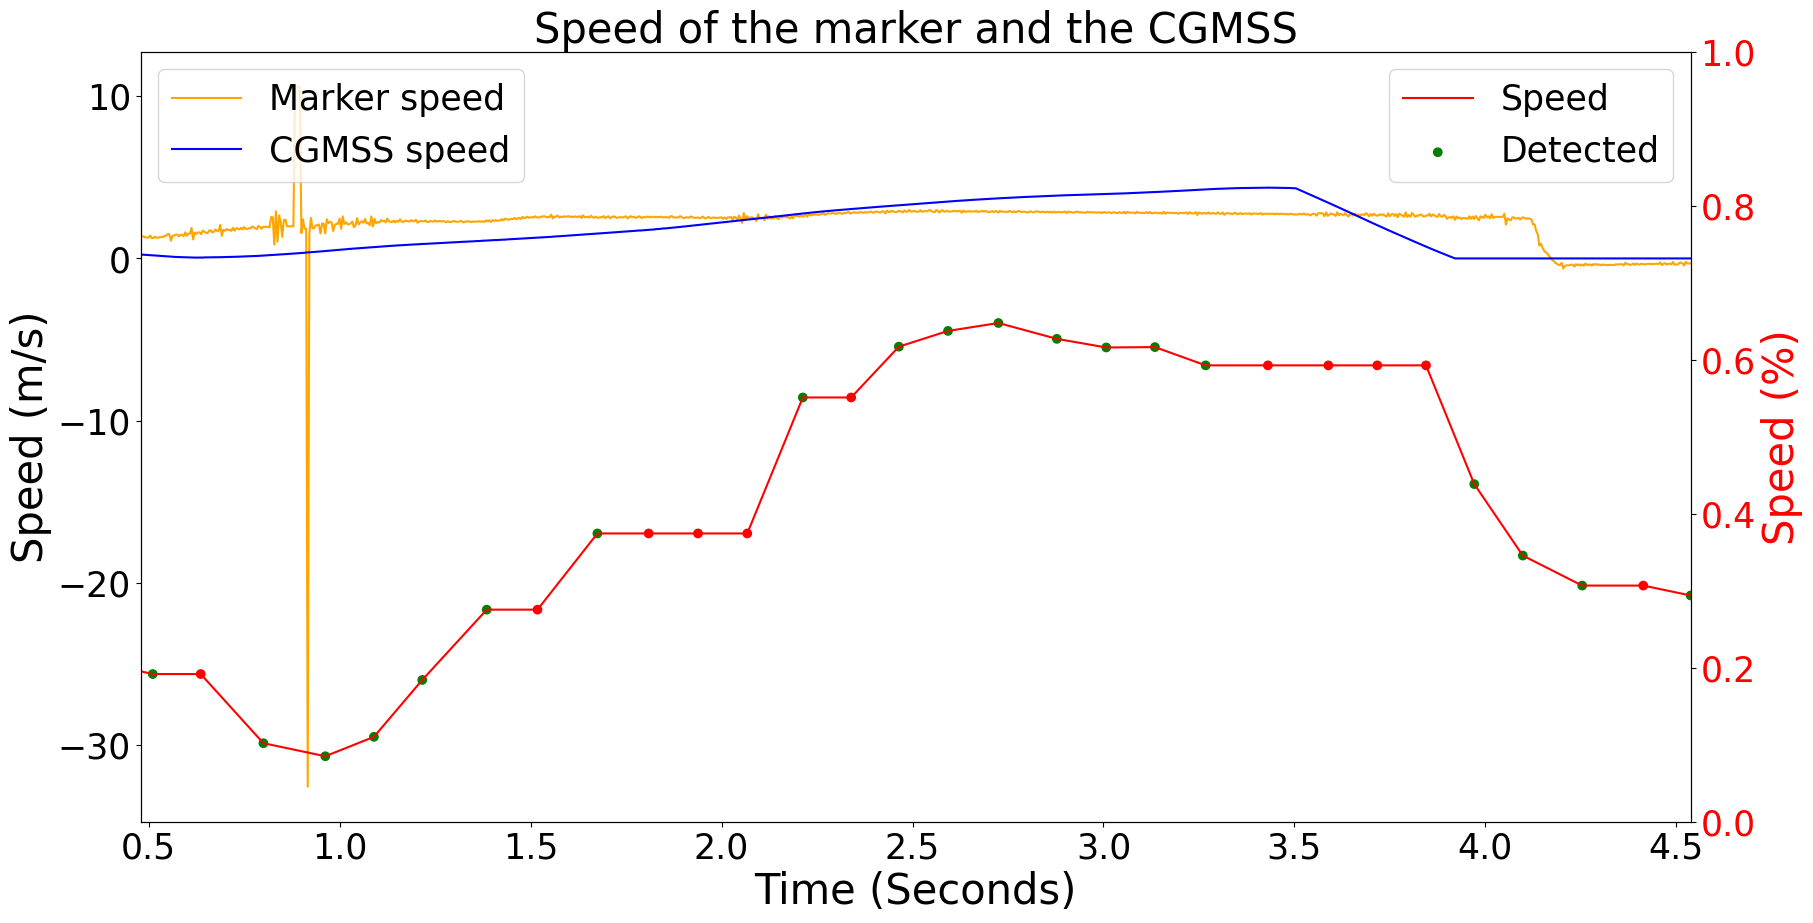

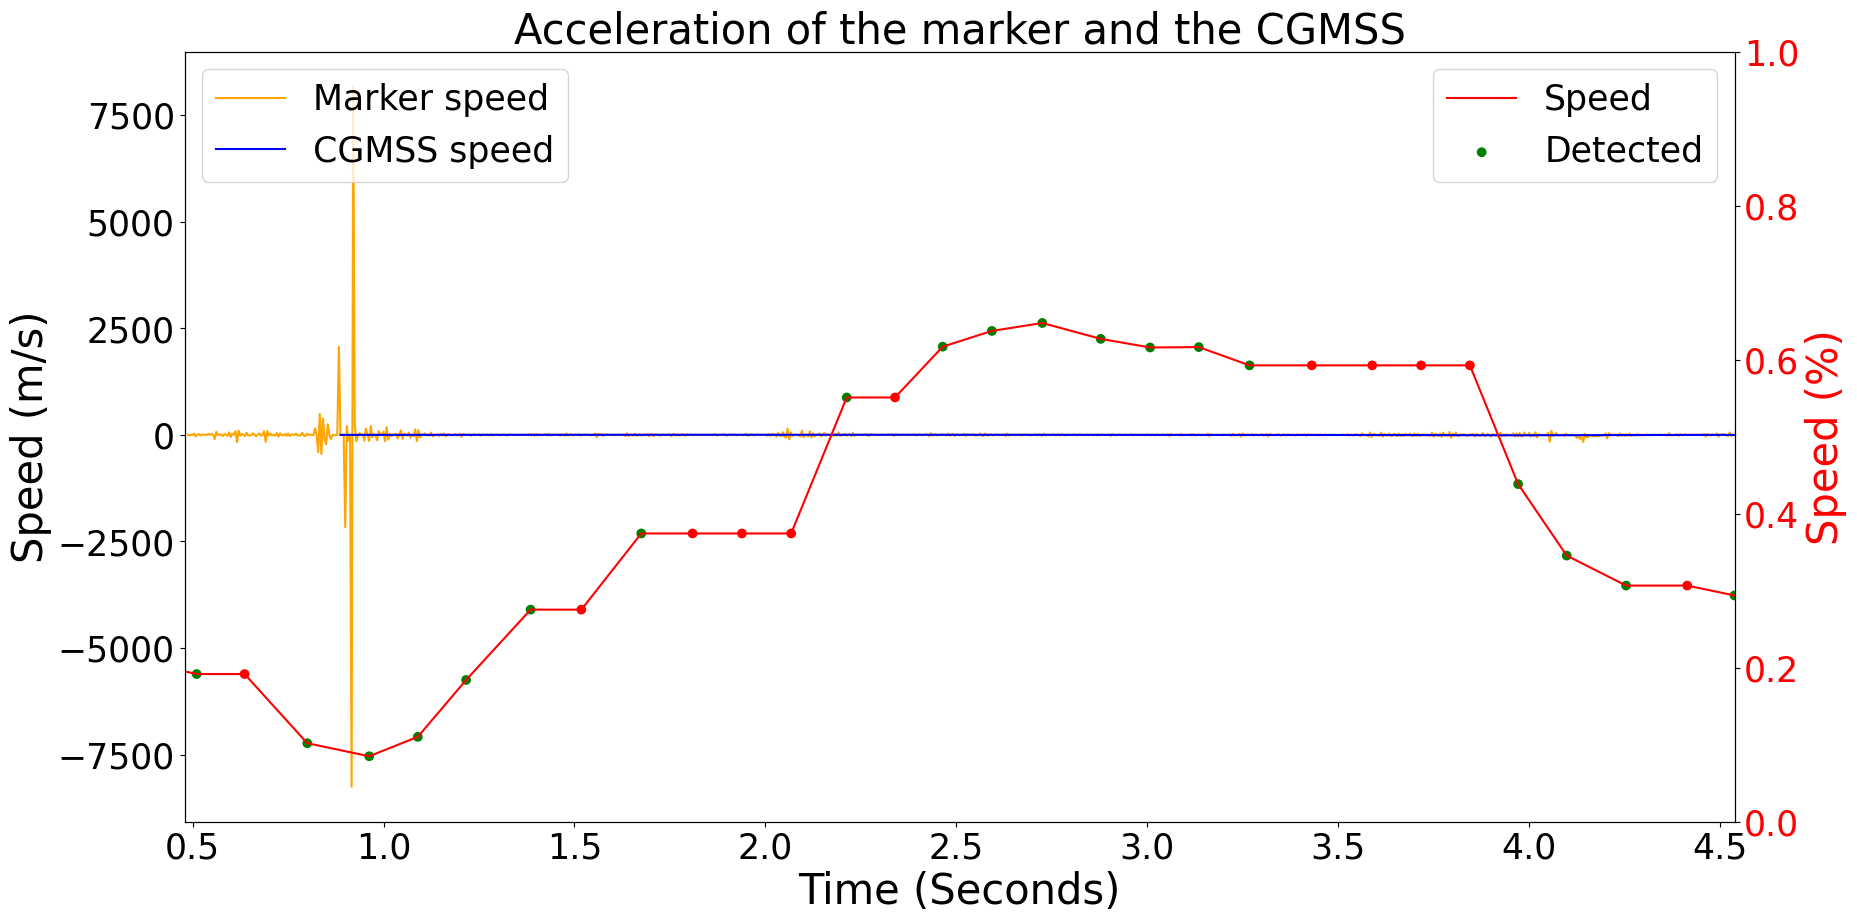

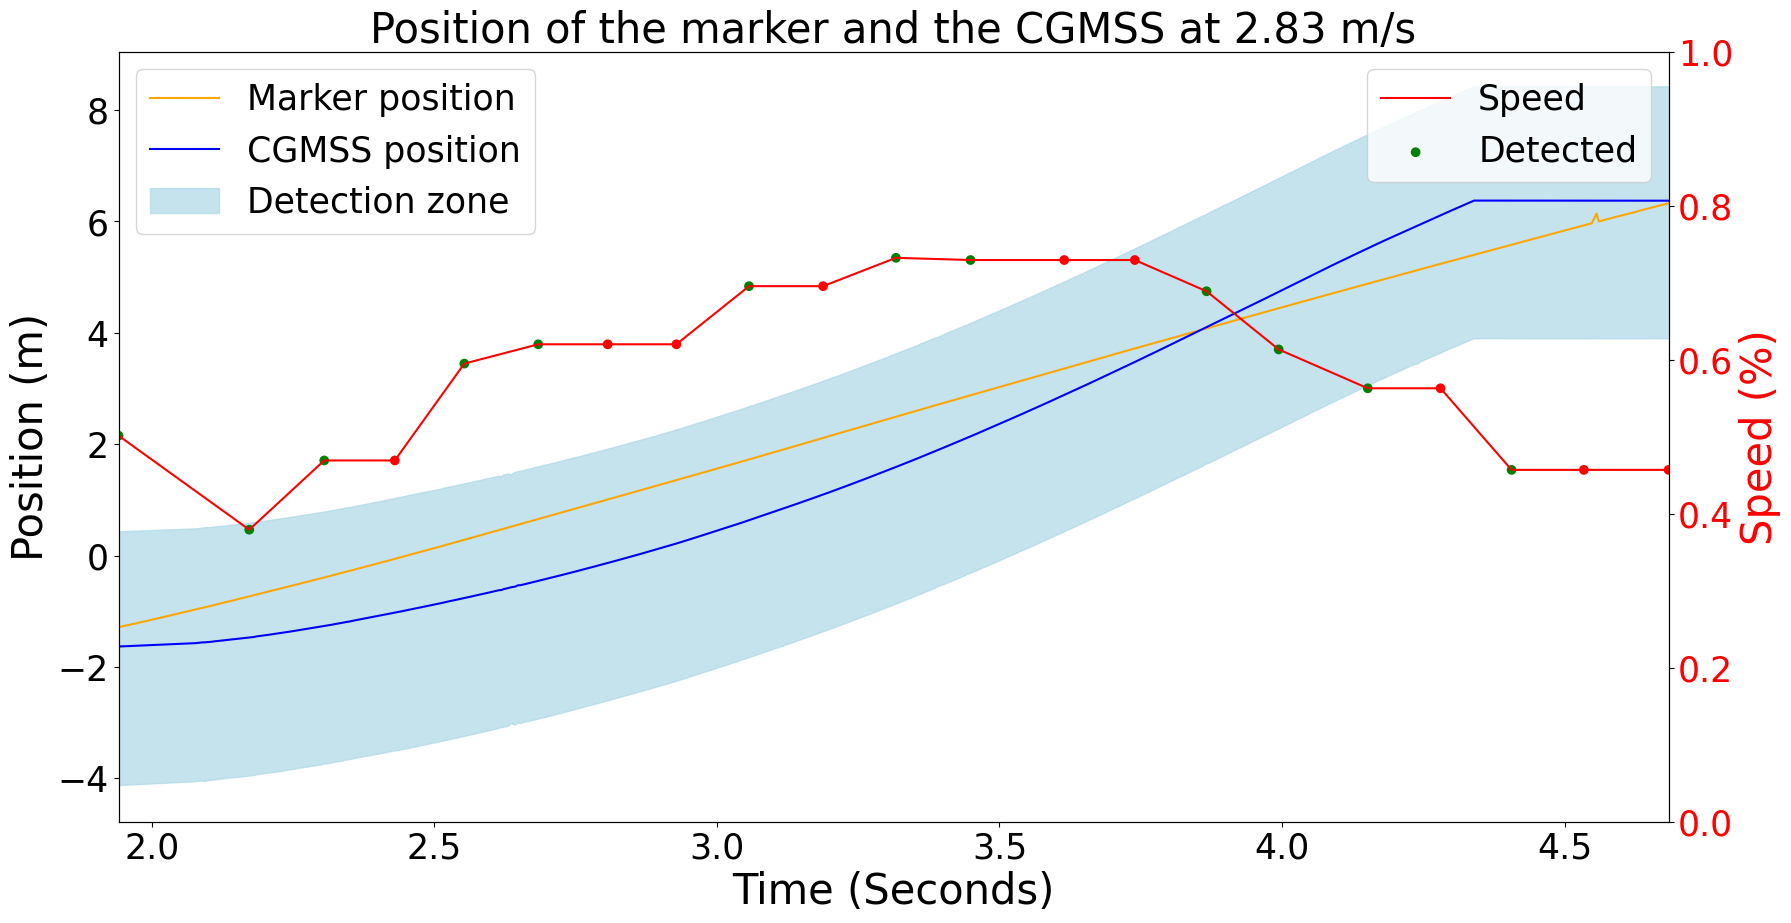

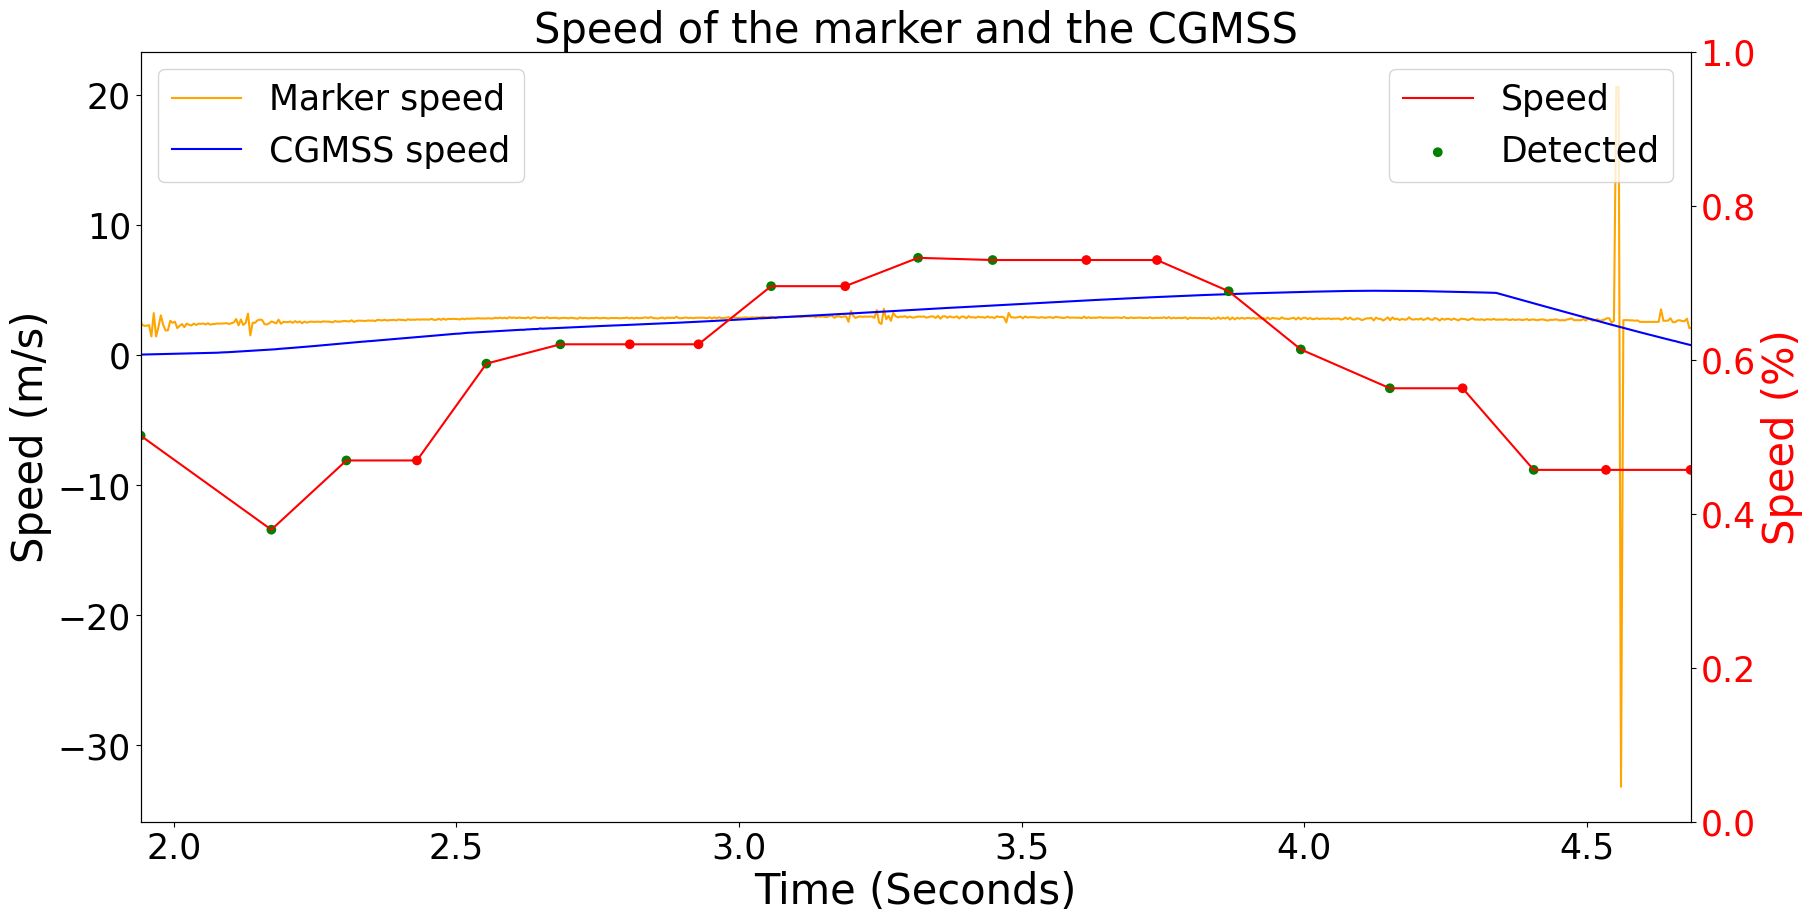

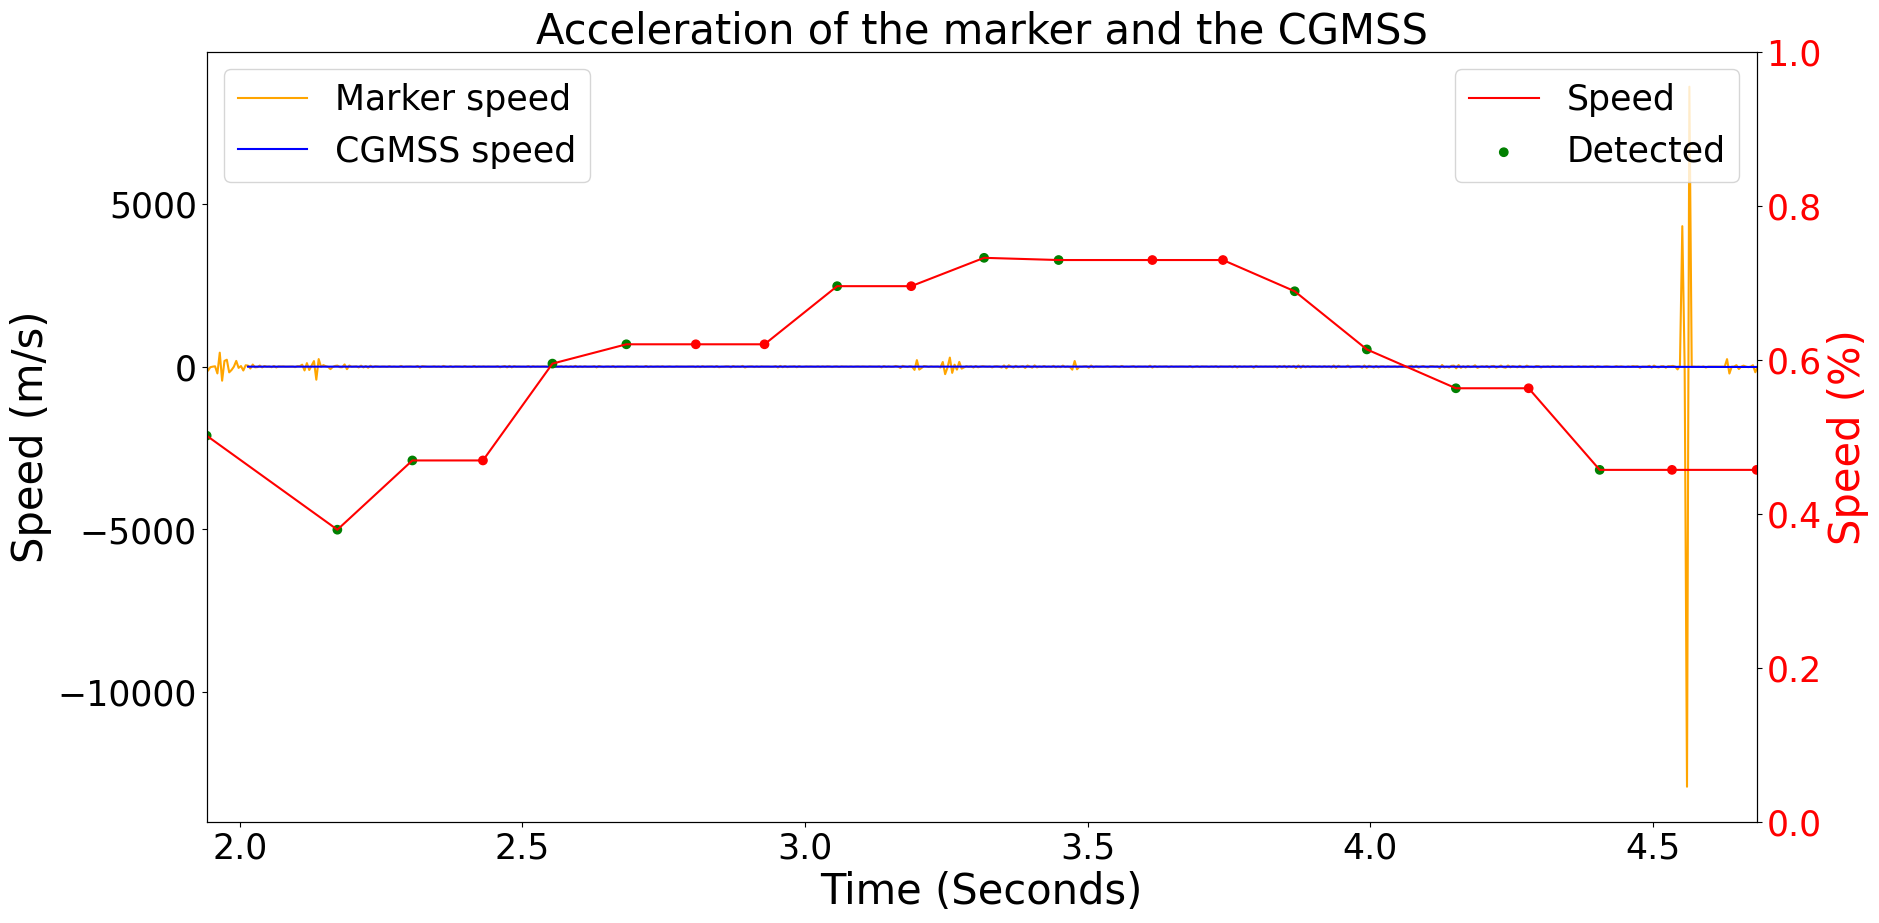

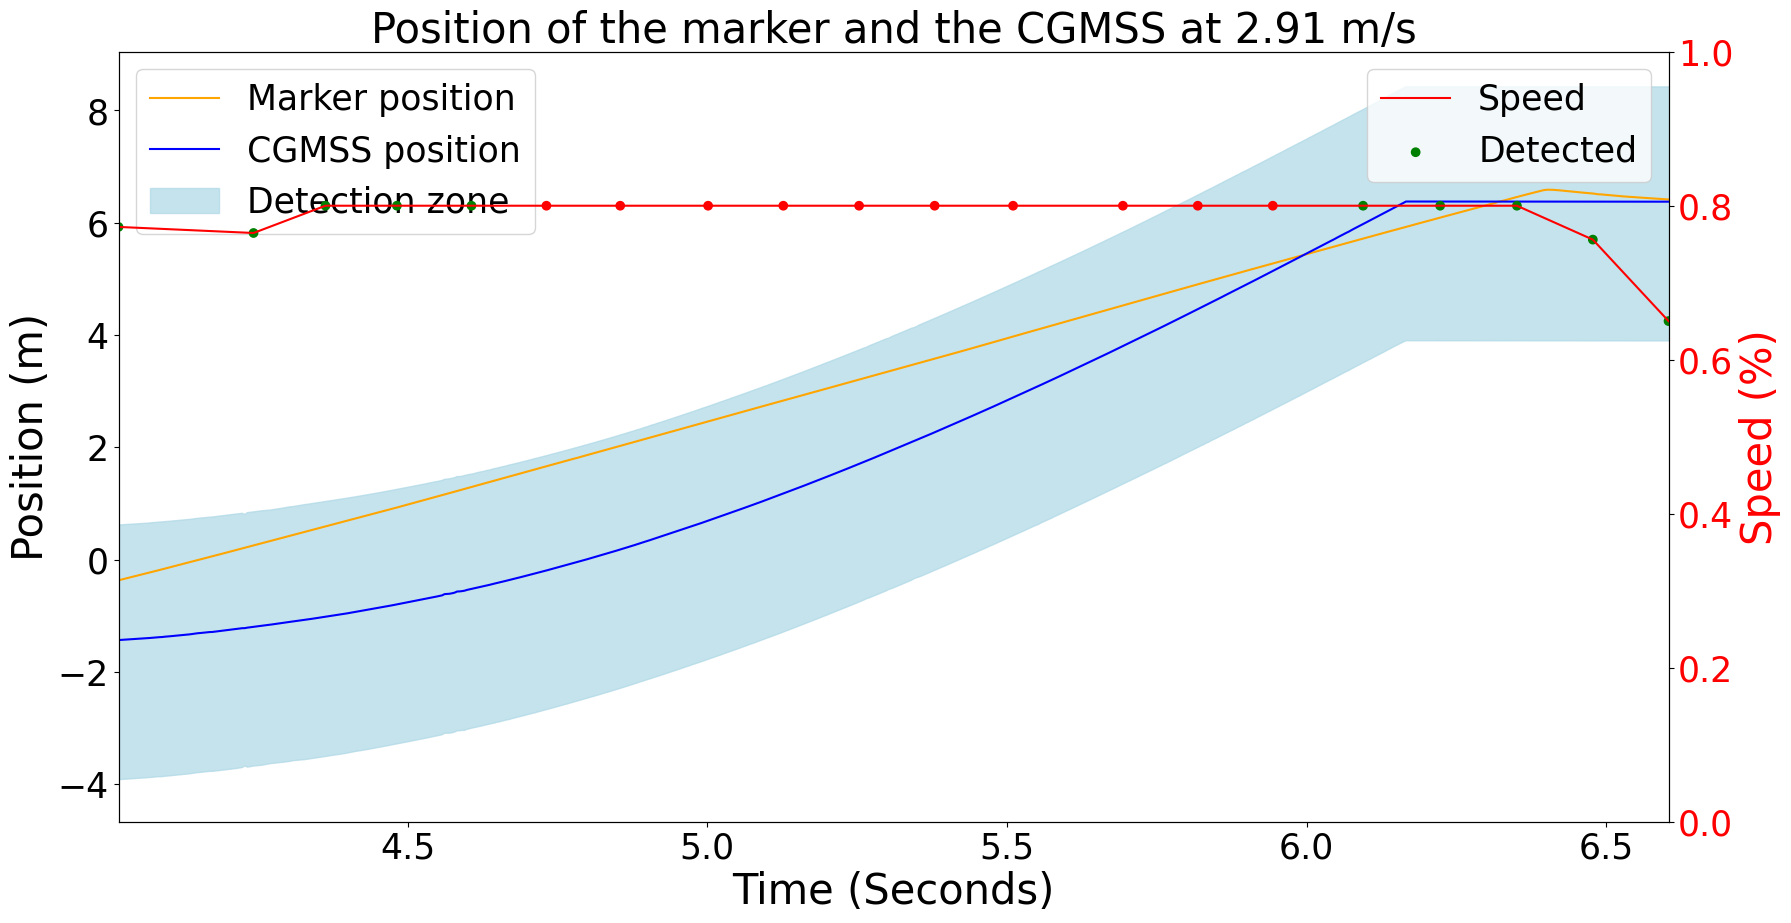

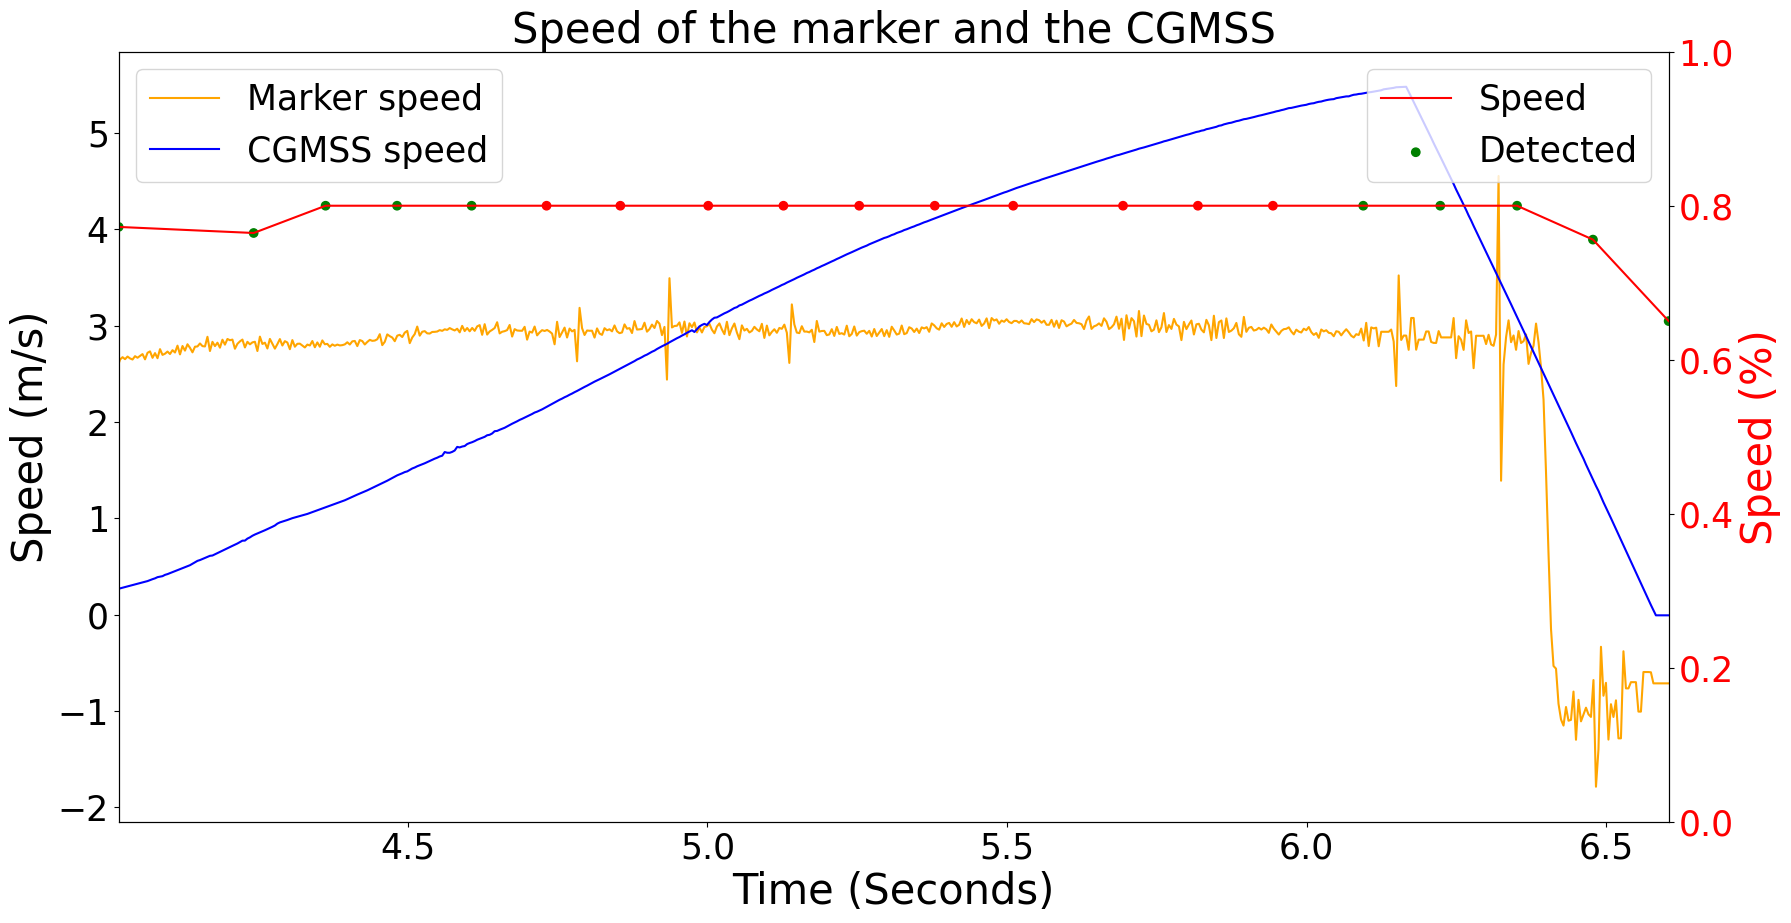

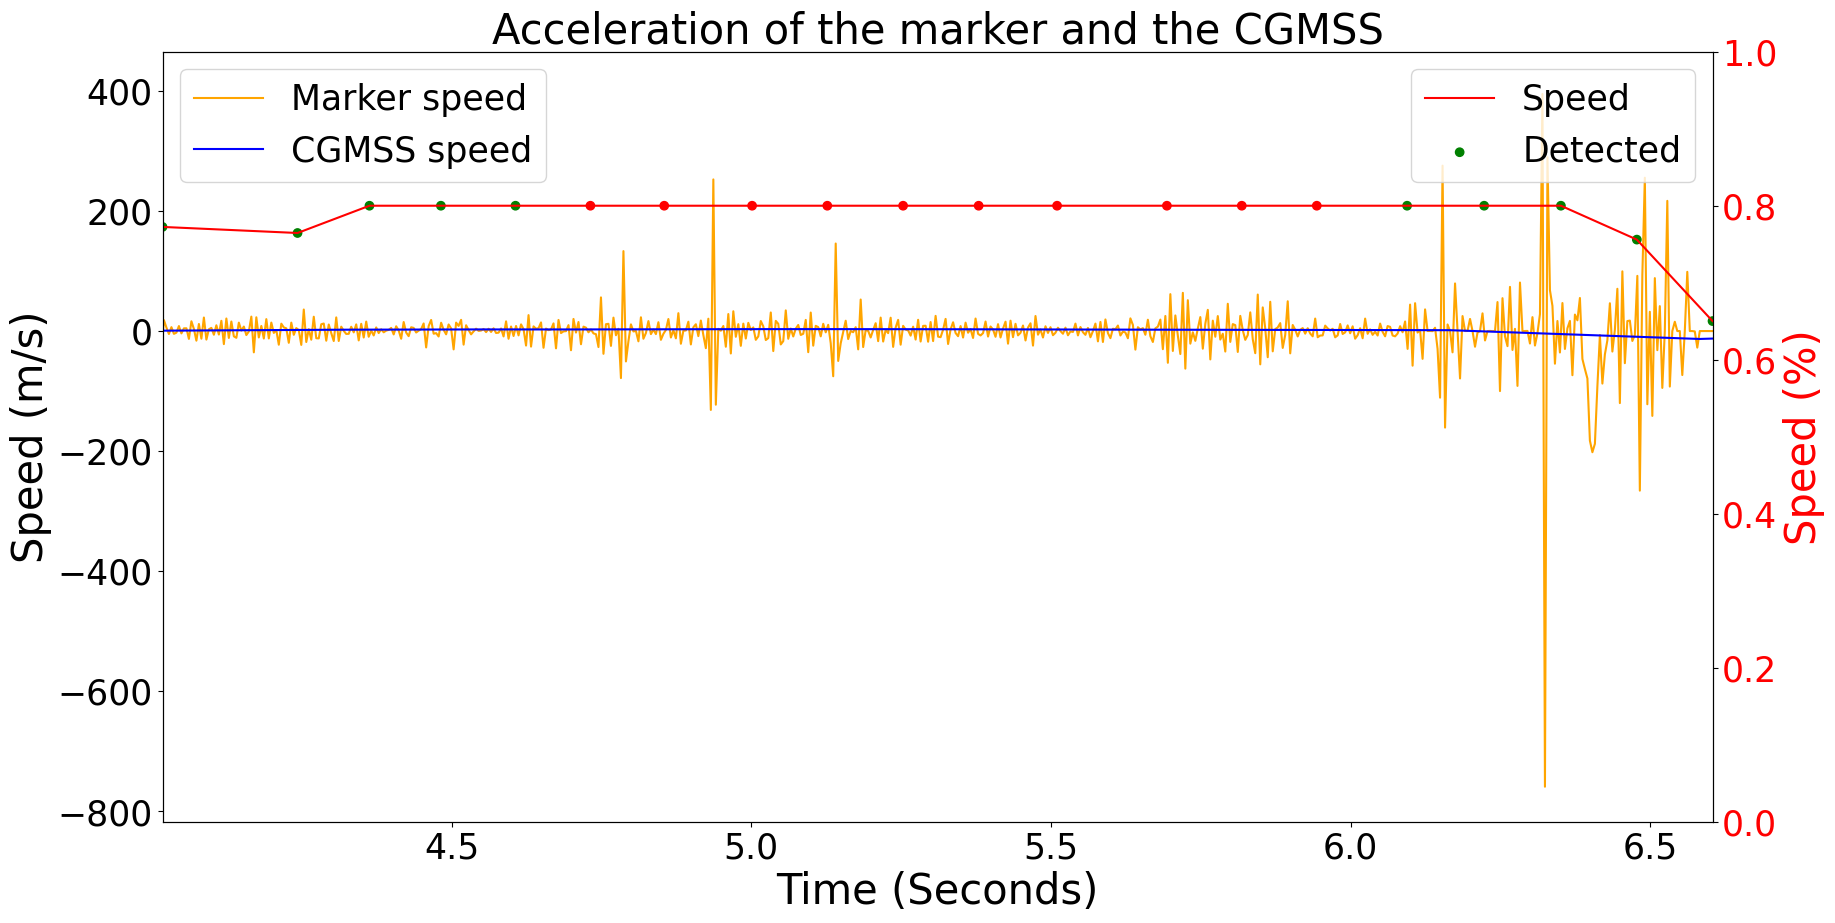

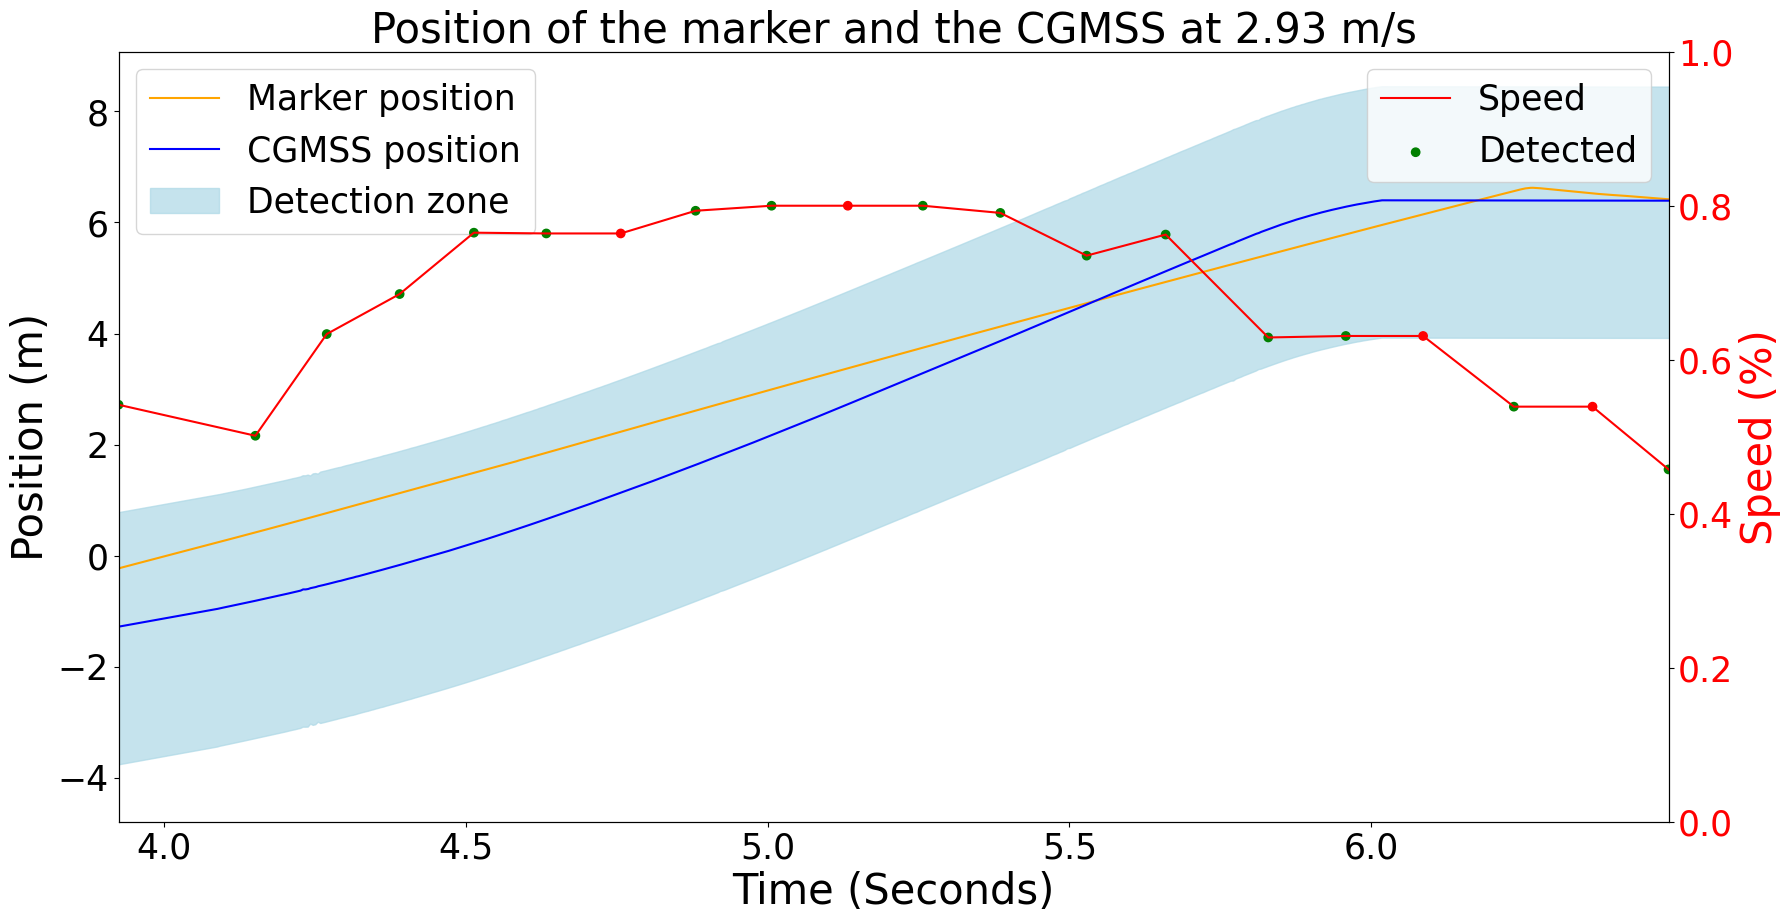

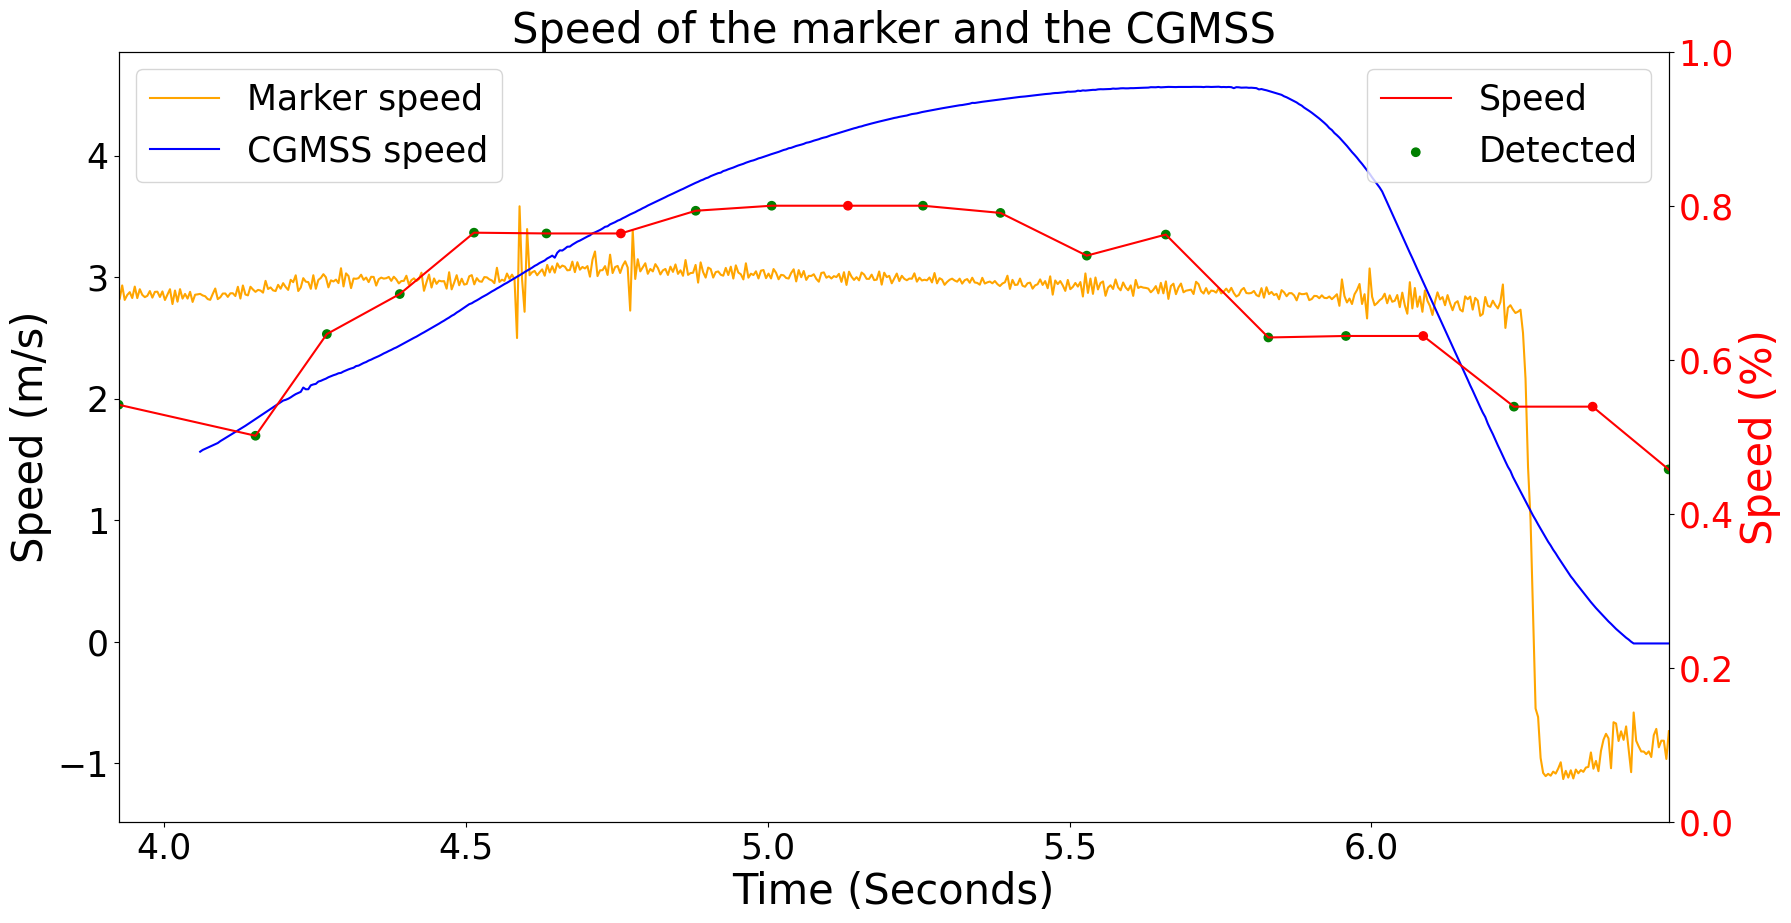

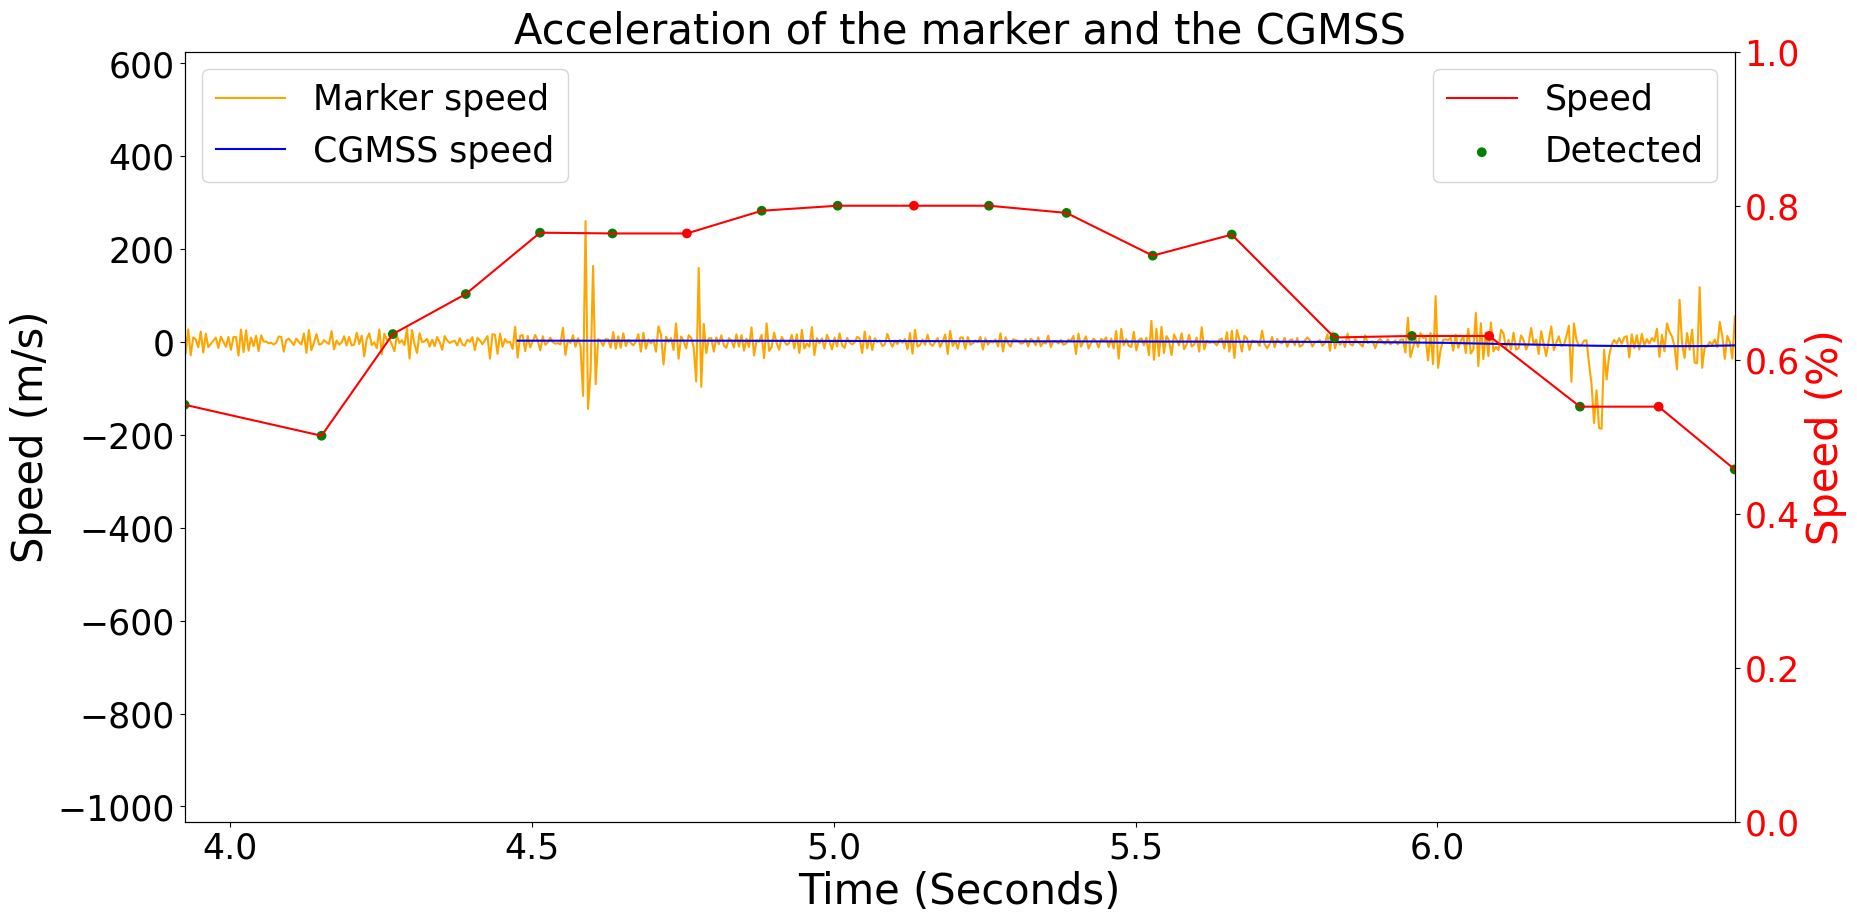

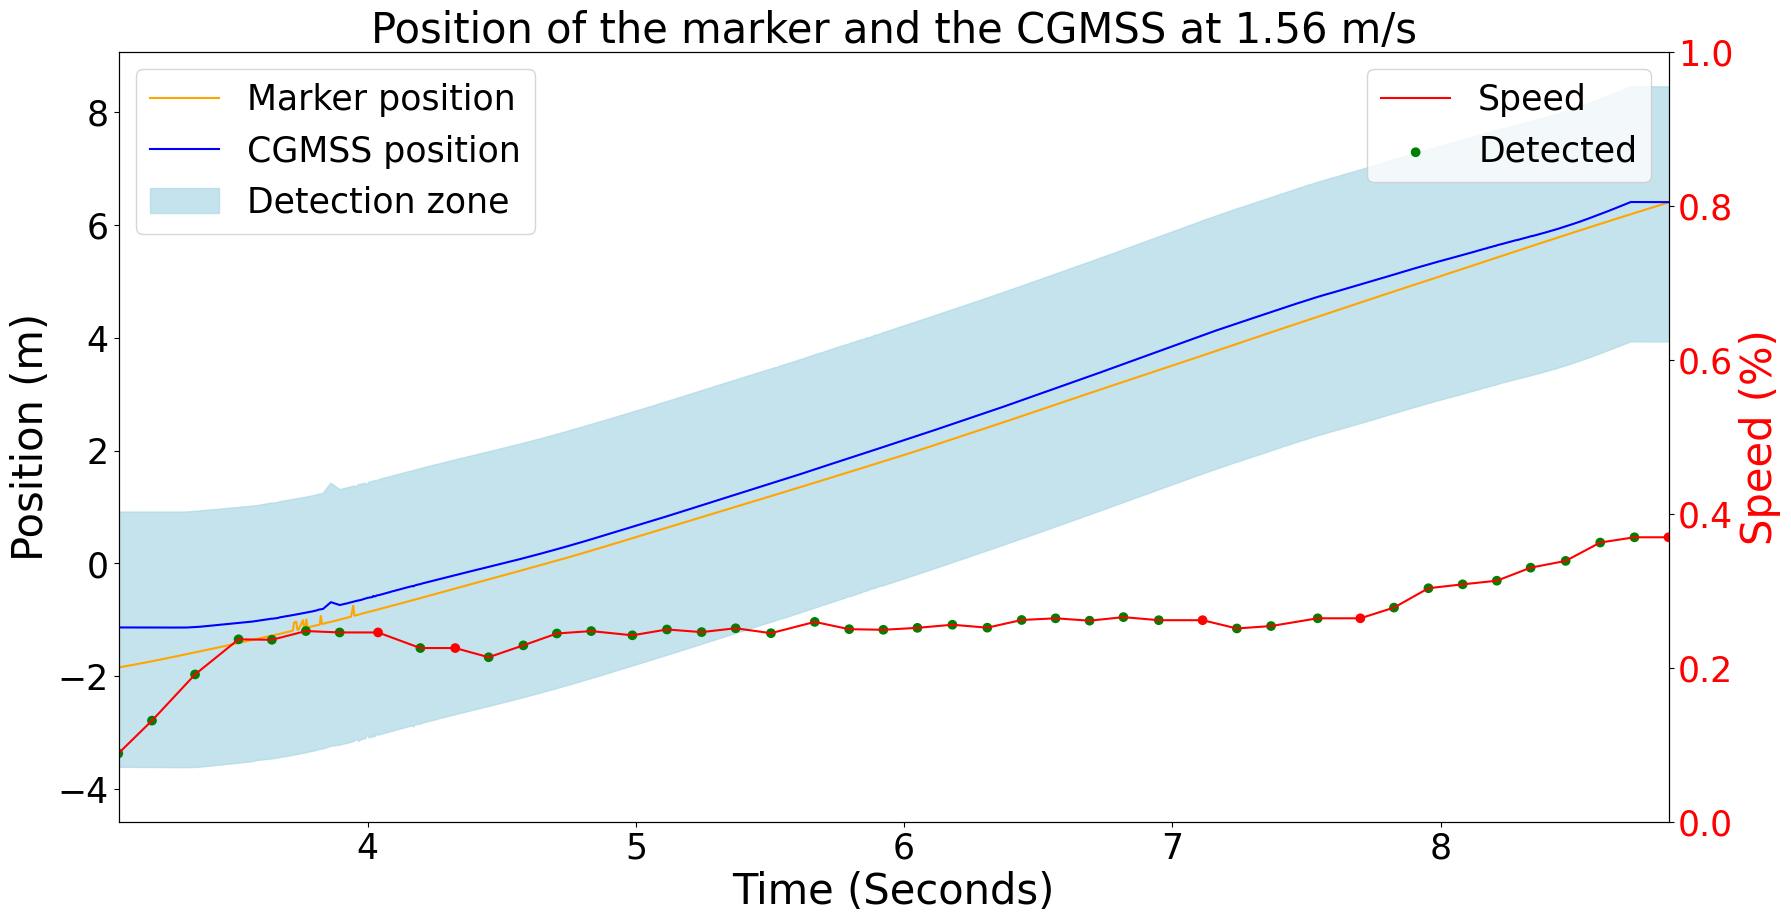

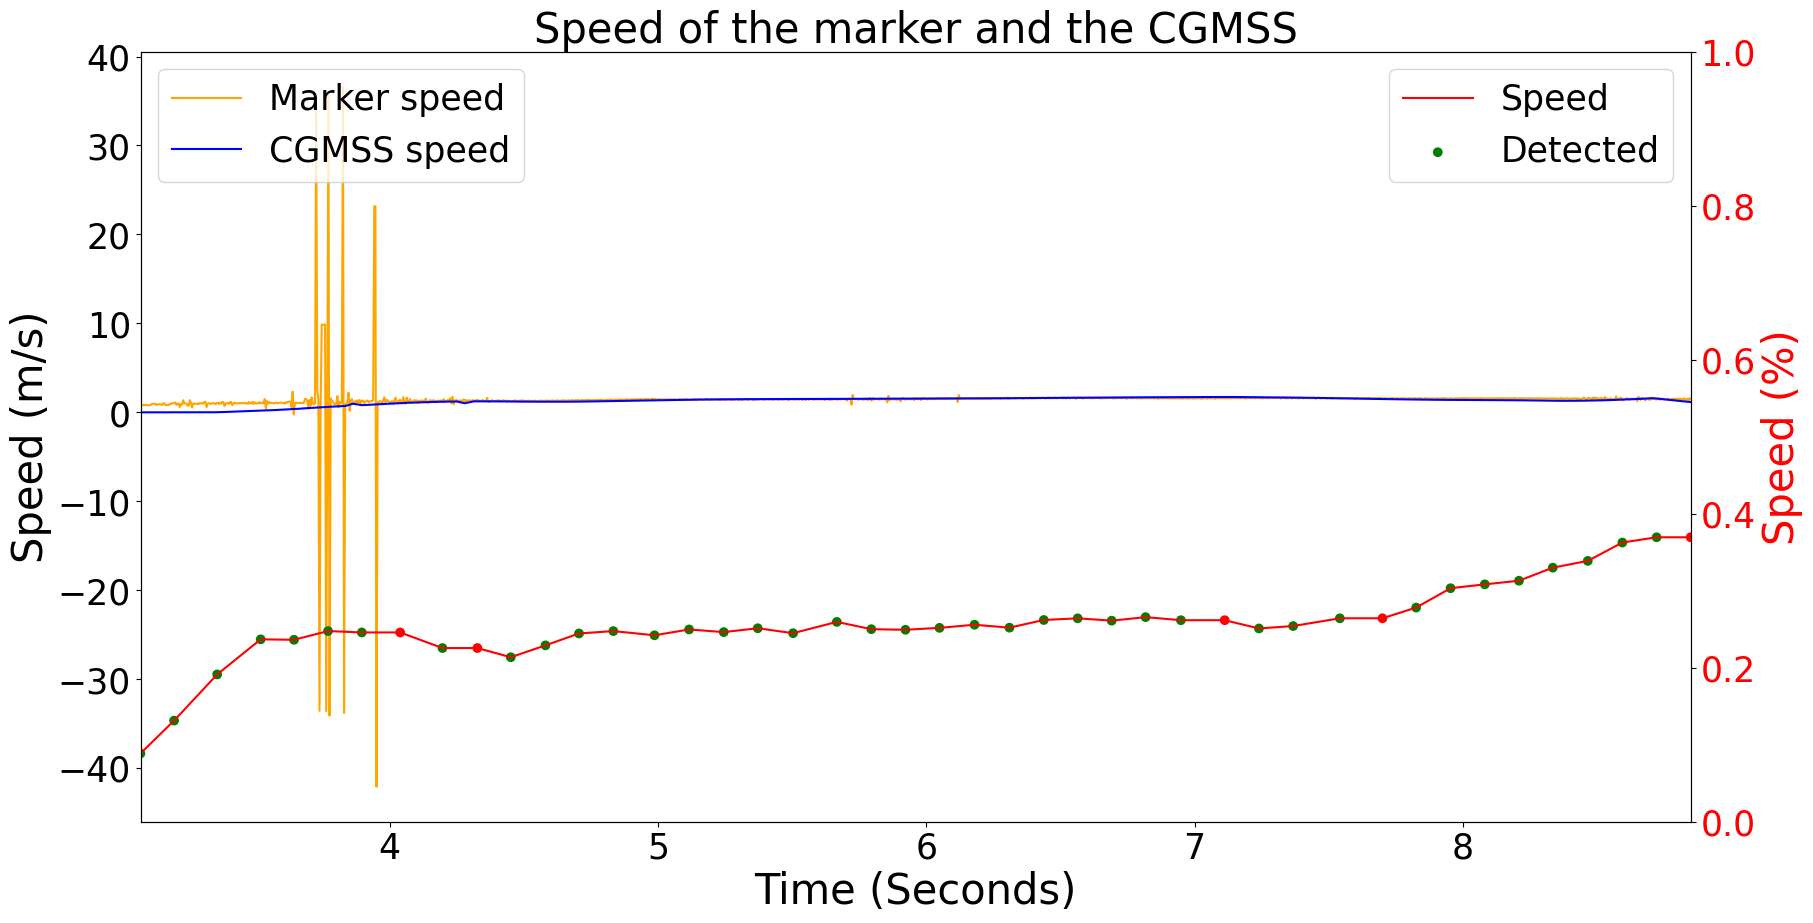

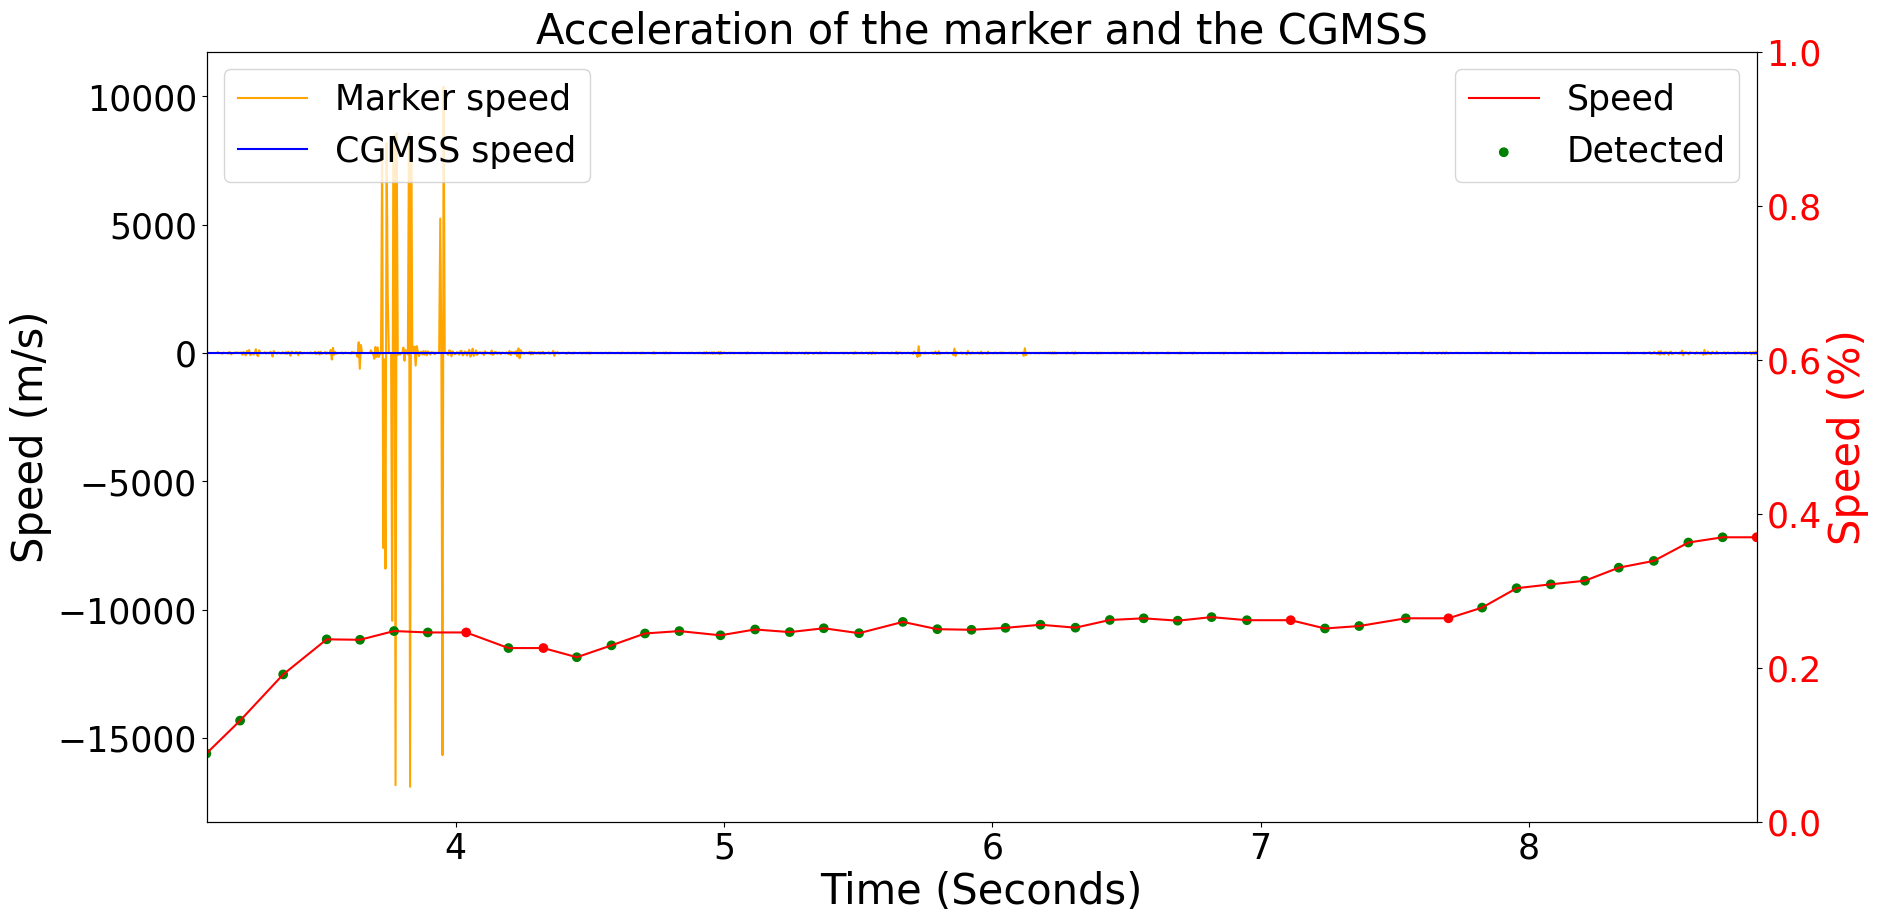

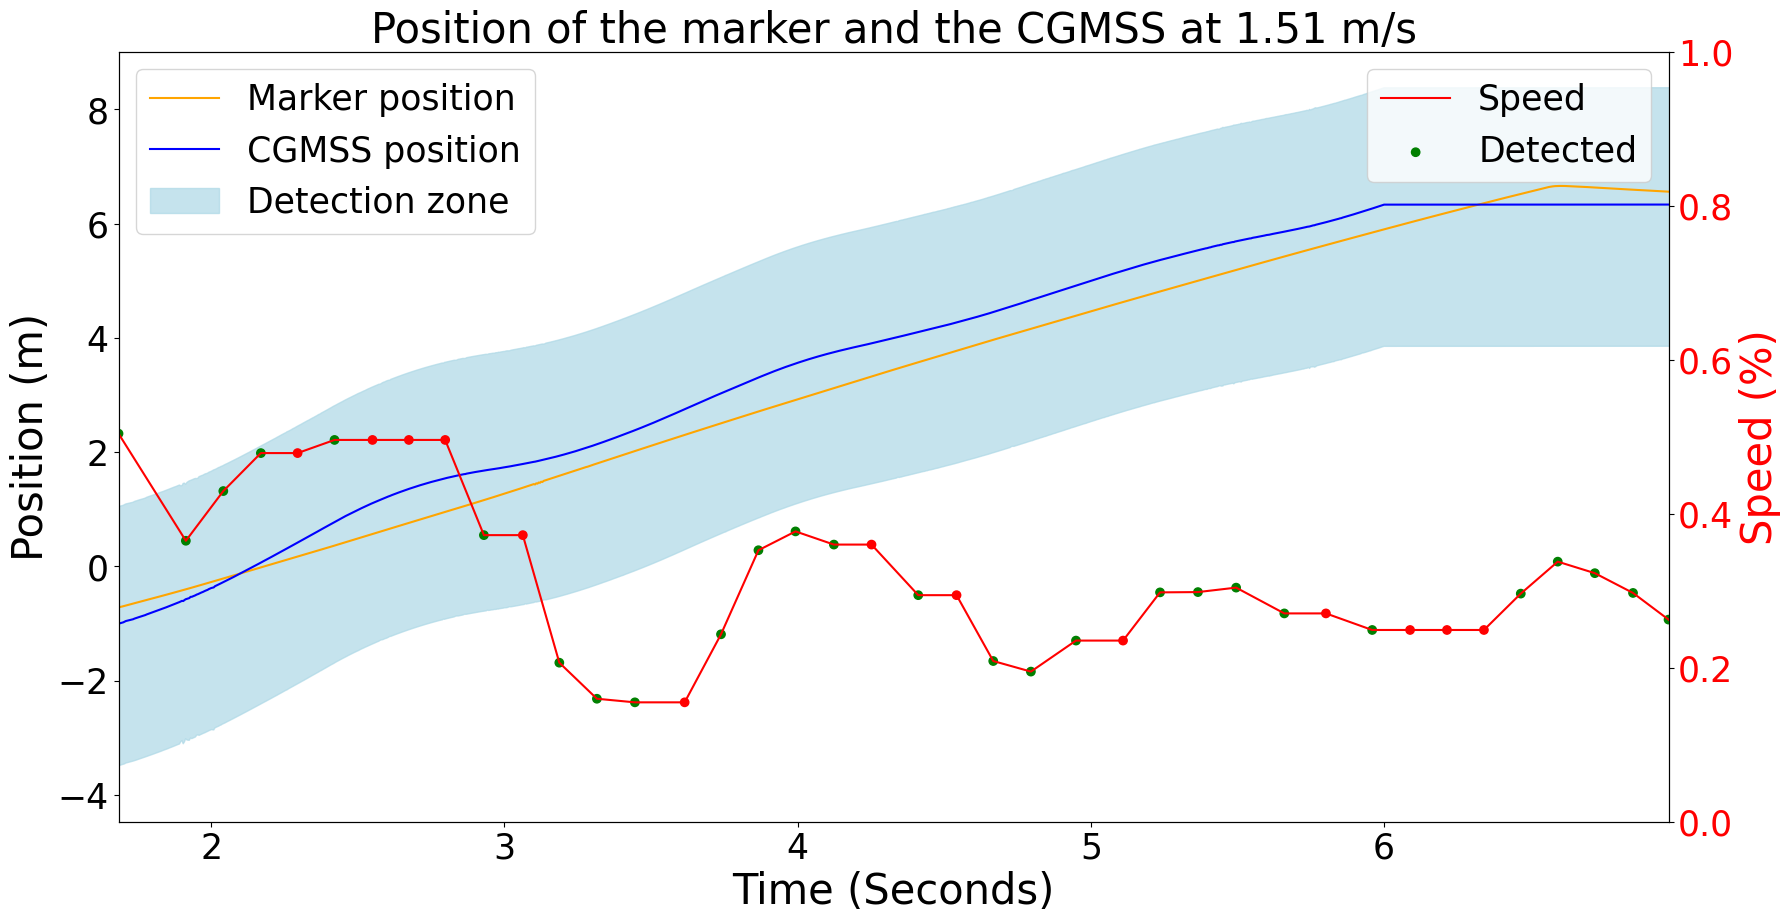

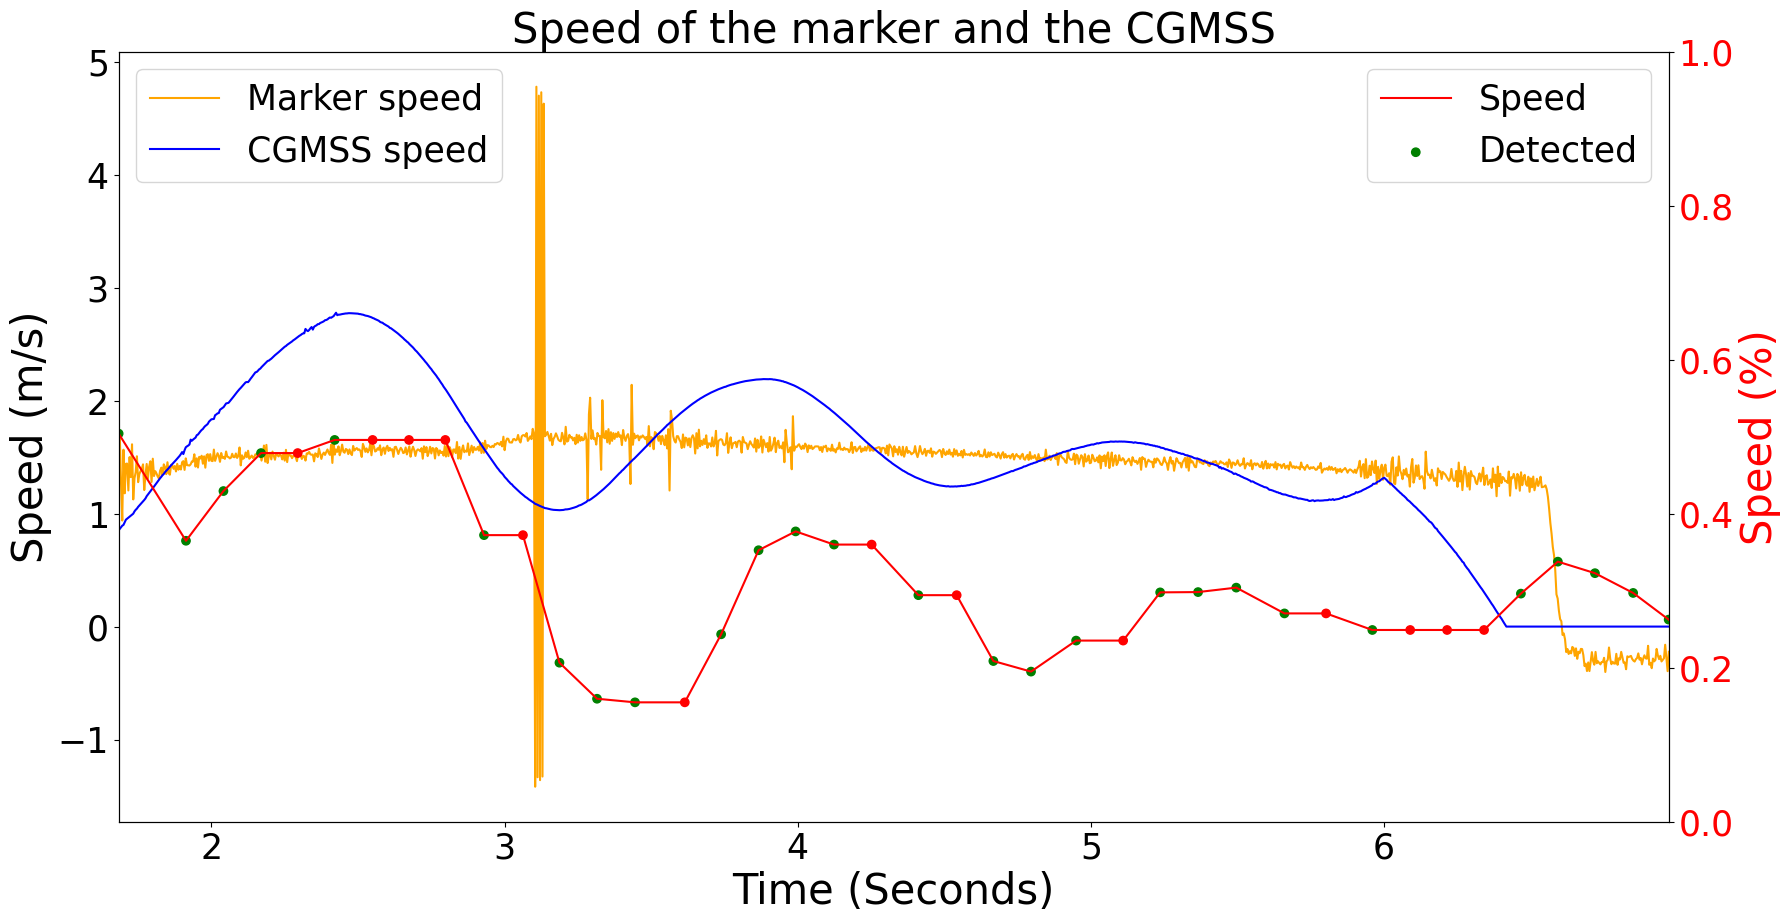

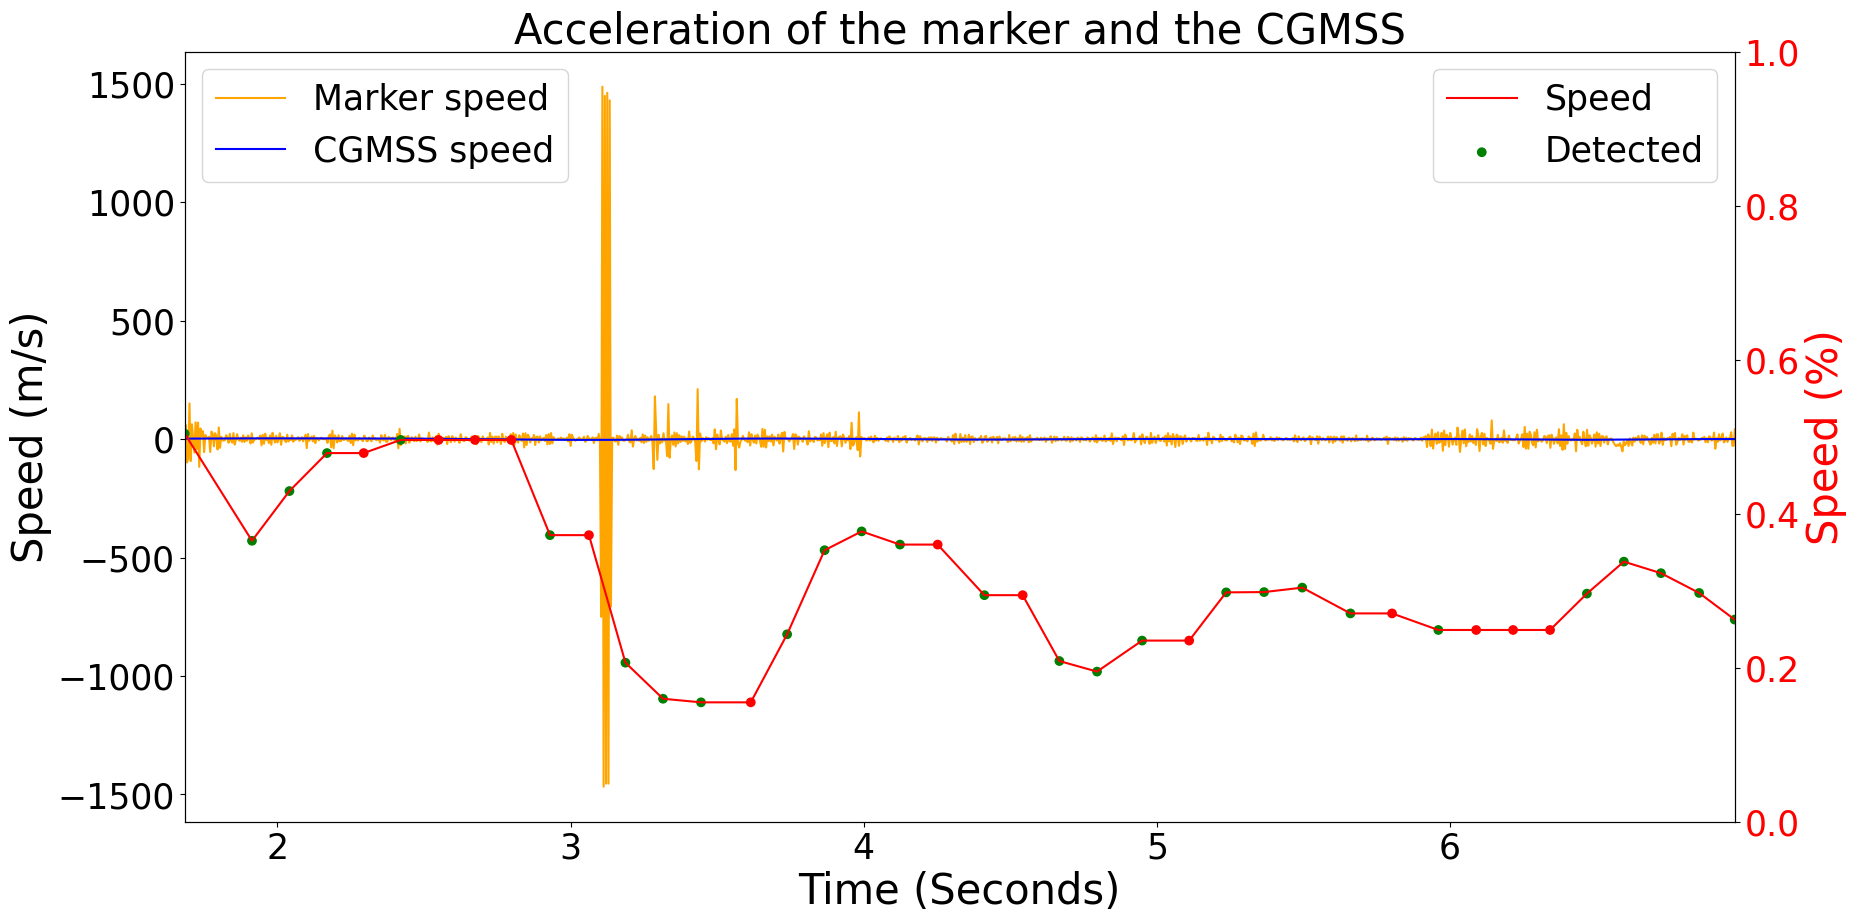

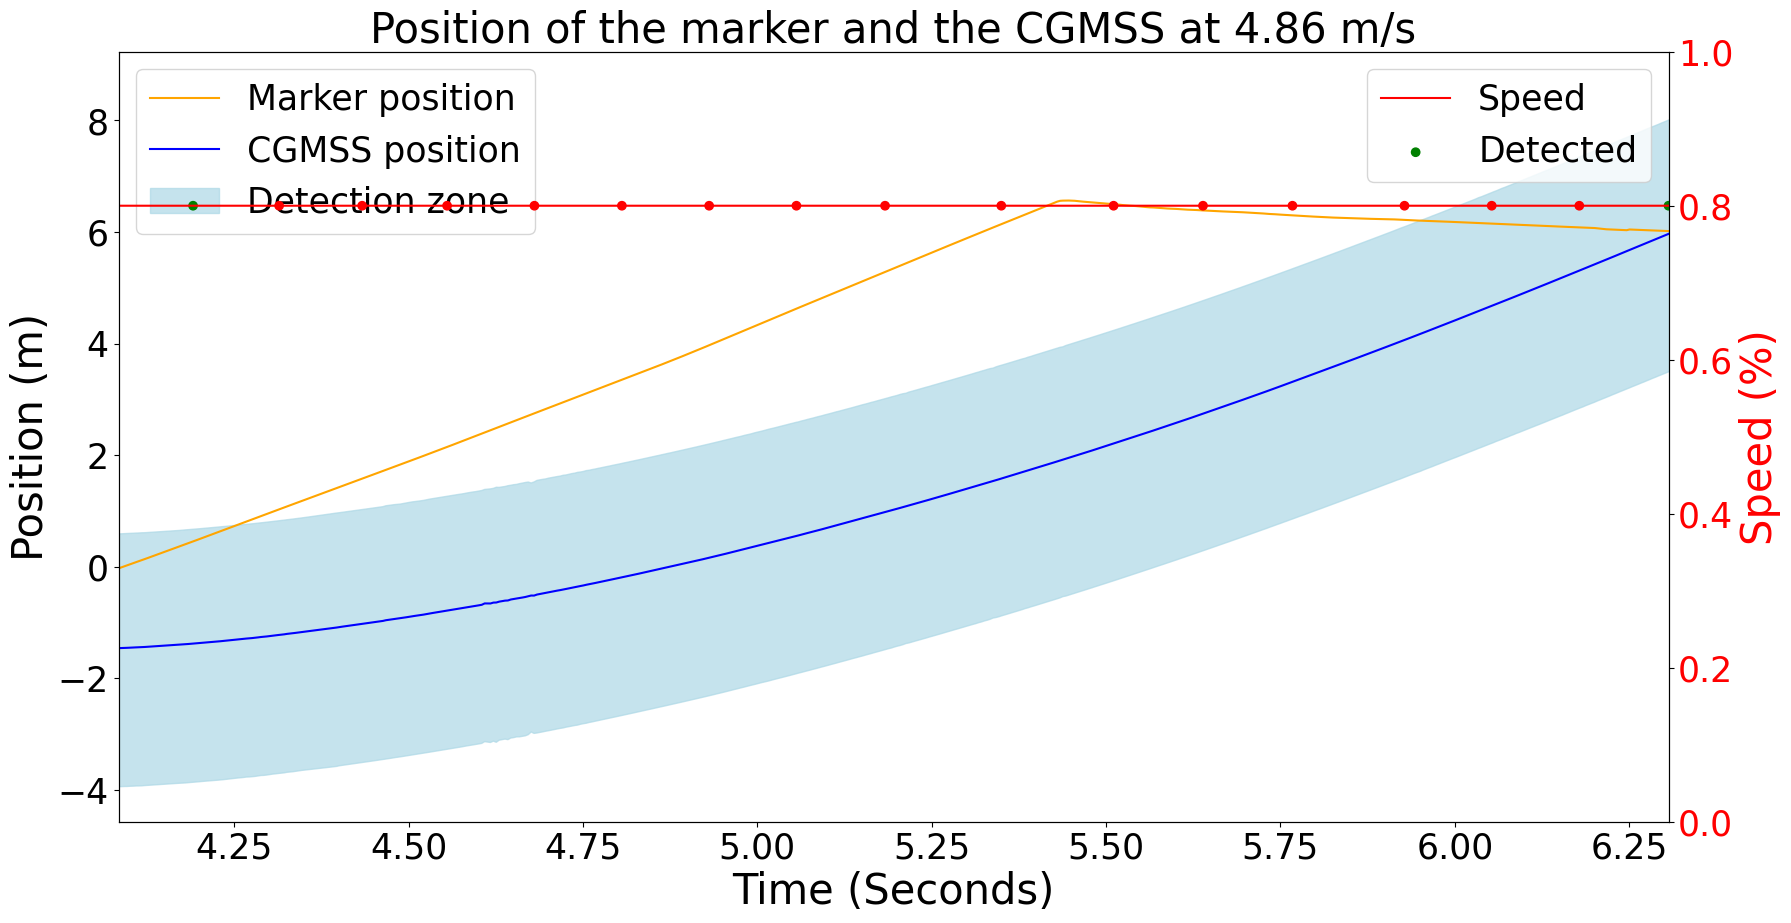

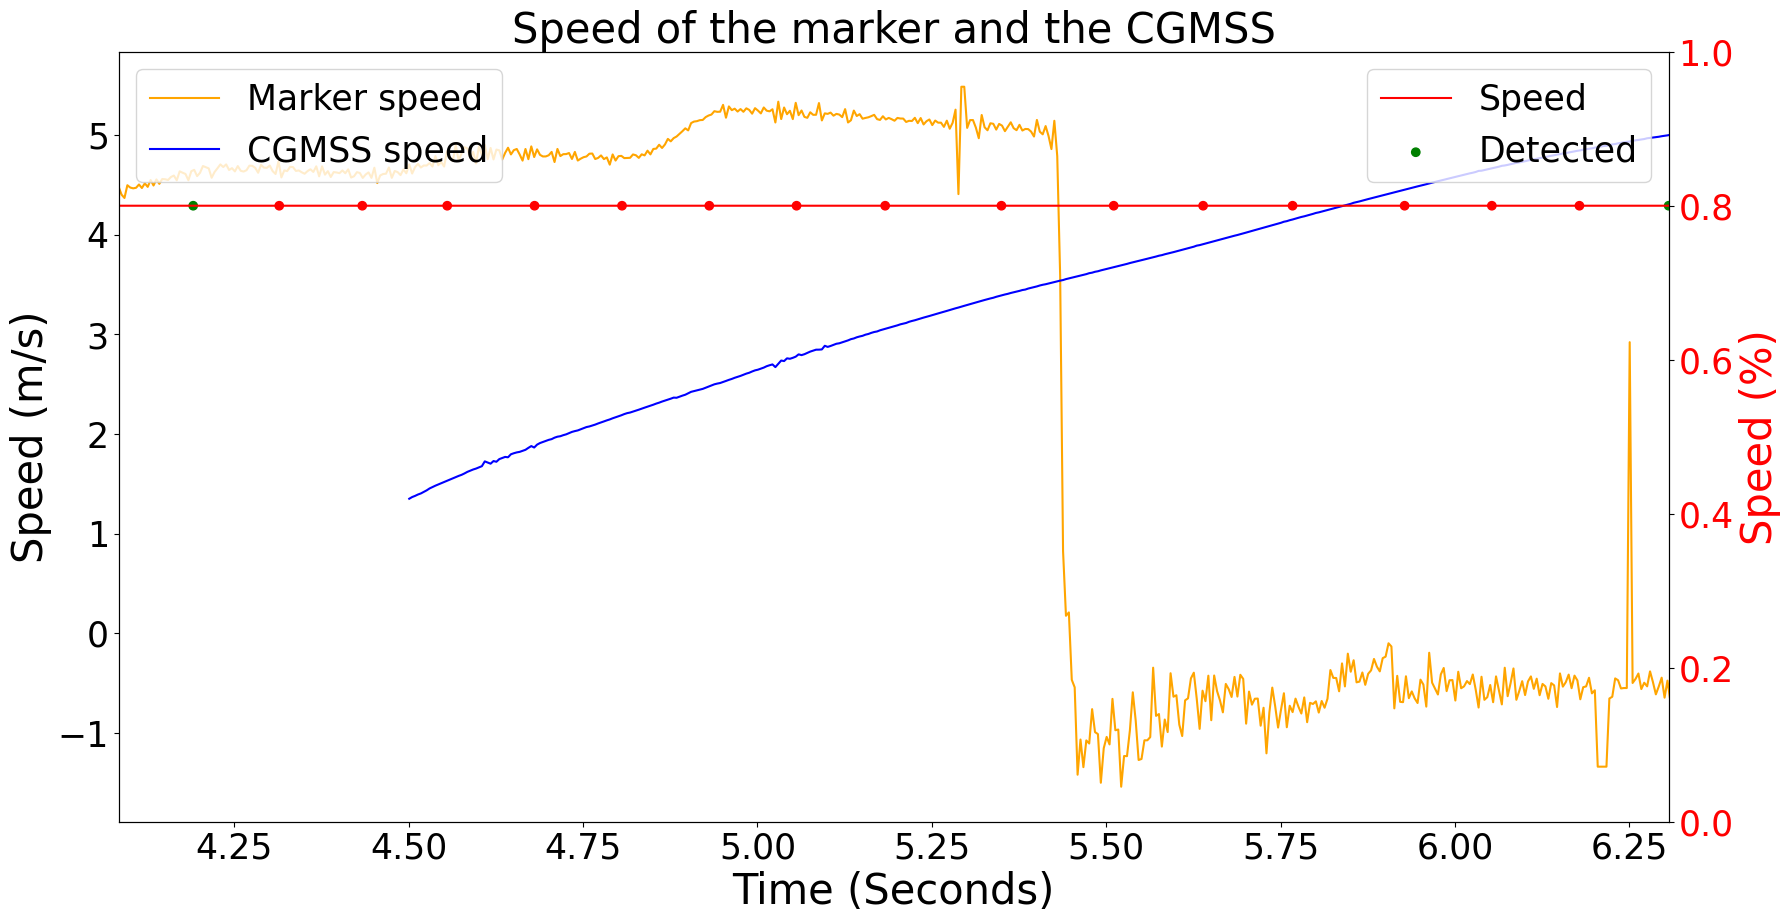

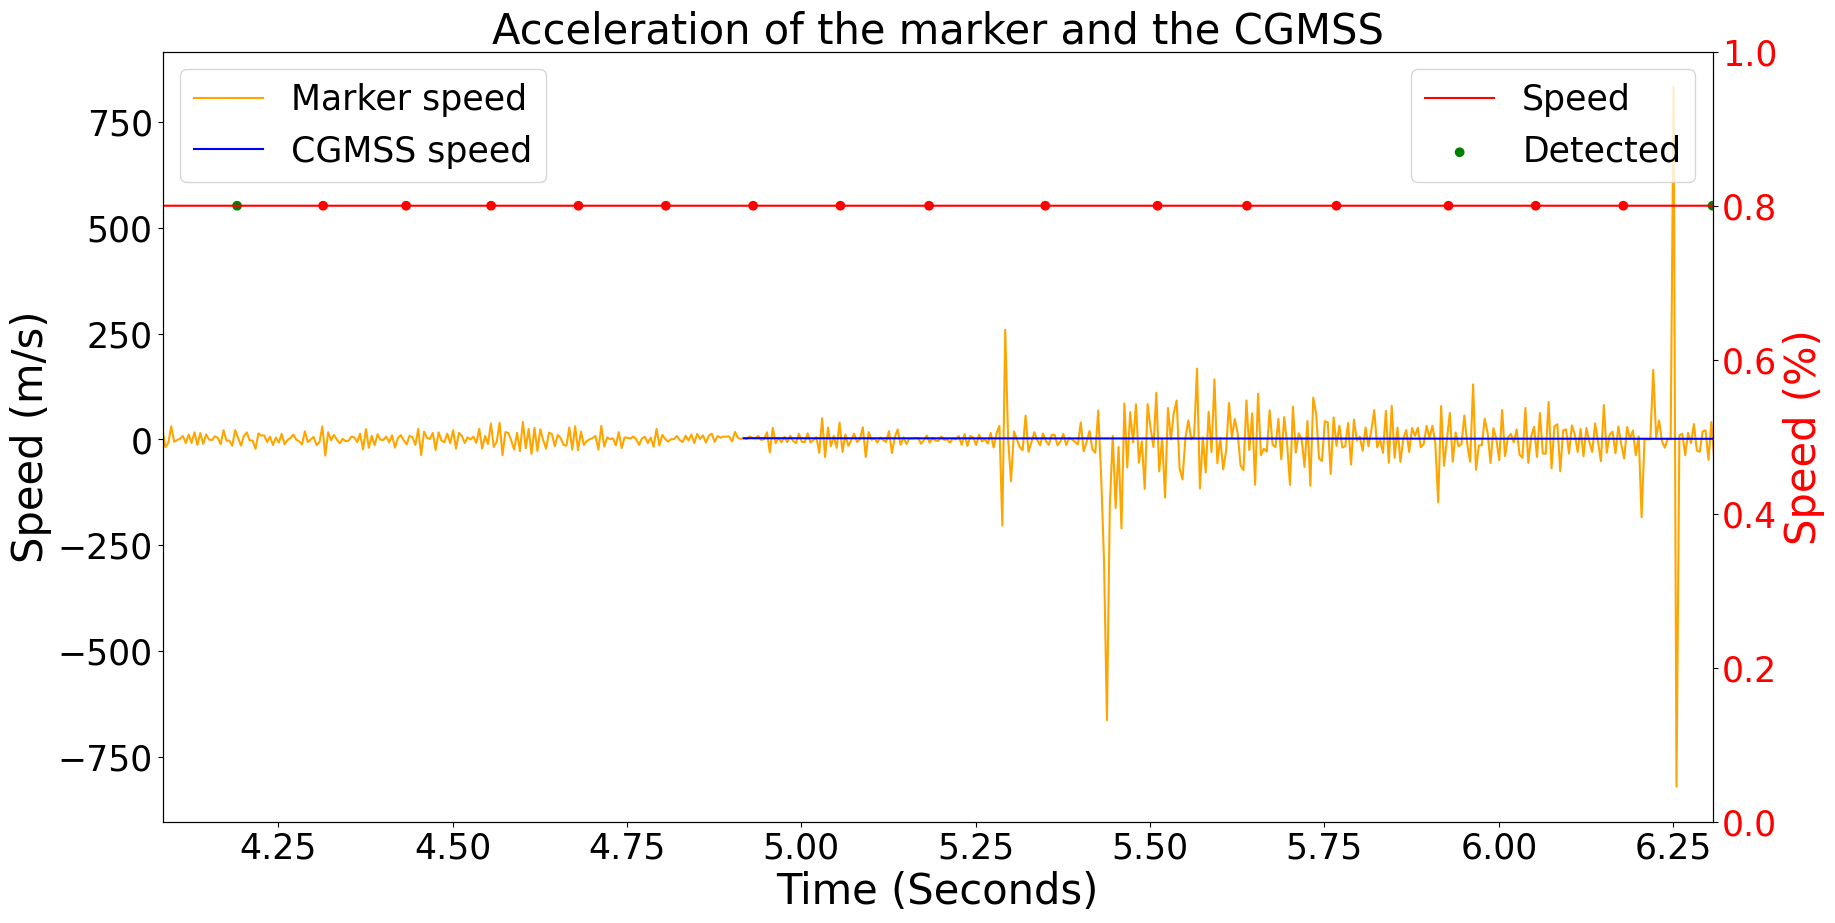

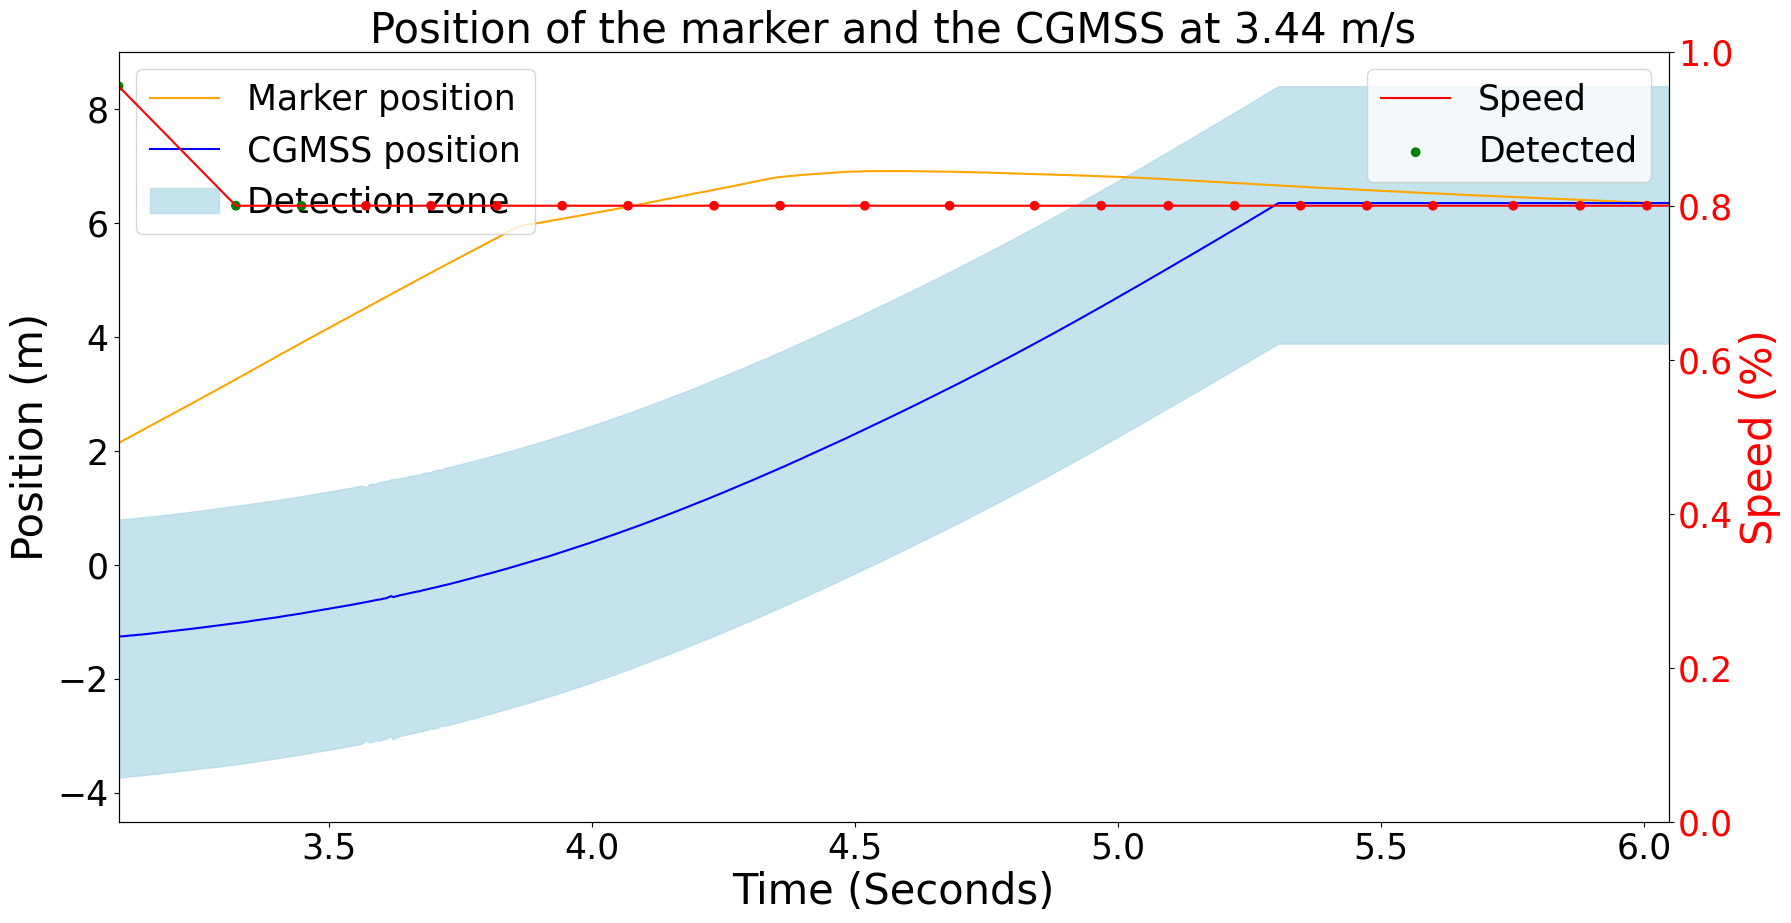

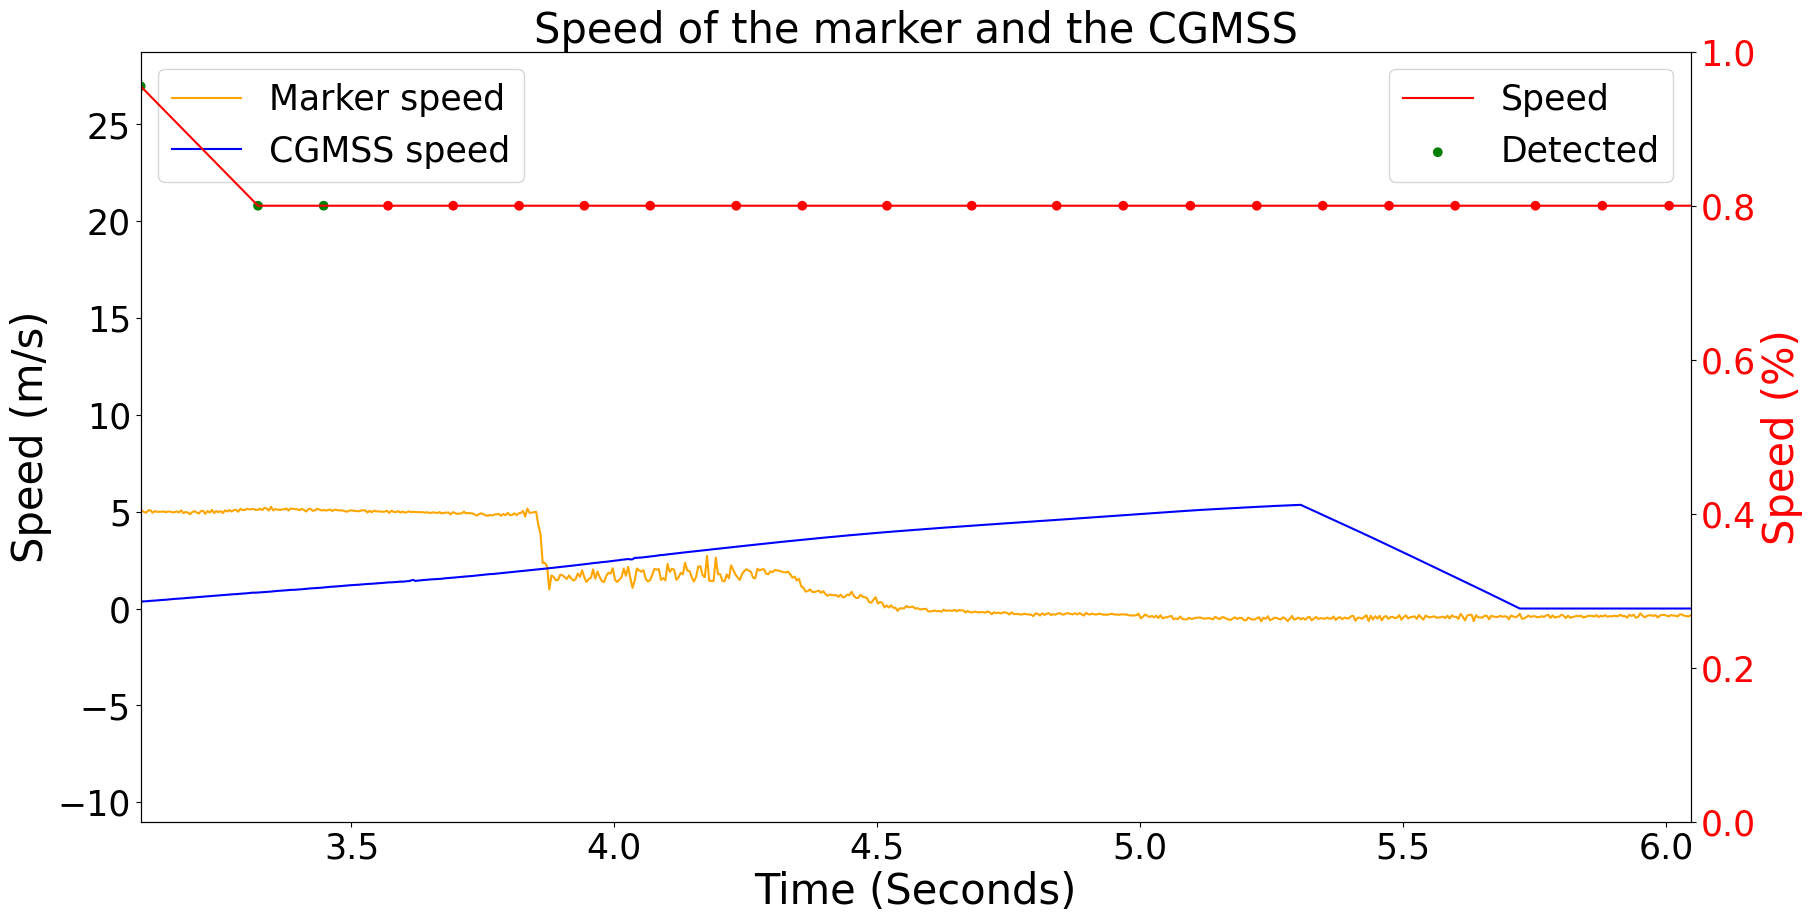

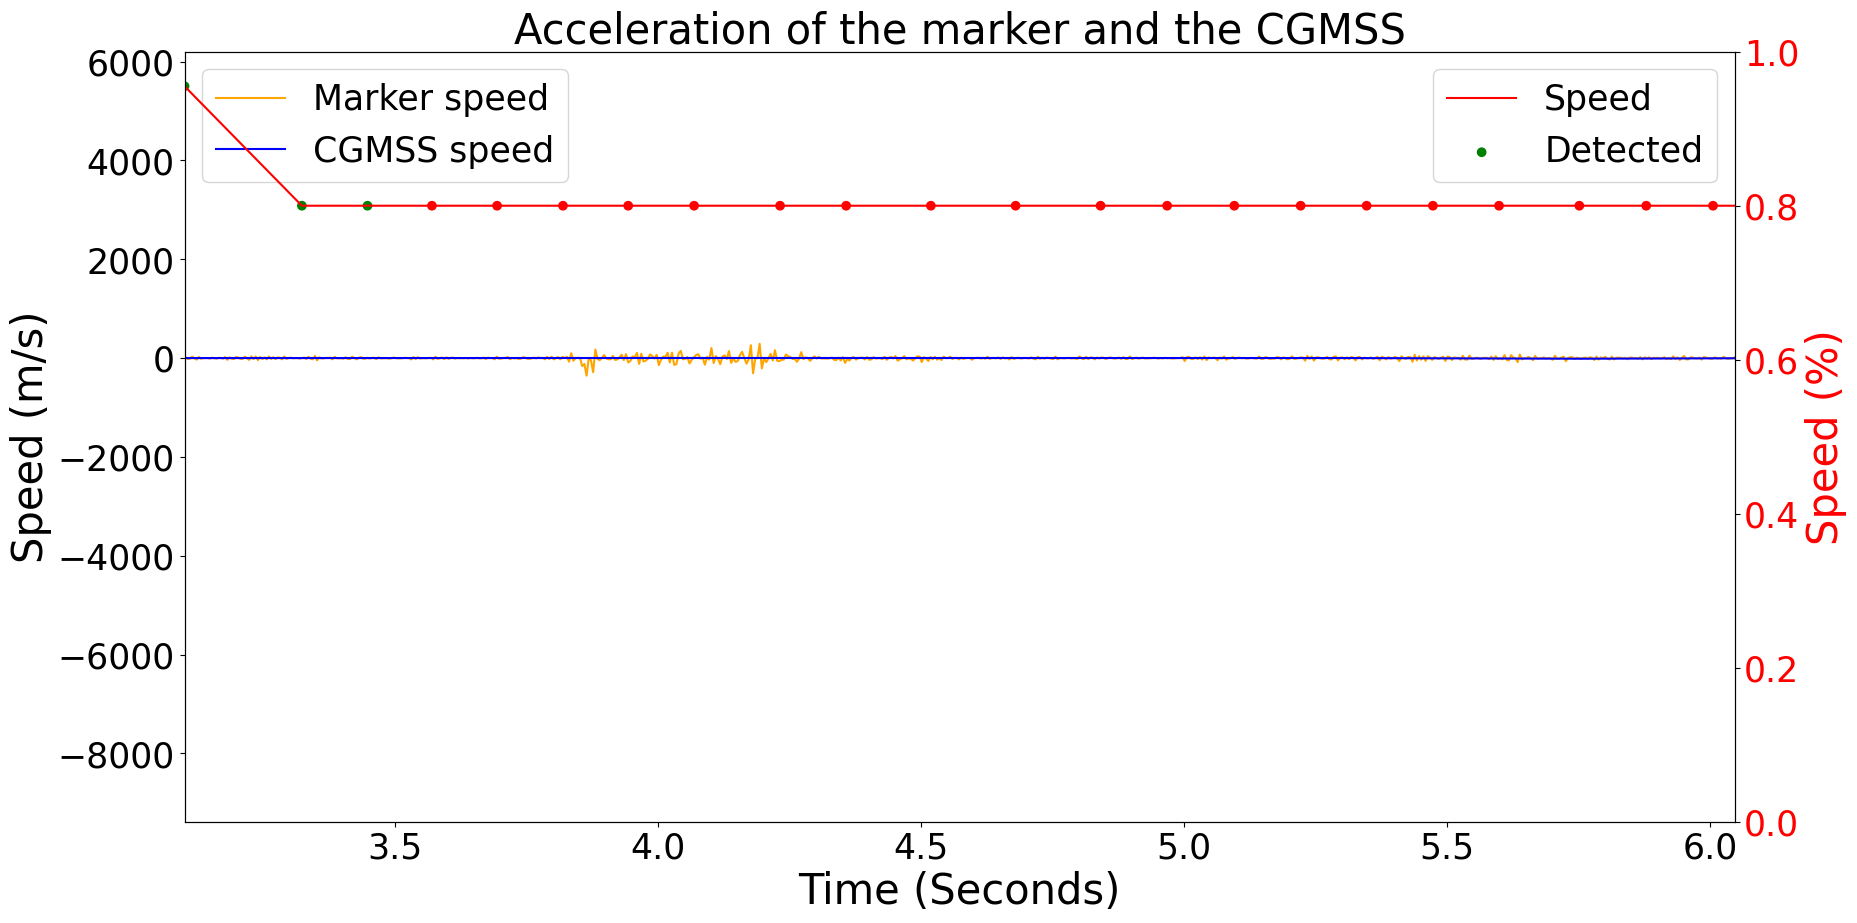

In [329]:
for mocap_file in mocap_files:
    ts = mocap_file[1]
    possibility = []
    for input_file in input_files:
        ts_input = input_file[1]
        if ts_input - ts < 0:
            continue
        possibility.append((ts_input - ts, input_file[0]))
    if len(possibility) == 0:
        continue
    possibility.sort(key=lambda x: x[0])
    input_file = possibility[0][1]
    mocap_file = mocap_file[0]

    df_mocap, frame_rate, start_time = process_csv_mocap(mocap_folder_path + mocap_file)
    df_input = process_csv_input(input_folder_path + input_file)
    input_time = df_input['timestamp'].iloc[0]
    timestamp = start_timestamp(start_time)
    df_mocap['Time (Seconds)'] = df_mocap['Time (Seconds)'] + timestamp - input_time
    df_input['timestamp'] = df_input['timestamp'] - input_time
    df_mocap = df_mocap[df_mocap['Time (Seconds)'] >= 0]
    df_mocap = df_mocap.reset_index(drop=True)
    df_mocap = interpolate_data(df_mocap)
    df_mocap = process_speed_accelration(df_mocap)
    try:
        plot_position(df_mocap, mocap_file.split('.')[0],df_input)
        plot_speed(df_mocap, mocap_file.split('.')[0],df_input)
        plot_acceleration(df_mocap, mocap_file.split('.')[0],df_input)
    except:
        print('Error in ploting position for file:', mocap_file)
    
        